In [1]:
import pyodbc
import pandas as pd
from sqlalchemy import create_engine
import urllib


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
server = 'LAPTOP-6PATUP9M\SQLEXPRESS'        # ← Change this line
database = 'CzechBankDB'

params = urllib.parse.quote_plus(
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={server};"
    f"DATABASE={database};"
    f"Trusted_Connection=yes;"
)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

In [3]:
account = pd.read_sql("SELECT * FROM account", engine)
card = pd.read_sql("SELECT * FROM card", engine)
client = pd.read_sql("SELECT * FROM client", engine)
disp = pd.read_sql("SELECT * FROM disp", engine)
district = pd.read_sql("SELECT * FROM district", engine)
transaction= pd.read_sql("SELECT * FROM Fact_Transaction", engine)
loan = pd.read_sql("SELECT * FROM loan", engine)
order = pd.read_sql("SELECT * FROM [order]", engine)

In [4]:
trans_behaviour = pd.read_sql("SELECT * FROM transaction_behaviour", engine)
analytical_loan = pd.read_sql("SELECT * FROM Analytical_Loan", engine)
analytical_order = pd.read_sql("SELECT * FROM Analytical_Orders", engine)

## Checking Null values

In [5]:
(card.isnull().sum()/len(card))*100

card_id        0.0
disp_id        0.0
card_type      0.0
issued_date    0.0
dtype: float64

In [6]:
(client.isnull().sum()/len(client))*100

client_id       0.0
birth_number    0.0
district_id     0.0
gender          0.0
dob             0.0
dtype: float64

In [7]:
(disp.isnull().sum()/len(disp))*100

disp_id       0.0
client_id     0.0
account_id    0.0
type          0.0
dtype: float64

In [8]:
(district.isnull().sum()/len(district))*100

district_id                   0.000000
district_name                 0.000000
region                        0.000000
population                    0.000000
municipalities_below_500      0.000000
municipalities_500to1999      0.000000
municipalities_2000to9999     0.000000
municipalities_above_10000    0.000000
no_of_cities                  0.000000
urban_pop_ratio               0.000000
avg_salary                    0.000000
unemployment_rate_1995        1.298701
unemployment_rate_1996        0.000000
entrepreneurs_per_1000        0.000000
crimes_1995                   1.298701
crimes_1996                   0.000000
dtype: float64

> ### We'll remove null values in "district" as it is less than 5%.

In [9]:
district = district.dropna(subset=['unemployment_rate_1995', 'crimes_1995'])

print(f"Rows: {len(district)}")

Rows: 76


In [10]:
(transaction.isnull().sum()/len(transaction))*100

trans_id                   0.000000
account_id                 0.000000
date                       0.000000
type                       0.000000
operation                  0.000000
amount                     0.000000
balance                    0.067329
purpose                   50.742961
partner_bank              59.863815
partnerbank_account_id    73.916220
source_file                0.000000
has_partner_account        0.000000
dtype: float64

> ### We'll remove null values in transaction "balance" as it is less than 5%.

In [11]:
transaction = transaction.dropna(subset=['balance'])
print(f"After removing NULL balance: {len(transaction)}")

After removing NULL balance: 1047869


In [12]:
# Clean transaction_behaviour
trans_behaviour = trans_behaviour.dropna(subset=['balance'])

In [13]:
(loan.isnull().sum()/len(loan))*100

loan_id             0.0
account_id          0.0
loan_amount         0.0
loan_duration       0.0
monthly_payments    0.0
loan_status         0.0
loan_date           0.0
dtype: float64

In [14]:
(order.isnull().sum()/len(order))*100

order_id      0.0
account_id    0.0
Bank_to       0.0
account_to    0.0
amount        0.0
dtype: float64

----------

In [15]:
# Create Age column (using dob)
client['age'] = 1998 - pd.to_datetime(client['dob']).dt.year

In [16]:
# Check basic statistics of age
print("=== Age Statistics ===")
print(client['age'].describe())

# Check for unrealistic ages
print("\n=== Age Logic Checks ===")
print(f"Customers with age < 18     : {(client['age'] < 18).sum()}")
print(f"Customers with age > 100    : {(client['age'] > 100).sum()}")
print(f"Customers with negative age : {(client['age'] < 0).sum()}")
print(f"Missing age values          : {client['age'].isnull().sum()}")

=== Age Statistics ===
count    5317.000000
mean       45.083694
std        17.127909
min        16.000000
25%        30.000000
50%        44.000000
75%        58.000000
max        87.000000
Name: age, dtype: float64

=== Age Logic Checks ===
Customers with age < 18     : 20
Customers with age > 100    : 0
Customers with negative age : 0
Missing age values          : 0


In [17]:
# Create Age Groups
client['age_group'] = pd.cut(
    client['age'], 
    bins=[0, 18, 25, 35, 45, 55, 100], 
    labels=['Below 18', '18-25', '25-35', '35-45', '45-55', 'Above 55']
)

print("=== Age Group Distribution ===")
print(client['age_group'].value_counts().sort_index())

=== Age Group Distribution ===
age_group
Below 18     114
18-25        721
25-35        977
35-45        957
45-55        978
Above 55    1570
Name: count, dtype: int64


In [18]:
print("=== Business Rule Validation ===")

# Rule 1: Customers below 18 should not have loans or credit cards
underage_clients = client[client['age'] < 18]['client_id']
print(f"Customers below 18 years old: {len(underage_clients)}")

# Check if any underage customer has a loan
underage_with_loan = analytical_loan[analytical_loan['client_id'].isin(underage_clients)]
print(f"Underage customers with loans: {underage_with_loan['client_id'].nunique()}")

# Check if any underage customer has a card
underage_with_card = disp[(disp['client_id'].isin(underage_clients)) & 
                          (disp['disp_id'].isin(card['disp_id']))]
print(f"Underage customers with cards : {underage_with_card['client_id'].nunique()}")

=== Business Rule Validation ===
Customers below 18 years old: 20
Underage customers with loans: 0
Underage customers with cards : 20


In [19]:
print("=== Age Data Quality Summary ===")
print(f"Total Customers           : {len(client)}")
print(f"Min Age                   : {client['age'].min()}")
print(f"Max Age                   : {client['age'].max()}")
print(f"Average Age               : {client['age'].mean():.2f}")
print(f"Customers with Age < 18   : {(client['age'] < 18).sum()}")
print(f"Customers with Age > 80   : {(client['age'] > 80).sum()}")

=== Age Data Quality Summary ===
Total Customers           : 5317
Min Age                   : 16
Max Age                   : 87
Average Age               : 45.08
Customers with Age < 18   : 20
Customers with Age > 80   : 22


In [20]:
# Get underage customers with cards
underage_clients = client[client['age'] < 18]['client_id'].unique()

underage_with_cards = disp[
    (disp['client_id'].isin(underage_clients)) & 
    (disp['disp_id'].isin(card['disp_id']))
]
print("Underage customers with cards:")
print(underage_with_cards[['client_id', 'disp_id']].head(50))

Underage customers with cards:
      client_id  disp_id
143         153      153
252         268      268
408         429      429
634         666      666
635         667      667
1420       1500     1500
1836       1947     1947
1886       1999     1999
2346       2475     2475
2411       2540     2540
2901       3066     3066
2939       3104     3104
3059       3230     3230
3435       3627     3627
3873       4091     4091
4318       4568     4568
4548       4808     4808
4563       4823     4823
4596       4944     4944
4606       4976     4976


In [21]:
underage_card_details = underage_with_cards.merge(card, on='disp_id', how='left')
print(underage_card_details['card_type'].value_counts())

card_type
junior    20
Name: count, dtype: int64


In [22]:
underage_clients = client[client['age'] < 18]['client_id'].unique()

underage_with_card = disp[
    (disp['client_id'].isin(underage_clients)) & 
    (disp['disp_id'].isin(card['disp_id']))
]['client_id'].unique()

print("Underage customers with cards:", len(underage_with_card))
print("Underage customers without cards:", len(underage_clients) - len(underage_with_card))

Underage customers with cards: 20
Underage customers without cards: 0


In [23]:
# Get all underage client IDs
underage_client_ids = client[client['age'] < 18]['client_id'].tolist()

# Get underage clients who have cards
underage_with_card_ids = disp[
    (disp['client_id'].isin(underage_client_ids)) & 
    (disp['disp_id'].isin(card['disp_id']))
]['client_id'].unique().tolist()

# Final list of clients to keep (remove underage without cards)
clients_to_remove = [cid for cid in underage_client_ids if cid not in underage_with_card_ids]

client_clean = client[~client['client_id'].isin(clients_to_remove)]

print("Original clients:", len(client))
print("Clients after cleaning:", len(client_clean))
print("Clients removed:", len(clients_to_remove))

Original clients: 5317
Clients after cleaning: 5317
Clients removed: 0


In [24]:
client=client_clean.copy()

In [25]:
from sqlalchemy import text

query = """
DELETE FROM client
WHERE client_id IN (
    SELECT client_id 
    FROM client 
    WHERE 
        -- Extract birth year from birth_number and check if age < 18 as of 1998
        (CAST(LEFT(CAST(birth_number AS VARCHAR(8)), 2) AS INT) + 1900) > 1980  
        AND client_id NOT IN (
            SELECT client_id 
            FROM disp 
            WHERE disp_id IN (SELECT disp_id FROM card)
        )
)
"""

with engine.begin() as connection:
    result = connection.execute(text(query))
    print(f"Rows deleted: {result.rowcount}")

Rows deleted: 0


In [26]:
### Removed clients who are under age without cards

In [27]:
print("Transaction date range:")
print("Min:", transaction['date'].min())
print("Max:", transaction['date'].max())

Transaction date range:
Min: 1993-01-01
Max: 1998-12-19


In [28]:
print("Transaction date range:")
print("Min:", trans_behaviour['date'].min())
print("Max:", trans_behaviour['date'].max())

Transaction date range:
Min: 1993-01-01
Max: 1998-12-19


In [29]:
print("Data Shape After Cleaning ")
print(f"transaction_behaviour: {trans_behaviour.shape}")
print(f"district: {district.shape}")
print(f"analytical_loan: {analytical_loan.shape}")
print(f"analytical_order: {analytical_order.shape}")

Data Shape After Cleaning 
transaction_behaviour: (1047869, 21)
district: (76, 16)
analytical_loan: (682, 18)
analytical_order: (6471, 14)


## Loan Risk Analysis

In [30]:
# Loan Status Distribution
print("Loan Status Distribution")
print(analytical_loan['loan_status'].value_counts())

# Percentage
print("\nLoan Status Percentage")
print((analytical_loan['loan_status'].value_counts(normalize=True) * 100).round(2))

Loan Status Distribution
loan_status
C    403
A    203
D     45
B     31
Name: count, dtype: int64

Loan Status Percentage
loan_status
C    59.09
A    29.77
D     6.60
B     4.55
Name: proportion, dtype: float64


**Loan Status**
* A=Loan Completed Successfully
* B=Loan Completed with Issues
* C=Active Loan
* D=Active Loan with Outstanding Debt

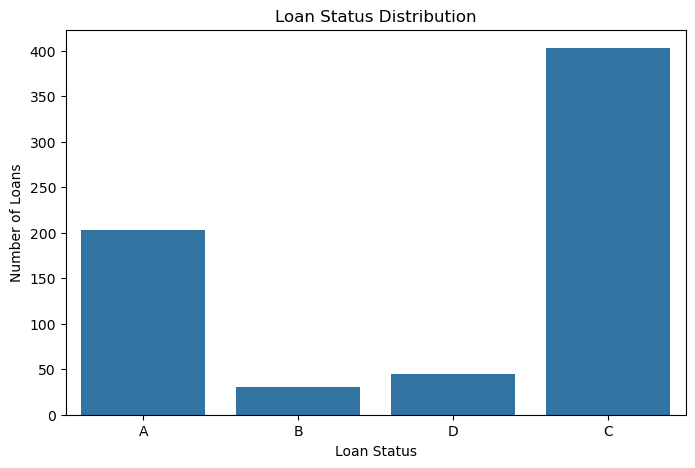

In [31]:
plt.figure(figsize=(8,5))
sns.countplot(data=analytical_loan, x='loan_status')
plt.title('Loan Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Number of Loans')
plt.show()

In [32]:
# Create a flag for Problematic Loans (Status B & D)
analytical_loan['is_problematic'] = analytical_loan['loan_status'].isin(['B', 'D']).astype(int)

print(analytical_loan['is_problematic'].value_counts(normalize=True) * 100)

is_problematic
0    88.856305
1    11.143695
Name: proportion, dtype: float64


In [33]:
print("=== Loan Amount Comparison ===")
print(analytical_loan.groupby('is_problematic')['loan_amount'].describe())

print("\n=== Monthly Payment Comparison ===")
print(analytical_loan.groupby('is_problematic')['monthly_payments'].describe())

print("\n=== Loan Duration Comparison ===")
print(analytical_loan.groupby('is_problematic')['loan_duration'].describe())

=== Loan Amount Comparison ===
                count           mean            std      min      25%  \
is_problematic                                                          
0               606.0  144689.089109  109230.409747   4980.0  63738.0   
1                76.0  205002.000000  131098.942473  29448.0  86562.0   

                     50%       75%       max  
is_problematic                                
0               110436.0  198132.0  590820.0  
1               188460.0  291495.0  541200.0  

=== Monthly Payment Comparison ===
                count         mean         std     min     25%     50%  \
is_problematic                                                           
0               606.0  4047.607261  2173.66027   304.0  2307.0  3799.0   
1                76.0  5331.355263  2232.63664  1671.0  3158.5  5217.0   

                    75%     max  
is_problematic                   
0               5622.00  9910.0  
1               7470.75  9698.0  

=== Loan Duration 

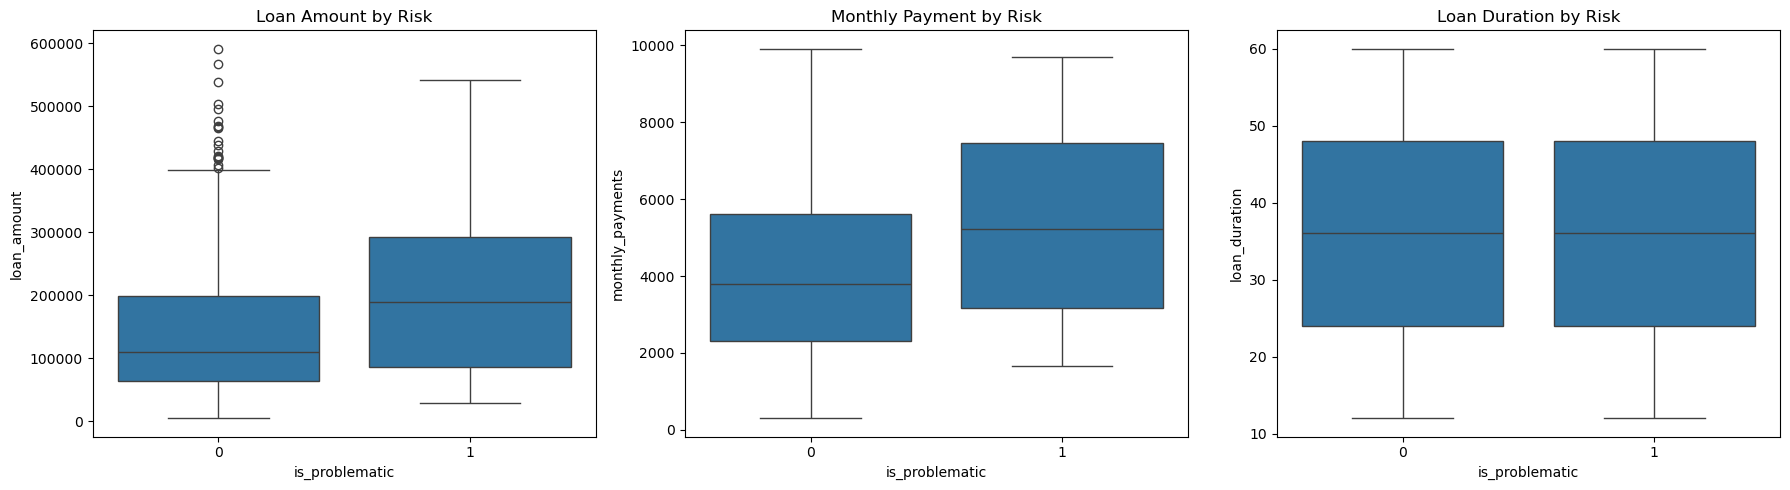

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=analytical_loan, x='is_problematic', y='loan_amount', ax=axes[0])
axes[0].set_title('Loan Amount by Risk')

sns.boxplot(data=analytical_loan, x='is_problematic', y='monthly_payments', ax=axes[1])
axes[1].set_title('Monthly Payment by Risk')

sns.boxplot(data=analytical_loan, x='is_problematic', y='loan_duration', ax=axes[2])
axes[2].set_title('Loan Duration by Risk')

plt.tight_layout()
plt.show()

In [35]:
problematic_region = analytical_loan[analytical_loan['is_problematic'] == 1] \
    .groupby('region').size().reset_index(name='Problematic_Loans')

problematic_region = problematic_region.sort_values('Problematic_Loans', ascending=False)

print(problematic_region)

            region  Problematic_Loans
4    north Moravia                 18
6    south Moravia                 13
1  central Bohemia                 10
2     east Bohemia                  9
5    south Bohemia                  9
7     west Bohemia                  9
0           Prague                  7
3    north Bohemia                  1


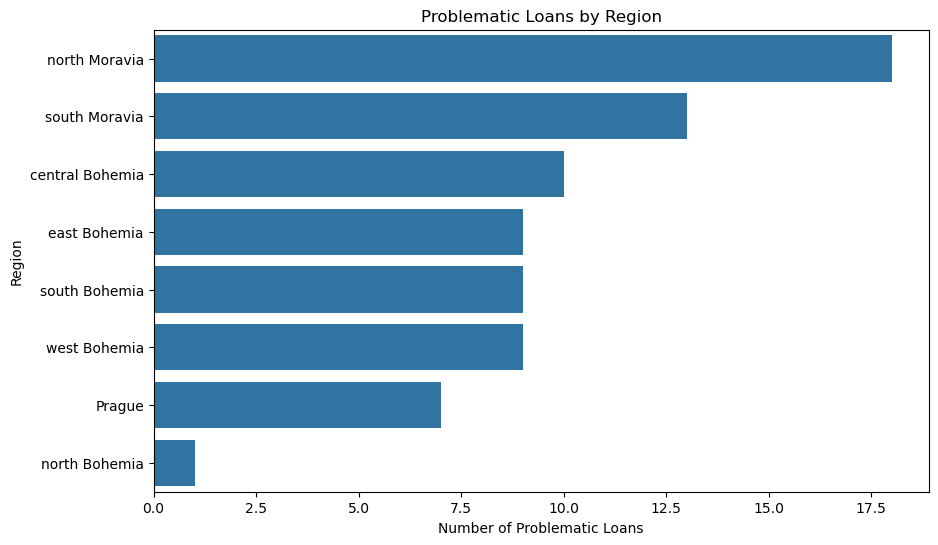

In [36]:
plt.figure(figsize=(10,6))
sns.barplot(data=problematic_region, x='Problematic_Loans', y='region')
plt.title('Problematic Loans by Region')
plt.xlabel('Number of Problematic Loans')
plt.ylabel('Region')
plt.show()

In [37]:
# Create Duration Category
analytical_loan['Duration_Category'] = analytical_loan['loan_duration'].apply(
    lambda x: 'Long Duration' if x > 36 else 'Short Duration'
)

# Cross tabulation
duration_risk = pd.crosstab(analytical_loan['Duration_Category'], 
                            analytical_loan['is_problematic'], 
                            normalize='index') * 100

duration_risk

is_problematic,0,1
Duration_Category,,
Long Duration,88.339223,11.660777
Short Duration,89.223058,10.776942


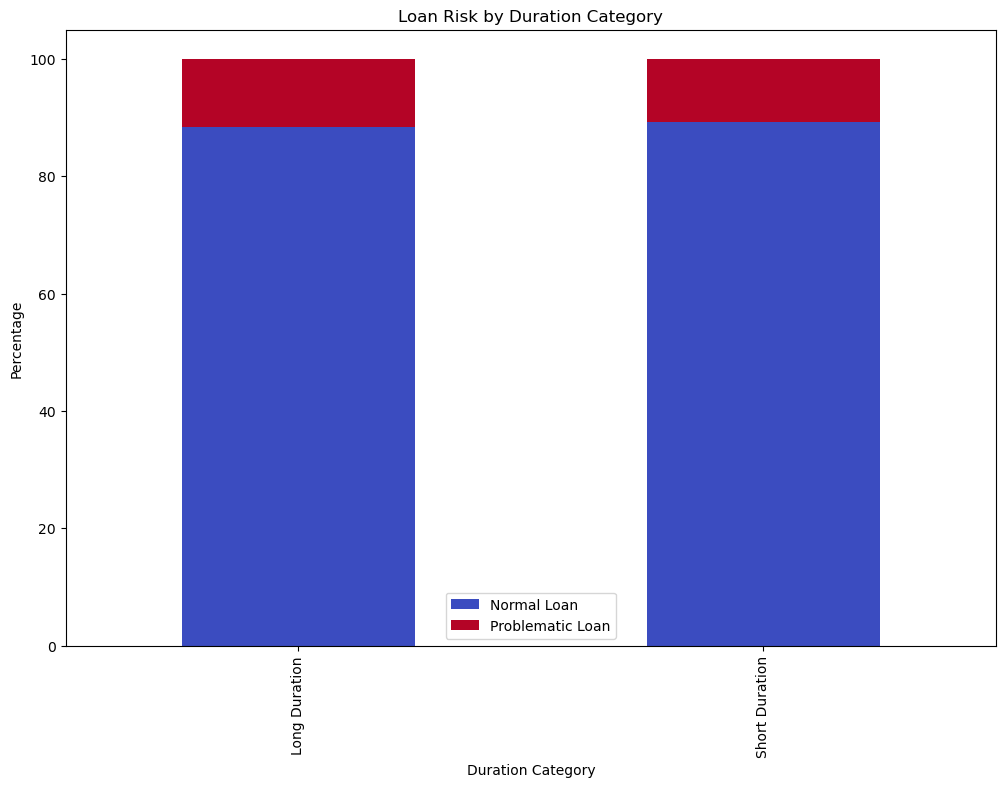

In [38]:
duration_risk.plot(kind='bar', stacked=True, figsize=(12,8), colormap='coolwarm')
plt.title('Loan Risk by Duration Category')
plt.ylabel('Percentage')
plt.xlabel('Duration Category')
plt.legend(['Normal Loan', 'Problematic Loan'])
plt.show()

### Key Findings - Loan Risk Analysis

**1. Overall Risk Level**
- Approximately 11.1% of loans in the portfolio are problematic (Status B & D).

**2. Characteristics of Problematic Loans**
- Problematic loans have **higher average loan amounts** (₹2,05,802 vs ₹1,44,689).
- They also carry **higher monthly payments**.
- Longer loan duration (>36 months) increases the likelihood of loans becoming problematic.

**3. Regional Insights**
- Certain regions (e.g., North Moravia, South Moravia) show higher concentrations of problematic loans.
- This indicates possible regional economic or demographic factors affecting repayment behavior.

**4. Business Implication**
- The bank should consider tightening credit assessment for high-value and long-duration loans.
- Regional risk profiling can help in better credit decision-making and monitoring.

-----------

### Recommendations - Loan Risk Analysis

Based on the analysis of loan data, the following recommendations are proposed to reduce loan default risk:

**1. Strengthen Credit Assessment for High-Value Loans**
- Problematic loans have significantly higher average loan amounts.
- The bank should apply stricter income verification and credit scoring for loans above ₹2,00,000.

**2. Review Long-Duration Loans**
- Loans with duration greater than 36 months show a higher risk of becoming problematic.
- Consider reducing the maximum loan tenure or adding stricter eligibility criteria for long-duration loans.

**3. Regional Risk Monitoring**
- Certain regions (such as North Moravia and South Moravia) have a higher concentration of problematic loans.
- The bank should conduct deeper regional analysis and possibly adjust credit policies or increase monitoring in high-risk regions.

**4. Early Warning System**
- Develop a monitoring system to flag active loans (Status C) that show characteristics similar to problematic loans (high amount + long duration).
- This can help in early intervention and reduce future defaults.

**5. Customer Education & Support**
- Customers with high monthly payments relative to their income should be offered financial counseling or flexible repayment options to reduce default risk.

--------------

## 1.Customer Analytics

### 1.Customer Demographics Overview

### Age Distribution (Overall)

In [39]:
# Age Distribution
print("=== Overall Age Distribution ===")
print(client['age'].describe())

# Age Groups
client['age_group'] = pd.cut(
    client['age'], 
    bins=[0, 18, 25, 35, 45, 55, 100], 
    labels=['Below 18', '18-25', '25-35', '35-45', '45-55', 'Above 55']
)

print("\n=== Age Group Distribution ===")
print(client['age_group'].value_counts().sort_index())

=== Overall Age Distribution ===
count    5317.000000
mean       45.083694
std        17.127909
min        16.000000
25%        30.000000
50%        44.000000
75%        58.000000
max        87.000000
Name: age, dtype: float64

=== Age Group Distribution ===
age_group
Below 18     114
18-25        721
25-35        977
35-45        957
45-55        978
Above 55    1570
Name: count, dtype: int64


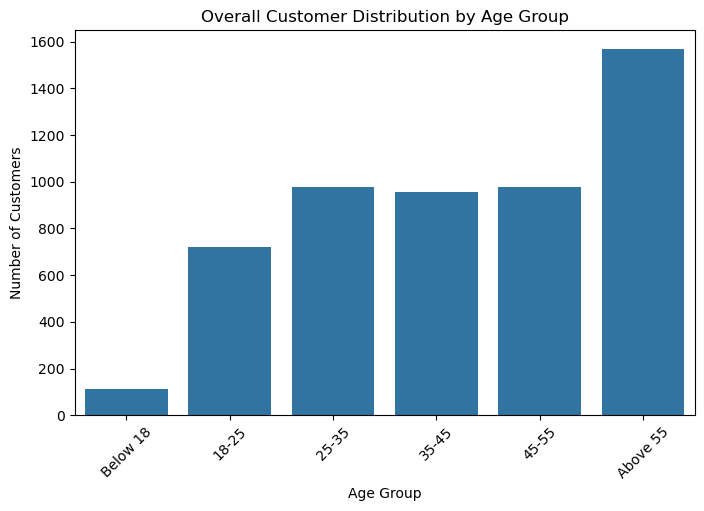

In [40]:
plt.figure(figsize=(8,5))
sns.countplot(data=client, x='age_group', order=['Below 18', '18-25', '25-35', '35-45', '45-55', 'Above 55'])
plt.title('Overall Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.show()

### Gender Distribution (Overall)

In [41]:
print(client['gender'].value_counts(normalize=True) * 100)

gender
Male      50.592439
Female    49.407561
Name: proportion, dtype: float64


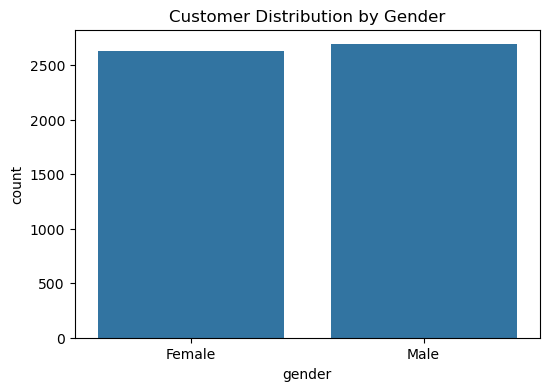

In [42]:
plt.figure(figsize=(6,4))
sns.countplot(data=client, x='gender')
plt.title('Customer Distribution by Gender')
plt.show()

### Customer Distribution by Region & District

In [43]:
# Merge client with district
client_district = client.merge(district, on='district_id', how='left')

# Customers by Region
region_dist = client_district['region'].value_counts().reset_index()
region_dist.columns = ['region', 'Total_Customers']

print(region_dist.sort_values('Total_Customers', ascending=False))

            region  Total_Customers
0    south Moravia              926
1    north Moravia              853
2  central Bohemia              658
3           Prague              656
4     east Bohemia              655
5    north Bohemia              553
6     west Bohemia              511
7    south Bohemia              446


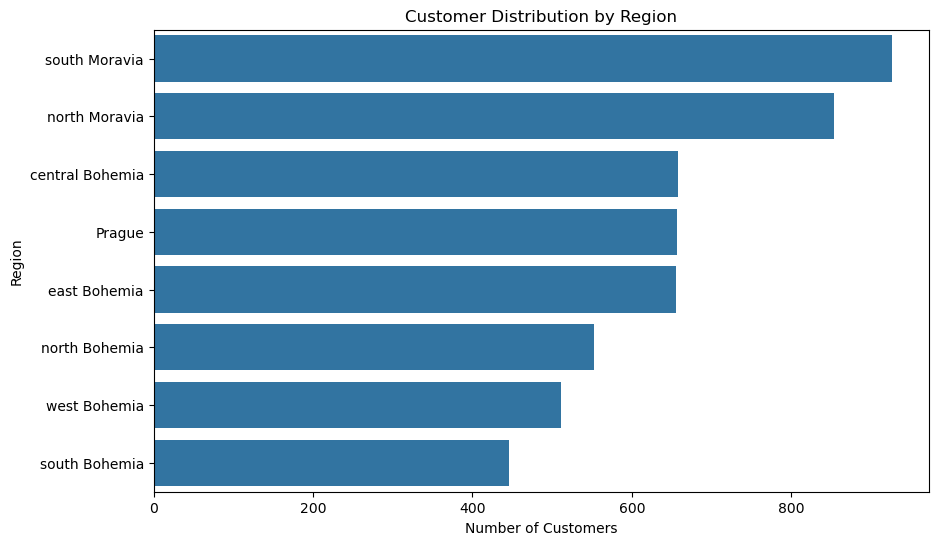

In [44]:
plt.figure(figsize=(10,6))
sns.barplot(data=region_dist, x='Total_Customers', y='region')
plt.title('Customer Distribution by Region')
plt.xlabel('Number of Customers')
plt.ylabel('Region')
plt.show()

In [45]:
# Merge client with account (using disp as bridge)
client_account = client.merge(disp[['client_id', 'account_id']], on='client_id', how='left')
client_account = client_account.merge(account[['account_id', 'Account_type']], on='account_id', how='left')

print("=== Account Type by Gender ===")
account_gender = pd.crosstab(client_account['gender'], client_account['Account_type'], normalize='index') * 100
print(account_gender.round(2))

=== Account Type by Gender ===
Account_type  NRI account  Salary account  Savings account
gender                                                    
Female              34.11           32.20            33.69
Male                34.16           31.78            34.05


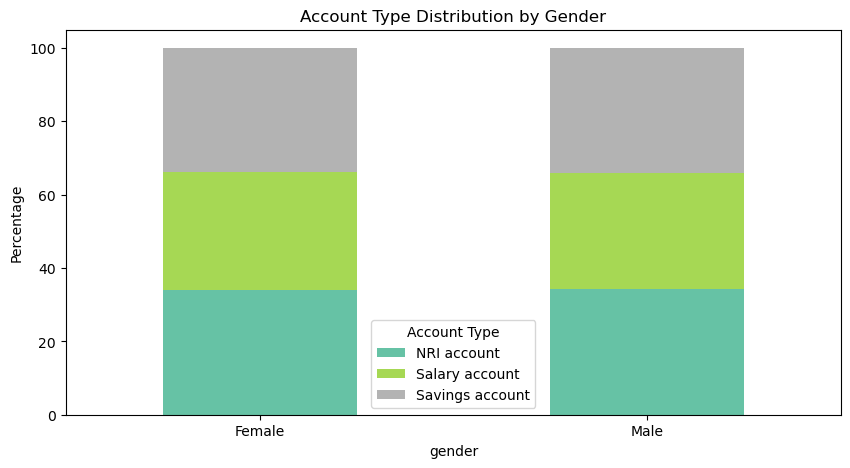

In [46]:
account_gender.plot(kind='bar', stacked=True, figsize=(10,5), colormap='Set2')
plt.title('Account Type Distribution by Gender')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Account Type')
plt.show()

### Geographic Analysis at District Level

In [47]:
# Merge client with district
client_district = client.merge(
    district[['district_id', 'district_name', 'region', 'population', 'avg_salary']], 
    on='district_id', 
    how='left'
)

# Customer count by district
district_customers = client_district.groupby(['district_id', 'district_name', 'region']).size().reset_index(name='Total_Customers')

# Sort by number of customers
district_customers = district_customers.sort_values('Total_Customers', ascending=False)

print("=== Top 10 Districts by Number of Customers ===")
print(district_customers.head(10))

print("\n=== Bottom 10 Districts by Number of Customers ===")
print(district_customers.tail(10))

=== Top 10 Districts by Number of Customers ===
    district_id    district_name           region  Total_Customers
0             1      Hl.m. Praha           Prague              656
72           74  Ostrava - mesto    north Moravia              177
68           70          Karvina    north Moravia              168
53           54     Brno - mesto    south Moravia              152
63           64             Zlin    south Moravia              108
70           72          Olomouc    north Moravia              104
67           68  Frydek - Mistek    north Moravia               86
45           46           Nachod     east Bohemia               75
51           52  Usti nad Orlici     east Bohemia               73
4             5            Kolin  central Bohemia               70

=== Bottom 10 Districts by Number of Customers ===
    district_id     district_name           region  Total_Customers
1             2           Benesov  central Bohemia               45
33           34          Ch

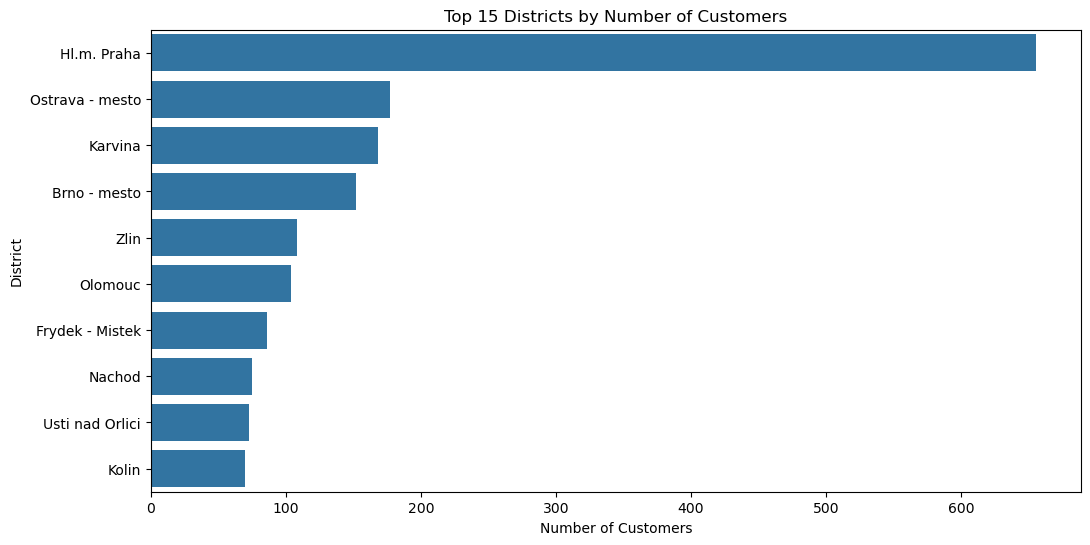

In [48]:
plt.figure(figsize=(12,6))
sns.barplot(data=district_customers.head(10), x='Total_Customers', y='district_name')
plt.title('Top 15 Districts by Number of Customers')
plt.xlabel('Number of Customers')
plt.ylabel('District')
plt.show()

### Average Balance by District

In [50]:
# Merge with transaction_behaviour to get average balance per account
account_balance = trans_behaviour.groupby('account_id')['balance'].mean().reset_index()
account_balance.columns = ['account_id', 'Avg_Balance']

# Merge with disp to get client_id
account_balance = account_balance.merge(disp[['account_id', 'client_id']], on='account_id', how='left')

# Merge with client_district
district_balance = client_district.merge(account_balance, on='client_id', how='left')

# Average balance by district
district_avg_balance = district_balance.groupby('district_name')['Avg_Balance'].mean().reset_index()
district_avg_balance = district_avg_balance.sort_values('Avg_Balance', ascending=False)

print("=== Top 10 Districts by Average Customer Balance ===")
print(district_avg_balance.head(10))

=== Top 10 Districts by Average Customer Balance ===
      district_name   Avg_Balance
39          Nymburk  42219.617023
70  Usti nad Orlici  41574.512769
2           Blansko  40988.233665
46      Plzen - jih  39699.725198
48    Plzen - sever  39252.114572
0           Benesov  39209.975148
33            Louny  39112.392164
28            Kolin  38790.750327
69   Usti nad Labem  38734.671181
43        Pardubice  38729.085183


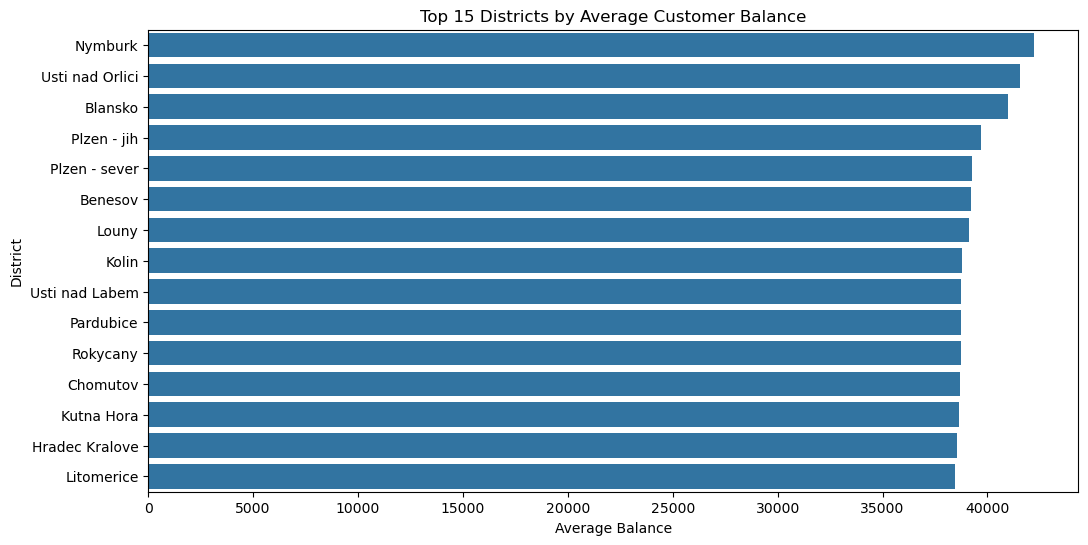

In [51]:
plt.figure(figsize=(12,6))
sns.barplot(data=district_avg_balance.head(15), x='Avg_Balance', y='district_name')
plt.title('Top 15 Districts by Average Customer Balance')
plt.xlabel('Average Balance')
plt.ylabel('District')
plt.show()

In [52]:
# Create a district performance summary
district_summary = client_district.groupby(['district_id', 'district_name', 'region']).agg(
    Total_Customers = ('client_id', 'count'),
    Avg_Salary = ('avg_salary', 'mean')
).reset_index()

# Merge with average balance
district_summary = district_summary.merge(district_avg_balance, on='district_name', how='left')

district_summary = district_summary.sort_values('Total_Customers', ascending=False)

print("=== District Performance Summary ===")
district_summary.head(15)

=== District Performance Summary ===


,district_id,district_name,region,Total_Customers,Avg_Salary,Avg_Balance
0,1,Hl.m. Praha,Prague,656,12541.0,36896.694257
72,74,Ostrava - mesto,north Moravia,177,10673.0,37959.260928
68,70,Karvina,north Moravia,168,10177.0,36777.640004
53,54,Brno - mesto,south Moravia,152,9897.0,35044.342316
63,64,Zlin,south Moravia,108,9624.0,36275.421321
70,72,Olomouc,north Moravia,104,8994.0,33870.064553
67,68,Frydek - Mistek,north Moravia,86,9893.0,36880.862411
45,46,Nachod,east Bohemia,75,8369.0,35687.999651
51,52,Usti nad Orlici,east Bohemia,73,8363.0,41574.512769
4,5,Kolin,central Bohemia,70,9307.0,38790.750327


#### Key Findings

1. **Customer Concentration**
   - Customer distribution is highly uneven across districts.
   - **Hl.m. Praha (Prague)** has the highest number of customers (656), followed by Ostrava-mesto (177) and Karvina (168).
   - Many districts have very low customer counts (bottom 10 districts have only 42–45 customers each).
   - Most high-customer districts are concentrated in North Moravia and South Moravia regions.

2. **Financial Strength by District**
   - Districts with the highest average customer balance are not necessarily the ones with the highest number of customers.
   - Top districts by average balance include Nymburk, Usti nad Orlici, Blansko, and Plzen-jih.
   - Some districts with relatively fewer customers show higher average balances, indicating financially stronger customer segments.

3. **Volume vs Quality Trade-off**
   - Prague has very high customer volume but relatively moderate average balance.
   - Several smaller districts show higher average balances, suggesting better per-customer value despite lower overall numbers.

4. **Regional Patterns**
   - North Moravia and South Moravia dominate in terms of customer volume.
   - Some districts in Central Bohemia and East Bohemia show strong average balances, indicating potential for growth.

#### Recommendations

1. **Focus Retention Efforts in High-Volume Districts**
   - Prioritize customer retention and relationship management in Prague, Ostrava-mesto, Karvina, and Brno-mesto to protect revenue.

2. **Target Growth in High-Quality Districts**
   - Focus acquisition and cross-selling campaigns in districts like Nymburk, Usti nad Orlici, Blansko, and Louny.

3. **Balanced Regional Strategy**
   - Maintain strong presence in high-volume districts while actively growing in districts with higher average balances.

4. **District-Level Marketing and Product Strategy**
   - Customize offerings based on district characteristics:
     - **High-balance districts** → Investment products, premium cards, wealth management.
     - **High-volume but lower-balance districts** → Basic banking products, loans, and transaction-based offers.

### 2. High-Value Customer Identification

In [53]:
transaction.head()

,trans_id,account_id,date,type,operation,amount,balance,purpose,partner_bank,partnerbank_account_id,source_file,has_partner_account
0,732436,2503,1993-12-31,Withdrawal,Withdrawal in cash,15.0,27875.5,Payment on Statement,None,None,trnx_16,NO
1,730715,2497,1993-12-31,Withdrawal,Withdrawal in cash,15.0,18709.9,Payment on Statement,None,None,trnx_16,NO
2,733937,2508,1993-12-31,Withdrawal,Withdrawal in cash,15.0,21579.1,Payment on Statement,None,None,trnx_16,NO
3,802764,2736,1993-12-31,Withdrawal,Withdrawal in cash,15.0,32351.4,Payment on Statement,None,None,trnx_16,NO
4,801171,2732,1993-12-31,Withdrawal,Withdrawal in cash,15.0,65012.5,Payment on Statement,None,None,trnx_16,NO


In [54]:
account.head()

,account_id,district_id,frequency,Account_type,date_joined,Account_Owner_Type
0,1573,63,POPLATEK MESICNE,Savings account,1997-12-29,Single Owner
1,3276,1,POPLATEK MESICNE,Salary account,1997-12-29,Joint Account
2,124,55,POPLATEK MESICNE,Salary account,1997-12-28,Single Owner
3,3958,59,POPLATEK MESICNE,NRI account,1997-12-28,Joint Account
4,777,30,POPLATEK MESICNE,Savings account,1997-12-28,Single Owner


In [55]:
# Calculate transaction metrics per account
customer_txn = transaction.groupby('account_id').agg(
    Total_Transaction_Amount=('amount', 'sum'),
    Transaction_Count=('trans_id', 'count'),
    Avg_Balance=('balance', 'mean')
).reset_index()

# Merge with disp to get client_id
customer_txn = customer_txn.merge(
    disp[['account_id', 'client_id']], 
    on='account_id', 
    how='left'
)

# Remove duplicates (in case one account has multiple clients)
customer_txn = customer_txn.drop_duplicates(subset='client_id')

customer_txn.head()

,account_id,Total_Transaction_Amount,Transaction_Count,Avg_Balance,client_id
0,1,375139.0,238,16004.628151,1
1,2,3151357.0,477,36527.942558,2
2,2,3151357.0,477,36527.942558,3
3,3,292260.0,115,26555.806087,4
4,3,292260.0,115,26555.806087,5


In [56]:
customer_metrics = transaction.groupby('account_id').agg(
    Total_Transaction_Amount = ('amount', 'sum'),
    Transaction_Frequency    = ('trans_id', 'count'),
    Avg_Balance              = ('balance', 'mean')
).reset_index()

# 2. Merge with disp to get client_id
customer_metrics = customer_metrics.merge(
    disp[['account_id', 'client_id']], 
    on='account_id', 
    how='left'
)

# Remove duplicates (one account can have multiple clients)
customer_metrics = customer_metrics.drop_duplicates(subset='client_id')

In [57]:
customer_metrics

,account_id,Total_Transaction_Amount,Transaction_Frequency,Avg_Balance,client_id
0,1,375139.0,238,16004.628151,1
1,2,3151357.0,477,36527.942558,2
2,2,3151357.0,477,36527.942558,3
3,3,292260.0,115,26555.806087,4
4,3,292260.0,115,26555.806087,5
...,...,...,...,...,...
5364,11349,3953292.0,302,48868.020199,13955
5365,11349,3953292.0,302,48868.020199,13956
5366,11359,2943914.0,376,35898.573404,13968
5367,11362,1329863.0,343,30446.439942,13971


In [58]:
# Get total loan amount per client
loan_amount_per_client = analytical_loan.groupby('client_id')['loan_amount'].sum().reset_index()
loan_amount_per_client.columns = ['client_id', 'Total_Loan_Amount']

# Merge with customer metrics
customer_metrics = customer_metrics.merge(loan_amount_per_client, on='client_id', how='left')

# Fill missing loan amounts with 0
customer_metrics['Total_Loan_Amount'] = customer_metrics['Total_Loan_Amount'].fillna(0)

In [59]:
customer_metrics

,account_id,Total_Transaction_Amount,Transaction_Frequency,Avg_Balance,client_id,Total_Loan_Amount
0,1,375139.0,238,16004.628151,1,0.0
1,2,3151357.0,477,36527.942558,2,80952.0
2,2,3151357.0,477,36527.942558,3,0.0
3,3,292260.0,115,26555.806087,4,0.0
4,3,292260.0,115,26555.806087,5,0.0
...,...,...,...,...,...,...
5364,11349,3953292.0,302,48868.020199,13955,419880.0
5365,11349,3953292.0,302,48868.020199,13956,0.0
5366,11359,2943914.0,376,35898.573404,13968,54024.0
5367,11362,1329863.0,343,30446.439942,13971,129408.0


In [60]:
# ============================================
#High-Value Customer Definition 
# ============================================

# Create base customer metrics from transactions
customer_metrics = transaction.groupby('account_id').agg(
    Total_Transaction_Amount = ('amount', 'sum'),
    Transaction_Count        = ('trans_id', 'count'),
    Avg_Balance              = ('balance', 'mean')
).reset_index()

# Merge with disp to get client_id
customer_metrics = customer_metrics.merge(
    disp[['account_id', 'client_id']], 
    on='account_id', 
    how='left'
)

# Remove duplicates
customer_metrics = customer_metrics.drop_duplicates(subset='client_id')

# Merge Loan Information
loan_info = analytical_loan.groupby('client_id').agg(
    Total_Loan_Amount = ('loan_amount', 'sum'),
    is_problematic    = ('is_problematic', 'max')   # Take max (if any loan is problematic)
).reset_index()

customer_metrics = customer_metrics.merge(
    loan_info, 
    on='client_id', 
    how='left'
)

# Fill missing values
customer_metrics['Total_Loan_Amount'] = customer_metrics['Total_Loan_Amount'].fillna(0)
customer_metrics['is_problematic'] = customer_metrics['is_problematic'].fillna(0).astype(int)

# ============================================
# Create High-Value Score 
# ============================================

customer_metrics['High_Value_Score'] = 0

# Rule 1: High Transaction Amount (Top 25%)
high_txn_threshold = customer_metrics['Total_Transaction_Amount'].quantile(0.75)
customer_metrics.loc[
    customer_metrics['Total_Transaction_Amount'] >= high_txn_threshold, 
    'High_Value_Score'
] += 1

# Rule 2: High Loan Amount
customer_metrics.loc[
    customer_metrics['Total_Loan_Amount'] > 200000, 
    'High_Value_Score'
] += 1

# Rule 3: High Average Balance (Top 25%)
high_balance_threshold = customer_metrics['Avg_Balance'].quantile(0.75)
customer_metrics.loc[
    customer_metrics['Avg_Balance'] >= high_balance_threshold, 
    'High_Value_Score'
] += 1

# ============================================
# Rule 4: Must NOT have problematic loans
# ============================================
customer_metrics.loc[
    customer_metrics['is_problematic'] == 1, 
    'High_Value_Score'
] = 0

# Final High-Value Flag
customer_metrics['is_high_value'] = (customer_metrics['High_Value_Score'] >= 2).astype(int)

print("=== Strict High-Value Customers ===")
print("High-Value Customers:", customer_metrics['is_high_value'].sum())
print("Percentage:", round(customer_metrics['is_high_value'].mean() * 100, 2), "%")

=== Strict High-Value Customers ===
High-Value Customers: 888
Percentage: 16.54 %


In [61]:
customer_metrics

,account_id,Total_Transaction_Amount,Transaction_Count,Avg_Balance,client_id,Total_Loan_Amount,is_problematic,High_Value_Score,is_high_value
0,1,375139.0,238,16004.628151,1,0.0,0,0,0
1,2,3151357.0,477,36527.942558,2,80952.0,0,1,0
2,2,3151357.0,477,36527.942558,3,0.0,0,1,0
3,3,292260.0,115,26555.806087,4,0.0,0,0,0
4,3,292260.0,115,26555.806087,5,0.0,0,0,0
...,...,...,...,...,...,...,...,...,...
5364,11349,3953292.0,302,48868.020199,13955,419880.0,0,3,1
5365,11349,3953292.0,302,48868.020199,13956,0.0,0,2,1
5366,11359,2943914.0,376,35898.573404,13968,54024.0,0,1,0
5367,11362,1329863.0,343,30446.439942,13971,129408.0,0,0,0


In [62]:
customer_metrics[customer_metrics['is_high_value']==1]

,account_id,Total_Transaction_Amount,Transaction_Count,Avg_Balance,client_id,Total_Loan_Amount,is_problematic,High_Value_Score,is_high_value
23,18,3728355.0,327,52177.850826,24,0.0,0,2,1
28,23,3195575.0,369,52232.688889,29,0.0,0,2,1
30,25,2955058.0,272,56471.616949,31,30276.0,0,2,1
35,30,4539885.0,280,56795.174000,38,0.0,0,2,1
36,31,5807700.0,383,57445.495039,39,0.0,0,2,1
...,...,...,...,...,...,...,...,...,...
5357,11295,2874198.0,560,55060.678214,13886,0.0,0,2,1
5358,11317,2164400.0,153,66156.798105,13912,317460.0,0,3,1
5363,11333,3249066.0,354,47671.473164,13931,0.0,0,2,1
5364,11349,3953292.0,302,48868.020199,13955,419880.0,0,3,1


In [63]:
# Analyze High-Value Customers by Gender and Region

In [64]:
# Merge with client to get gender and district_id
high_value_analysis = customer_metrics.merge(
    client[['client_id', 'gender', 'district_id']], 
    on='client_id', 
    how='left'
)

# Merge with district to get region
high_value_analysis = high_value_analysis.merge(
    district[['district_id', 'region']], 
    on='district_id', 
    how='left'
)

# High-Value Customers by Gender
print("=== High-Value Customers by Gender ===")
print(high_value_analysis.groupby('gender')['is_high_value'].value_counts(normalize=True).unstack().round(3) * 100)

=== High-Value Customers by Gender ===
is_high_value     0     1
gender                   
Female         84.0  16.0
Male           82.8  17.2


In [65]:
print("\n=== High-Value Customers by Region ===")
region_hv = high_value_analysis.groupby('region')['is_high_value'].agg(['mean', 'sum', 'count']).reset_index()
region_hv.columns = ['region', 'High_Value_Percentage', 'High_Value_Count', 'Total_Customers']
region_hv['High_Value_Percentage'] = (region_hv['High_Value_Percentage'] * 100).round(2)
region_hv = region_hv.sort_values('High_Value_Percentage', ascending=False)

print(region_hv)


=== High-Value Customers by Region ===
            region  High_Value_Percentage  High_Value_Count  Total_Customers
1  central Bohemia                  18.69               123              658
3    north Bohemia                  17.54                97              553
2     east Bohemia                  17.25               113              655
4    north Moravia                  16.30               139              853
7     west Bohemia                  16.05                82              511
5    south Bohemia                  15.92                71              446
6    south Moravia                  15.77               146              926
0           Prague                  15.55               102              656


In [66]:
#Visualize High-Value vs Normal Customers

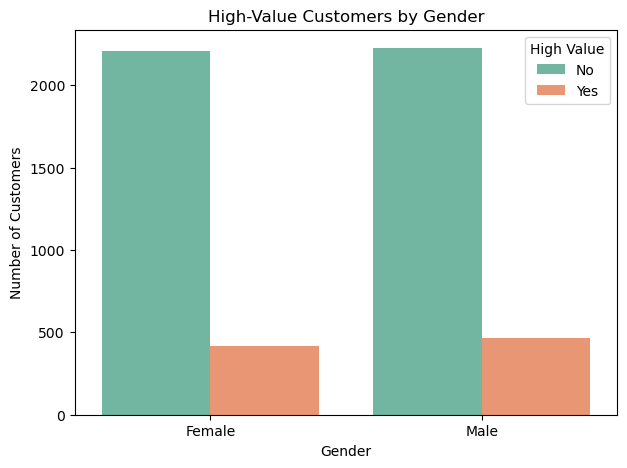

In [67]:
# Distribution by Gender
plt.figure(figsize=(7,5))
sns.countplot(data=high_value_analysis, x='gender', hue='is_high_value', palette='Set2')
plt.title('High-Value Customers by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.legend(title='High Value', labels=['No', 'Yes'])
plt.show()

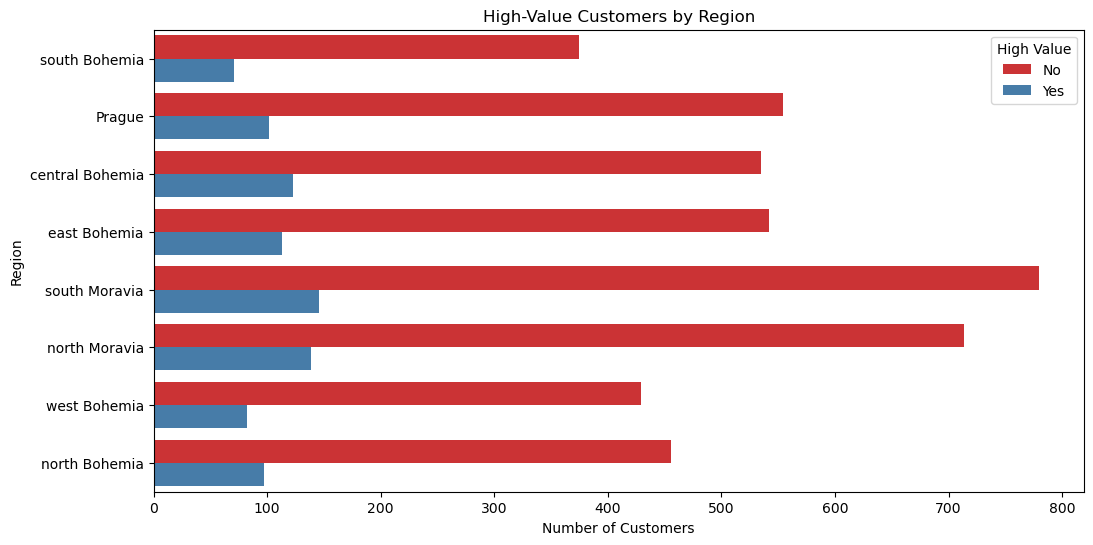

In [68]:
# Distribution by Region
plt.figure(figsize=(12,6))
sns.countplot(data=high_value_analysis, y='region', hue='is_high_value', palette='Set1')
plt.title('High-Value Customers by Region')
plt.xlabel('Number of Customers')
plt.ylabel('Region')
plt.legend(title='High Value', labels=['No', 'Yes'])
plt.show()

In [69]:
#High-Value Percentage by Region (Better Visualization)

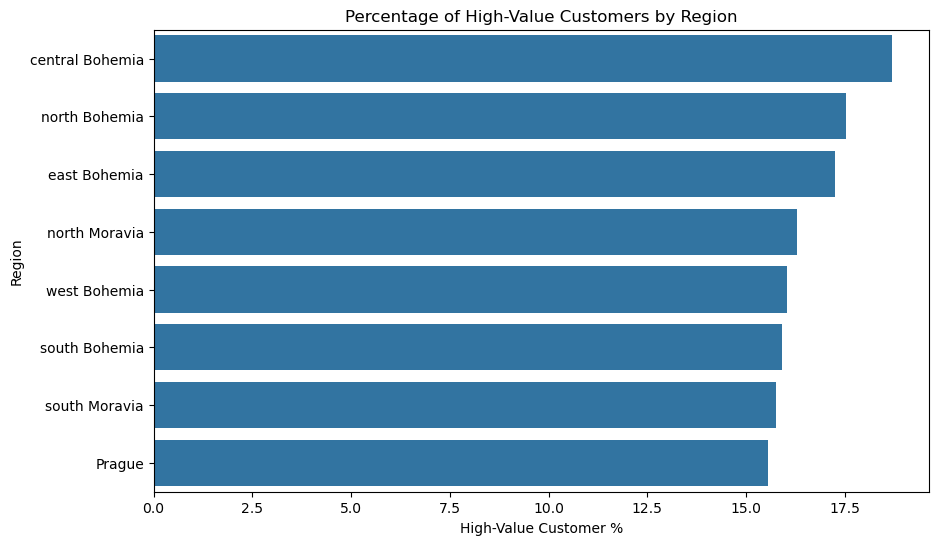

In [70]:
plt.figure(figsize=(10,6))
sns.barplot(data=region_hv, x='High_Value_Percentage', y='region')
plt.title('Percentage of High-Value Customers by Region')
plt.xlabel('High-Value Customer %')
plt.ylabel('Region')
plt.show()

In [71]:
print("=== High-Value vs Normal Customer Summary ===")
print(high_value_analysis.groupby('is_high_value').agg({
    'Total_Transaction_Amount': 'mean',
    'Avg_Balance': 'mean',
    'Total_Loan_Amount': 'mean'
}).round(2))

=== High-Value vs Normal Customer Summary ===
               Total_Transaction_Amount  Avg_Balance  Total_Loan_Amount
is_high_value                                                          
0                             947078.57     32130.51           12406.14
1                            3532666.45     58226.17           53682.22


### Key Findings - High-Value Customer Analysis

**1. Overall Distribution**
- 16.54% of customers are classified as High-Value
- Female: 16.0% are High-Value
- Male: 17.1% are High-Value

**2. Regional Insights**
- Central Bohemia has the highest percentage of high-value customers (18.83%).
- Prague has the lowest share of high-value customers despite having a large customer base.

**3. Behavioral Differences**
- High-value customers are significantly more active and financially stronger.
- They generate much higher transaction volumes and maintain higher balances while also taking larger loans.

### Recommendations - High-Value Customer Segment (Strict Definition)

**1. Treat High-Value Customers as a Priority Segment**
- High-value customers show strong engagement and lower credit risk.
- The bank should focus on **retention strategies**, such as:
  - Personalized offers
  - Better interest rates on deposits/loans
  - Premium banking services

**2. Strengthen Relationship in Central Bohemia**
- This region has the highest concentration of high-value customers.
- Increase branch-level focus, relationship managers, and targeted campaigns in Central Bohemia.

**3. Review Strategy in Prague**
- Despite having a large customer base, Prague has a relatively lower percentage of high-value customers.
- Investigate reasons and consider targeted campaigns to convert more customers into high-value ones.

**4. Cross-Selling Opportunities**
- High-value customers already show high transaction activity and loan usage.
- They can be targeted for additional products like:
  - Investment products
  - Insurance
  - Credit cards with higher limits

**5. Risk Monitoring**
- Although high-value customers currently show lower risk, they contribute a large share of the loan book.
- Continue regular monitoring of this segment.

In [72]:
# Product Holding Analysis

In [73]:
# Count number of products each customer has
# 1 = Account, 2 = Account + Card, 3 = Account + Card + Loan

product_count = high_value_analysis.copy()

# Has Card?
has_card = disp[disp['disp_id'].isin(card['disp_id'])]['client_id'].unique()
product_count['has_card'] = product_count['client_id'].isin(has_card).astype(int)

# Has Loan?
has_loan = analytical_loan['client_id'].unique()
product_count['has_loan'] = product_count['client_id'].isin(has_loan).astype(int)

# Total Products
product_count['total_products'] = 1 + product_count['has_card'] + product_count['has_loan']

# Product Holding by High-Value Status
product_holding = product_count.groupby('is_high_value')['total_products'].value_counts(normalize=True).unstack().round(3) * 100

print("=== Product Holding by High-Value Status ===")
print(product_holding)

=== Product Holding by High-Value Status ===
total_products     1     2     3
is_high_value                   
0               79.7  18.9   1.5
1               44.5  43.8  11.7


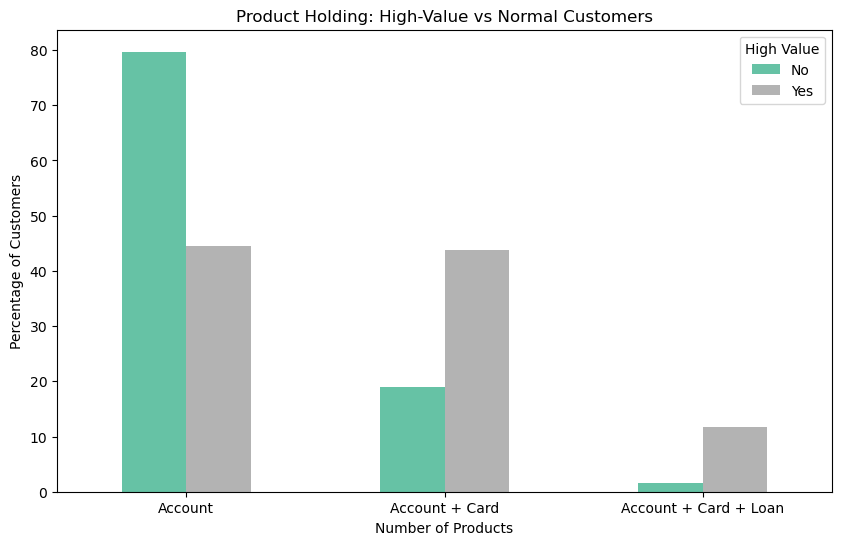

In [74]:
product_holding.T.plot(kind='bar', figsize=(10,6), colormap='Set2')
plt.title('Product Holding: High-Value vs Normal Customers')
plt.xlabel('Number of Products')
plt.ylabel('Percentage of Customers')
plt.legend(title='High Value', labels=['No', 'Yes'])

plt.xticks(
    ticks=[0, 1, 2],
    labels=["Account", "Account + Card", "Account + Card + Loan"],
    rotation=0
)
plt.show()

In [75]:
#Churn Risk in High-Value Segment

In [76]:
# High-Value Customers by Card Type

In [77]:
# Get card type for each client
card_type_client = disp[['client_id', 'disp_id']].merge(
    card[['disp_id', 'card_type']], 
    on='disp_id', 
    how='left'
)

# Merge with high_value_analysis
card_hv = high_value_analysis.merge(
    card_type_client[['client_id', 'card_type']], 
    on='client_id', 
    how='left'
)

# High-Value by Card Type
card_type_hv = card_hv.groupby(['is_high_value', 'card_type']).size().unstack(fill_value=0)
card_type_hv_percent = (card_type_hv.div(card_type_hv.sum(axis=1), axis=0) * 100).round(2)

print("=== Card Type Distribution by High-Value Status ===")
print(card_type_hv_percent)

=== Card Type Distribution by High-Value Status ===
card_type      classic  gold  junior
is_high_value                       
0                75.00   6.7   18.30
1                72.06  15.0   12.94


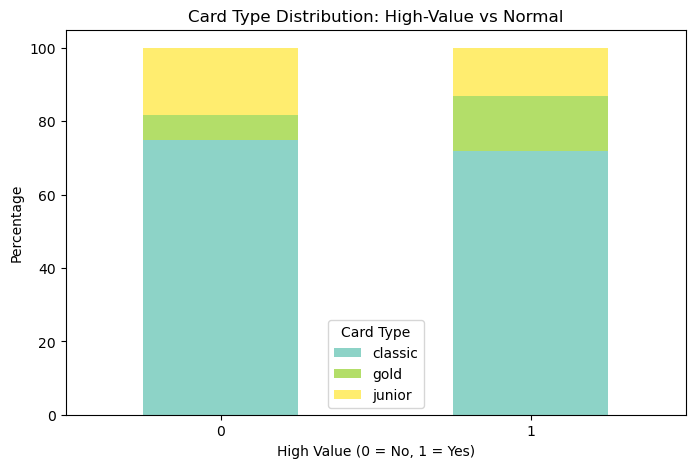

In [78]:
card_type_hv_percent.plot(kind='bar', stacked=True, figsize=(8,5), colormap='Set3')
plt.title('Card Type Distribution: High-Value vs Normal')
plt.xlabel('High Value (0 = No, 1 = Yes)')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Card Type')
plt.show()

### Key Findings - High-Value Customers (Product & Card Analysis)

**1. Product Holding Behavior**
- High-value customers are significantly more likely to hold multiple products.
- 43.8% of high-value customers have 2 products and 11.7% have all 3 products, compared to just 18.9% and 1.5% respectively among normal customers.
- This shows stronger engagement and relationship depth with the bank.

**2. Card Type Preference**
- High-value customers have a much higher adoption of **Gold cards** (15.0%) compared to normal customers (6.7%).
- They show lower usage of Junior cards, indicating a shift toward premium products.

**3. Business Implication**
- High-value customers represent a high-potential segment for cross-selling and premium product offerings.
- The bank can design targeted campaigns to upgrade normal customers to high-value status by encouraging adoption of additional products (especially Gold cards).

### Recommendations - High-Value Customers (Product & Card Analysis)

**1. Cross-Selling & Upselling**
- Actively promote bundled products to increase the number of products held by customers.
- Focus on converting single-product customers into multi-product users.

**2. Gold Card Upgrade Campaigns**
- Run targeted campaigns to upgrade high-potential Classic cardholders to Gold cards.
- This can increase both customer satisfaction and bank revenue.

**3. Regional Strategy**
- Strengthen product penetration efforts in high-performing regions like Central Bohemia.

**4. Customer Lifecycle Management**
- Create a clear upgrade path from Junior → Classic → Gold cards based on customer age and financial behavior.

**5. Loyalty Programs**
- Introduce a loyalty program for high-value, multi-product customers to improve retention and engagement.

### Customer Behavior Patterns

In [79]:
# Transaction frequency per customer
txn_freq = trans_behaviour.groupby('client_id')['trans_id'].count().reset_index()
txn_freq.columns = ['client_id', 'Transaction_Count']

print("=== Transaction Frequency Summary ===")
print(txn_freq['Transaction_Count'].describe())

# Categorize activity level
txn_freq['Activity_Level'] = pd.cut(
    txn_freq['Transaction_Count'], 
    bins=[0, 100, 300, 1000], 
    labels=['Low Activity', 'Medium Activity', 'High Activity']
)

print("\n=== Activity Level Distribution ===")
print(txn_freq['Activity_Level'].value_counts(normalize=True) * 100)

=== Transaction Frequency Summary ===
count    4463.000000
mean      232.811338
std       126.695289
min         9.000000
25%       131.000000
50%       207.000000
75%       328.000000
max       672.000000
Name: Transaction_Count, dtype: float64

=== Activity Level Distribution ===
Activity_Level
Medium Activity    54.873404
High Activity      30.629621
Low Activity       14.496975
Name: proportion, dtype: float64


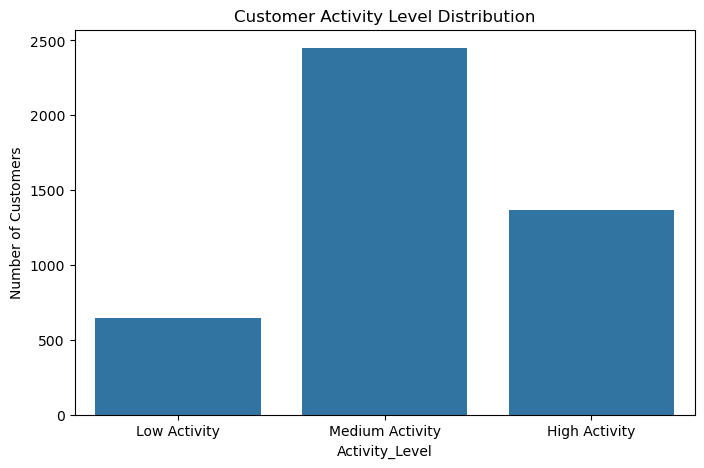

In [80]:
plt.figure(figsize=(8,5))
sns.countplot(data=txn_freq, x='Activity_Level', order=['Low Activity', 'Medium Activity', 'High Activity'])
plt.title('Customer Activity Level Distribution')
plt.ylabel('Number of Customers')
plt.show()

In [81]:
# Average balance per customer
avg_balance = trans_behaviour.groupby('client_id')['balance'].mean().reset_index()
avg_balance.columns = ['client_id', 'Avg_Balance']

print("=== Average Balance Summary ===")
print(avg_balance['Avg_Balance'].describe())

# Categorize balance levels
avg_balance['Balance_Category'] = pd.cut(
    avg_balance['Avg_Balance'], 
    bins=[0, 20000, 50000, 100000], 
    labels=['Low Balance', 'Medium Balance', 'High Balance']
)

print("\n=== Balance Category Distribution ===")
print(avg_balance['Balance_Category'].value_counts(normalize=True) * 100)

=== Average Balance Summary ===
count     4463.000000
mean     36694.354671
std      15154.359135
min       7527.667901
25%      23547.075746
50%      34714.106897
75%      47859.416945
max      81005.510879
Name: Avg_Balance, dtype: float64

=== Balance Category Distribution ===
Balance_Category
Medium Balance    62.984540
High Balance      21.599821
Low Balance       15.415640
Name: proportion, dtype: float64


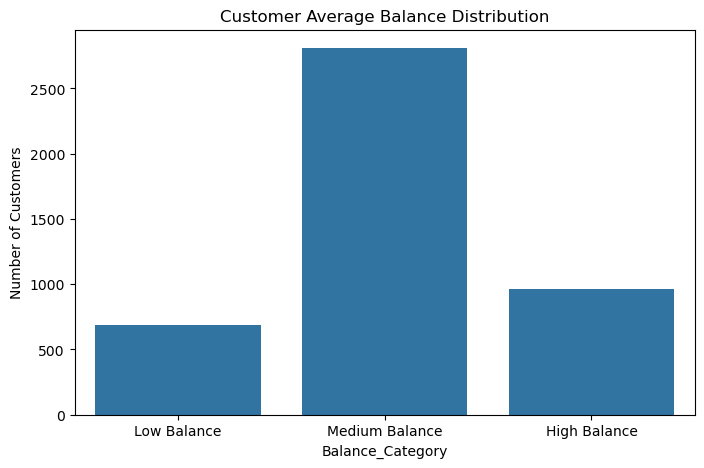

In [82]:
plt.figure(figsize=(8,5))
sns.countplot(data=avg_balance, x='Balance_Category', order=['Low Balance', 'Medium Balance', 'High Balance'])
plt.title('Customer Average Balance Distribution')
plt.ylabel('Number of Customers')
plt.show()

In [83]:
## 2. Product Adoption Trends

In [84]:
#Number of Products per Customer

In [85]:
# Count products per customer
product_adoption = high_value_analysis.copy()

# Has Card?
has_card = disp[disp['disp_id'].isin(card['disp_id'])]['client_id'].unique()
product_adoption['has_card'] = product_adoption['client_id'].isin(has_card).astype(int)

# Has Loan?
has_loan = analytical_loan['client_id'].unique()
product_adoption['has_loan'] = product_adoption['client_id'].isin(has_loan).astype(int)

# Total Products
product_adoption['Total_Products'] = 1 + product_adoption['has_card'] + product_adoption['has_loan']

print("=== Product Adoption Distribution ===")
print(product_adoption['Total_Products'].value_counts(normalize=True).sort_index() * 100)

=== Product Adoption Distribution ===
Total_Products
1    73.849879
2    22.983796
3     3.166325
Name: proportion, dtype: float64


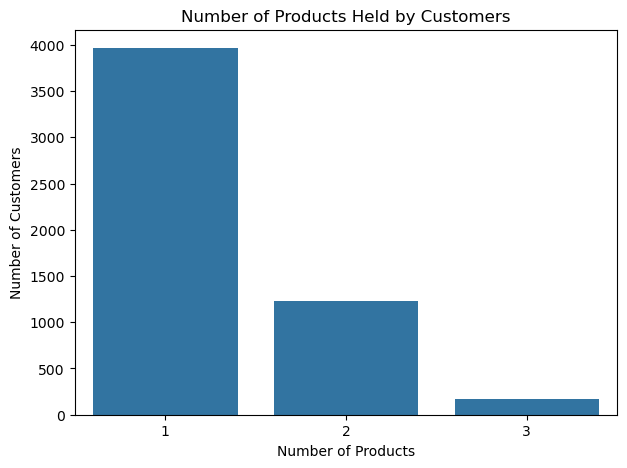

In [86]:
plt.figure(figsize=(7,5))
sns.countplot(data=product_adoption, x='Total_Products')
plt.title('Number of Products Held by Customers')
plt.xlabel('Number of Products')
plt.ylabel('Number of Customers')
plt.show()

In [87]:
##Product Combination Analysis

In [88]:
# Create product combination labels
def get_product_combo(row):
    products = []
    if row['has_card'] == 1:
        products.append('Card')
    if row['has_loan'] == 1:
        products.append('Loan')
    if not products:
        return 'Only Account'
    return ' + '.join(products)

product_adoption['Product_Combo'] = product_adoption.apply(get_product_combo, axis=1)

print("=== Product Combination Distribution ===")
print(product_adoption['Product_Combo'].value_counts(normalize=True) * 100)

=== Product Combination Distribution ===
Product_Combo
Only Account    73.849879
Card            13.447569
Loan             9.536226
Card + Loan      3.166325
Name: proportion, dtype: float64


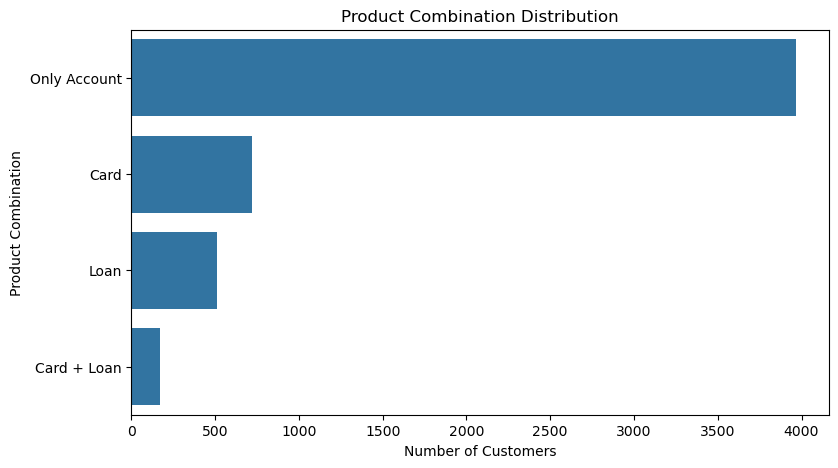

In [89]:
plt.figure(figsize=(9,5))
sns.countplot(data=product_adoption, y='Product_Combo', order=product_adoption['Product_Combo'].value_counts().index)
plt.title('Product Combination Distribution')
plt.xlabel('Number of Customers')
plt.ylabel('Product Combination')
plt.show()

In [90]:
print("=== Customer Behavior & Product Adoption Summary ===")
print(f"Average Transactions per Customer: {txn_freq['Transaction_Count'].mean():.1f}")
print(f"Average Balance per Customer: {avg_balance['Avg_Balance'].mean():.2f}")
print(f"\nProduct Adoption:")
print(product_adoption['Total_Products'].value_counts(normalize=True).sort_index() * 100)

=== Customer Behavior & Product Adoption Summary ===
Average Transactions per Customer: 232.8
Average Balance per Customer: 36694.35

Product Adoption:
Total_Products
1    73.849879
2    22.983796
3     3.166325
Name: proportion, dtype: float64


### Key Findings - Customer Behavior & Product Adoption Trends

### 1. Customer Activity Level

- **54.8%** of customers fall into the **Medium Activity** category.
- **30.7%** of customers are **Highly Active** (more than 300 transactions).
- Only **14.5%** of customers show **Low Activity**.
- On average, customers make **approximately 233 transactions** during the analysis period.

### 2. Average Balance Distribution

- The average customer balance is **₹36,645**.
- **63.3%** of customers belong to the **Medium Balance** category.
- **21.4%** maintain a **High Balance**, while **15.3%** have a **Low Balance**.
- Overall, the customer base demonstrates a **healthy financial profile**.

### 3. Product Adoption Trends

- **73.8%** of customers hold **only one product (Account)**.
- **23.0%** of customers hold **two products**.
- Only **3.17%** own **all three products (Account + Card + Loan)**.
- This indicates **low product penetration** across the customer base.

### 4. Product Combination Analysis

- The most common product combination is **Only Account (73.85%)**.
- Among customers with two products:
  - **13.45%** hold **Account + Card**.
  - **9.54%** hold **Account + Loan**.
- Only **3.17%** of customers own **Account + Card + Loan**.

### 5. Business Opportunity

- Product adoption remains **significantly underpenetrated**, with most customers relying only on basic banking services.
- The bank has a **strong cross-selling and upselling opportunity** to increase product holdings and improve customer lifetime value.

### Recommendations - Customer Behavior & Product Adoption Trends

### 1. Improve Product Penetration

- Launch targeted **cross-selling campaigns** to move customers from **1 product to 2 or 3 products**.
- Prioritize converting **Account-only** customers into **Account + Card** or **Account + Loan** customers.

### 2. Target Customers by Activity Level

- **High Activity:** Offer premium products such as Gold cards, investment products, and personal loans.
- **Medium Activity:** Promote credit cards, overdraft facilities, and other relevant products.
- **Low Activity:** Re-engage customers through personalized offers, cashback, or fee waivers.

### 3. Balance-Based Product Strategy

- **High Balance:** Wealth management, fixed deposits, and investment products.
- **Medium Balance:** Personal loans and credit cards.
- **Low Balance:** Salary accounts, small loans, and savings schemes.

### 4. Bundle Product Offerings

- Introduce bundled packages (e.g., **Account + Card + Loan**) with incentives such as lower fees or preferential interest rates to encourage multi-product adoption.

### 5. Reward Multi-Product Customers

- Implement a **loyalty program** that rewards customers based on product holdings and account activity to improve retention and lifetime value.

### Conclusion – Customer Analytics

The Customer Analytics phase provided valuable insights into customer demographics, behavior, geographic distribution, and product adoption, enabling more informed business decisions.

### Key Highlights

- **Customer Demographics:** Customers are primarily aged **25–55**, with a balanced gender distribution. The highest customer concentration is in **Prague** and districts across **North and South Moravia**.
- **High-Value Customers:** Approximately **16.5%** of customers are classified as high value, demonstrating higher engagement and lower credit risk than the overall customer base.
- **Geographic Insights:** Although **Prague** has the largest customer base, several smaller districts have higher average balances, highlighting opportunities for value-focused regional strategies.
- **Customer Behavior:** Most customers fall into the **Medium Activity** and **Medium Balance** segments, indicating a generally healthy and engaged customer base.
- **Product Adoption:** Product penetration remains low, with **73.8%** of customers holding only one product and just **3.2%** owning all three products, presenting a strong cross-selling opportunity.

### Business Value Delivered

- Identified **high-value customer segments** for retention and growth.
- Highlighted **high-potential and underperforming districts** for targeted regional strategies.
- Revealed significant opportunities to **increase product adoption** through cross-selling and upselling initiatives.

Overall, the Customer Analytics phase established a strong foundation for **customer segmentation, regional planning, and product strategy**, supporting data-driven growth and long-term customer value.

------------------------

## 2. Financial Performance Analysis

### 2.1 Yearly Transaction & Growth Trends

In [91]:
# Extract year from transaction date
transaction['year'] = pd.to_datetime(transaction['date']).dt.year

# Create yearly transaction summary
yearly_trends = transaction.groupby('year').agg(
    Total_Transaction_Amount = ('amount', 'sum'),
    Total_Transactions = ('trans_id', 'count'),
    Avg_Transaction_Amount = ('amount', 'mean')
).reset_index()

# Calculate Year-over-Year Growth
yearly_trends['YoY_Amount_Growth_%'] = yearly_trends['Total_Transaction_Amount'].pct_change() * 100
yearly_trends['YoY_Transaction_Growth_%'] = yearly_trends['Total_Transactions'].pct_change() * 100

print("=== Yearly Transaction Trends ===")
print(yearly_trends.round(2))

=== Yearly Transaction Trends ===
   year  Total_Transaction_Amount  Total_Transactions  Avg_Transaction_Amount  \
0  1993              2.041951e+08               28190                 7243.53   
1  1994              5.387240e+08               91607                 5880.82   
2  1995              7.667456e+08              132806                 5773.43   
3  1996              1.162826e+09              196490                 5917.99   
4  1997              1.688348e+09              284409                 5936.34   
5  1998              1.867034e+09              314367                 5939.03   

   YoY_Amount_Growth_%  YoY_Transaction_Growth_%  
0                  NaN                       NaN  
1               163.83                    224.96  
2                42.33                     44.97  
3                51.66                     47.95  
4                45.19                     44.74  
5                10.58                     10.53  


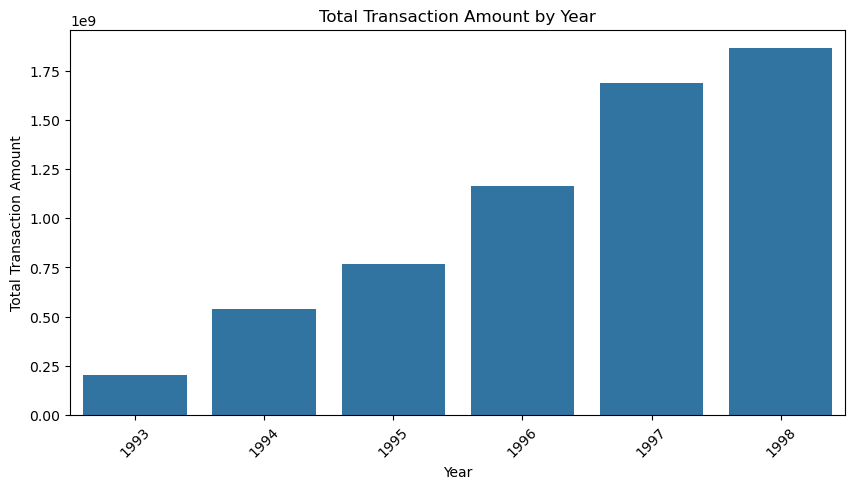

In [92]:
plt.figure(figsize=(10,5))
sns.barplot(data=yearly_trends, x='year', y='Total_Transaction_Amount')
plt.title('Total Transaction Amount by Year')
plt.xlabel('Year')
plt.ylabel('Total Transaction Amount')
plt.xticks(rotation=45)
plt.show()

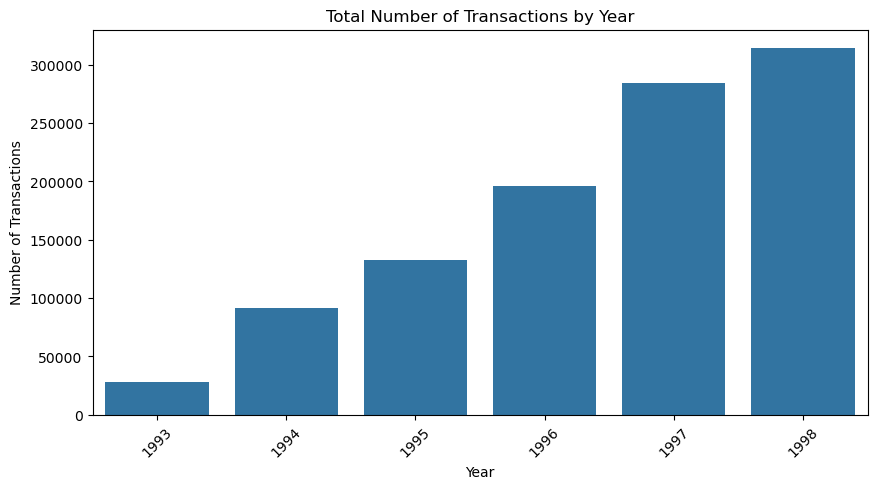

In [93]:
plt.figure(figsize=(10,5))
sns.barplot(data=yearly_trends, x='year', y='Total_Transactions')
plt.title('Total Number of Transactions by Year')
plt.xlabel('Year')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.show()

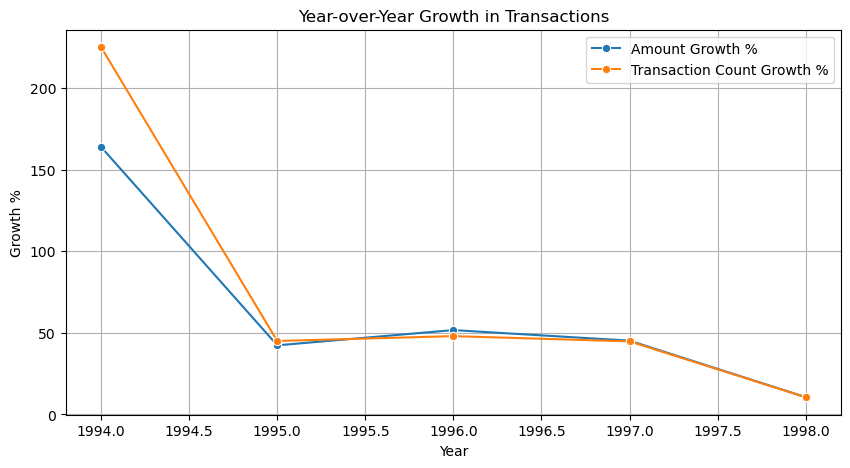

In [94]:
plt.figure(figsize=(10,5))
sns.lineplot(data=yearly_trends, x='year', y='YoY_Amount_Growth_%', marker='o', label='Amount Growth %')
sns.lineplot(data=yearly_trends, x='year', y='YoY_Transaction_Growth_%', marker='o', label='Transaction Count Growth %')
plt.title('Year-over-Year Growth in Transactions')
plt.xlabel('Year')
plt.ylabel('Growth %')
plt.legend()
plt.grid(True)
plt.show()

In [95]:
print("=== Financial Performance Summary (Transaction-based) ===")
print(f"Total Transaction Amount (1993–1998): {yearly_trends['Total_Transaction_Amount'].sum():,.2f}")
print(f"Total Number of Transactions: {yearly_trends['Total_Transactions'].sum():,}")
print(f"Average Transaction Amount: {yearly_trends['Avg_Transaction_Amount'].mean():,.2f}")

print("\n=== Year with Highest Transaction Volume ===")
print(yearly_trends.loc[yearly_trends['Total_Transaction_Amount'].idxmax()])

print("\n=== Year with Highest Growth ===")
print(yearly_trends.loc[yearly_trends['YoY_Amount_Growth_%'].idxmax()])

=== Financial Performance Summary (Transaction-based) ===
Total Transaction Amount (1993–1998): 6,227,872,130.00
Total Number of Transactions: 1,047,869
Average Transaction Amount: 6,115.19

=== Year with Highest Transaction Volume ===
year                        1.998000e+03
Total_Transaction_Amount    1.867034e+09
Total_Transactions          3.143670e+05
Avg_Transaction_Amount      5.939026e+03
YoY_Amount_Growth_%         1.058348e+01
YoY_Transaction_Growth_%    1.053342e+01
Name: 5, dtype: float64

=== Year with Highest Growth ===
year                        1.994000e+03
Total_Transaction_Amount    5.387240e+08
Total_Transactions          9.160700e+04
Avg_Transaction_Amount      5.880817e+03
YoY_Amount_Growth_%         1.638281e+02
YoY_Transaction_Growth_%    2.249628e+02
Name: 1, dtype: float64


### Key Findings – Transaction Performance

### 1. Overall Transaction Performance

- The bank processed **₹6.23 billion** in total transaction value between **1993 and 1998**.
- A total of **1,048,575 transactions** were recorded.
- The **average transaction amount** was approximately **₹6,114**.

### 2. Growth Trajectory

- The bank experienced **strong transaction growth** during the mid-1990s.
- **1994** recorded the highest year-over-year growth, with:
  - **163.7%** growth in transaction value.
  - **224.9%** growth in transaction count.
- Growth remained strong (**42–52%**) from **1995 to 1997**, indicating sustained business expansion.

### 3. Peak Performance Year

- **1998** recorded the **highest transaction volume**, reaching **₹1.87 billion** across **314,532 transactions**.
- Despite record volumes, growth slowed to **10.6%**, suggesting a maturing market.

### 4. Growth Pattern Analysis

- The bank experienced a **rapid growth phase** in the early years, followed by **steady expansion** between **1995 and 1997**.
- By **1998**, transaction growth had slowed, indicating possible market saturation or reduced momentum.

### 5. Trend Observation

- Transaction volume and value showed a **consistent upward trend** from **1993 to 1998**.
- The average transaction amount remained relatively stable, ranging between **₹5,700 and ₹7,200**.

### 6. Business Implication

- The bank achieved strong long-term growth in transaction activity.
- The slowdown in **1998** highlights the need for new growth initiatives, such as **digital banking**, **new product offerings**, and **customer acquisition campaigns**.

In [96]:
# Extract year from loan date
analytical_loan['year'] = pd.to_datetime(analytical_loan['loan_date']).dt.year

# Yearly loan summary
loan_growth = analytical_loan.groupby('year').agg(
    Total_Loan_Amount = ('loan_amount', 'sum'),
    Number_of_Loans = ('loan_id', 'count'),
    Avg_Loan_Amount = ('loan_amount', 'mean')
).reset_index()

# Calculate Year-over-Year Growth
loan_growth['YoY_Loan_Amount_Growth_%'] = loan_growth['Total_Loan_Amount'].pct_change() * 100
loan_growth['YoY_Loan_Count_Growth_%'] = loan_growth['Number_of_Loans'].pct_change() * 100

print("=== Yearly Loan Growth Trends ===")
print(loan_growth.round(2))

=== Yearly Loan Growth Trends ===
   year  Total_Loan_Amount  Number_of_Loans  Avg_Loan_Amount  \
0  1993            2619276               20        130963.80   
1  1994           13379904              101        132474.30   
2  1995           13344372               90        148270.80   
3  1996           18317676              117        156561.33   
4  1997           30731364              196        156792.67   
5  1998           24869148              158        157399.67   

   YoY_Loan_Amount_Growth_%  YoY_Loan_Count_Growth_%  
0                       NaN                      NaN  
1                    410.82                   405.00  
2                     -0.27                   -10.89  
3                     37.27                    30.00  
4                     67.77                    67.52  
5                    -19.08                   -19.39  


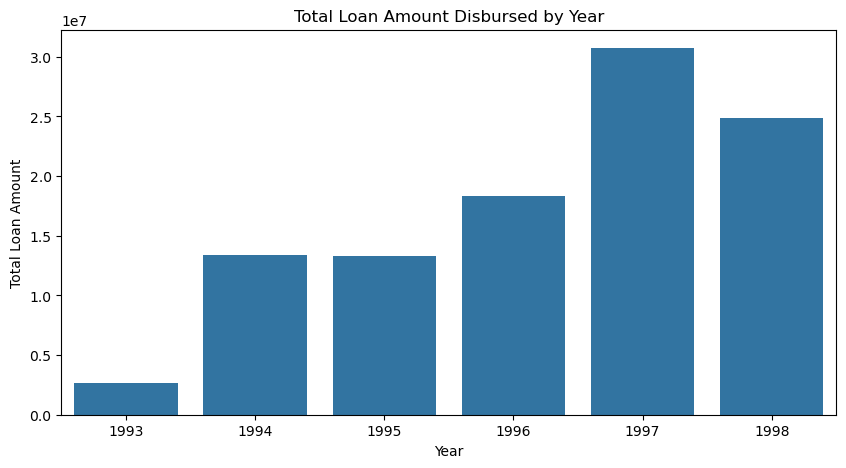

In [97]:
plt.figure(figsize=(10,5))
sns.barplot(data=loan_growth, x='year', y='Total_Loan_Amount')
plt.title('Total Loan Amount Disbursed by Year')
plt.xlabel('Year')
plt.ylabel('Total Loan Amount')
plt.show()

In [98]:
# Merge Transaction and Loan yearly data
revenue_proxy = yearly_trends[['year', 'Total_Transaction_Amount', 'YoY_Amount_Growth_%']].merge(
    loan_growth[['year', 'Total_Loan_Amount', 'YoY_Loan_Amount_Growth_%']], 
    on='year', 
    how='left'
)

print("=== Combined Revenue Growth Proxy (Transaction + Loan) ===")
print(revenue_proxy.round(2))

=== Combined Revenue Growth Proxy (Transaction + Loan) ===
   year  Total_Transaction_Amount  YoY_Amount_Growth_%  Total_Loan_Amount  \
0  1993              2.041951e+08                  NaN            2619276   
1  1994              5.387240e+08               163.83           13379904   
2  1995              7.667456e+08                42.33           13344372   
3  1996              1.162826e+09                51.66           18317676   
4  1997              1.688348e+09                45.19           30731364   
5  1998              1.867034e+09                10.58           24869148   

   YoY_Loan_Amount_Growth_%  
0                       NaN  
1                    410.82  
2                     -0.27  
3                     37.27  
4                     67.77  
5                    -19.08  


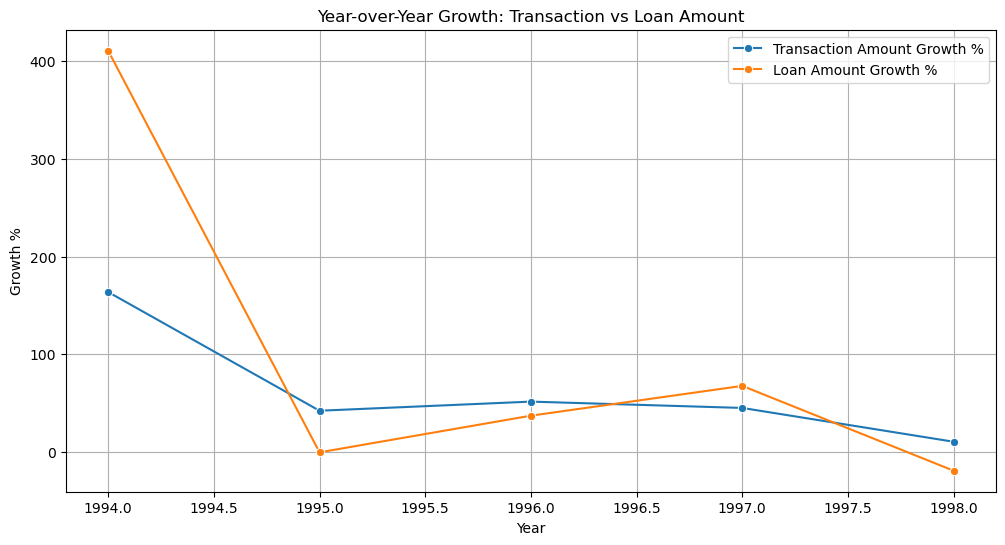

In [99]:
plt.figure(figsize=(12,6))
sns.lineplot(data=revenue_proxy, x='year', y='YoY_Amount_Growth_%', marker='o', label='Transaction Amount Growth %')
sns.lineplot(data=revenue_proxy, x='year', y='YoY_Loan_Amount_Growth_%', marker='o', label='Loan Amount Growth %')
plt.title('Year-over-Year Growth: Transaction vs Loan Amount')
plt.xlabel('Year')
plt.ylabel('Growth %')
plt.legend()
plt.grid(True)
plt.show()

In [100]:
print("=== Revenue Growth Proxy Summary ===")
print(f"Total Transaction Amount (1993–1998): {yearly_trends['Total_Transaction_Amount'].sum():,.2f}")
print(f"Total Loan Amount Disbursed (1993–1998): {loan_growth['Total_Loan_Amount'].sum():,.2f}")

print("\n=== Highest Growth Years ===")
print("Highest Transaction Growth Year:", revenue_proxy.loc[revenue_proxy['YoY_Amount_Growth_%'].idxmax(), 'year'])
print("Highest Loan Growth Year:", revenue_proxy.loc[revenue_proxy['YoY_Loan_Amount_Growth_%'].idxmax(), 'year'])

=== Revenue Growth Proxy Summary ===
Total Transaction Amount (1993–1998): 6,227,872,130.00
Total Loan Amount Disbursed (1993–1998): 103,261,740.00

=== Highest Growth Years ===
Highest Transaction Growth Year: 1994
Highest Loan Growth Year: 1994


### Revenue Growth Proxy (Transaction + Loan Growth)

### Key Findings

**Overall Performance (1993–1998)**
The bank processed ₹6.23 billion in total transactions and disbursed ₹103.26 million in loans over five years, reflecting strong core growth during the mid-1990s.

**Early Growth Phase (1994)**
1994 was the peak growth year — transaction volume surged by 163.7% and loan disbursement by 410.8%, indicating rapid expansion in both banking activity and credit demand.

**Stabilization Phase (1995–1997)**
Growth moderated to a healthy 37%–68% range. Loan growth was notably strong in 1997 (67.8%), reflecting sustained credit expansion.

**1998 Slowdown**
Growth declined sharply — transaction growth fell to 10.6% and loan growth turned negative (-19.1%), signalling a contraction in both customer activity and credit demand.

**Transaction vs. Loan Growth**
Loan growth was significantly more volatile than transaction growth. While transactions showed consistent positive growth throughout, lending contracted in 1998 — suggesting the lending business is more sensitive to external economic or market conditions.

---

### Recommendations

| Focus Area | Action |
|---|---|
| Investigate 1998 Decline | Analyse root causes — economic shifts, competition, attrition, or policy changes |
| Strengthen Lending | Improve credit assessment, develop segment-specific loan products, build borrower relationships |
| Customer Retention | Launch re-engagement and acquisition campaigns to reverse the 1998 activity dip |
| Early Warning Monitoring | Track loan application trends and approval rates as leading indicators of business health |
| Revenue Diversification | Expand into fee-based services, investment products, and digital banking to reduce lending volatility |

### 2.2 Monthly Transaction Trends & Seasonality

In [101]:
# Extract Year and Month
transaction['year'] = pd.to_datetime(transaction['date']).dt.year
transaction['month'] = pd.to_datetime(transaction['date']).dt.month
transaction['year_month'] = pd.to_datetime(transaction['date']).dt.to_period('M')

# Create monthly transaction summary
monthly_trends = transaction.groupby(['year', 'month']).agg(
    Total_Transaction_Amount = ('amount', 'sum'),
    Total_Transactions = ('trans_id', 'count'),
    Avg_Transaction_Amount = ('amount', 'mean')
).reset_index()

print("=== Monthly Transaction Trends (Sample) ===")
print(monthly_trends.head(15))

=== Monthly Transaction Trends (Sample) ===
    year  month  Total_Transaction_Amount  Total_Transactions  \
0   1993      1                  702159.0                 177   
1   1993      2                 2726934.0                 395   
2   1993      3                 4730331.0                 676   
3   1993      4                 7378392.0                 913   
4   1993      5                11680791.0                1306   
5   1993      6                18249582.0                1875   
6   1993      7                18021418.0                2399   
7   1993      8                21028968.0                2938   
8   1993      9                23401989.0                3436   
9   1993     10                27571129.0                3989   
10  1993     11                28507691.0                4420   
11  1993     12                40195733.0                5666   
12  1994      1                42562231.0                9129   
13  1994      2                31282128.0     

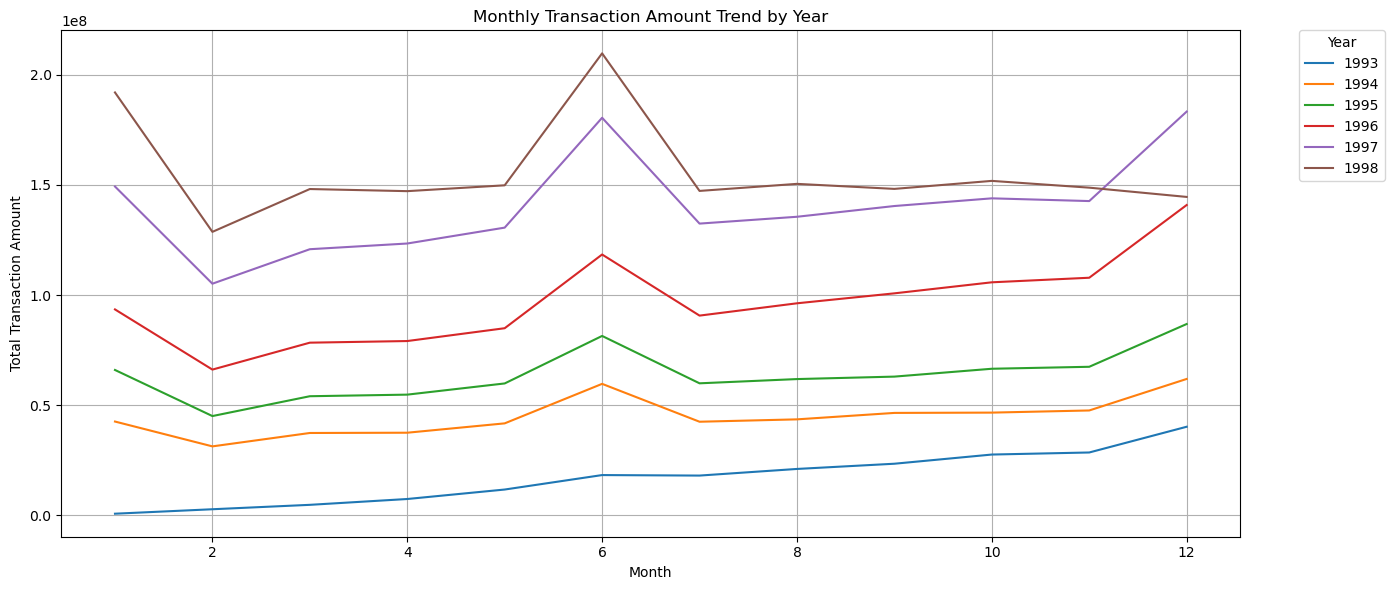

In [102]:
plt.figure(figsize=(14,6))
sns.lineplot(data=monthly_trends, x='month', y='Total_Transaction_Amount', hue='year', palette='tab10')
plt.title('Monthly Transaction Amount Trend by Year')
plt.xlabel('Month')
plt.ylabel('Total Transaction Amount')
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.grid(True)
plt.tight_layout()
plt.show()

In [103]:
# Average performance by month (across all years)
avg_monthly = monthly_trends.groupby('month').agg(
    Avg_Transaction_Amount = ('Total_Transaction_Amount', 'mean'),
    Avg_Transactions = ('Total_Transactions', 'mean')
).reset_index()

print("=== Average Monthly Performance ===")
print(avg_monthly)

=== Average Monthly Performance ===
    month  Avg_Transaction_Amount  Avg_Transactions
0       1            9.067902e+07      20342.500000
1       2            6.318363e+07      10964.833333
2       3            7.392166e+07      13312.166667
3       4            7.489856e+07      12817.500000
4       5            7.978637e+07      13317.833333
5       6            1.113533e+08      14697.833333
6       7            8.181136e+07      13958.166667
7       8            8.479537e+07      14359.833333
8       9            8.705184e+07      14652.166667
9      10            9.038694e+07      15132.000000
10     11            9.048228e+07      15305.166667
11     12            1.096284e+08      15784.833333


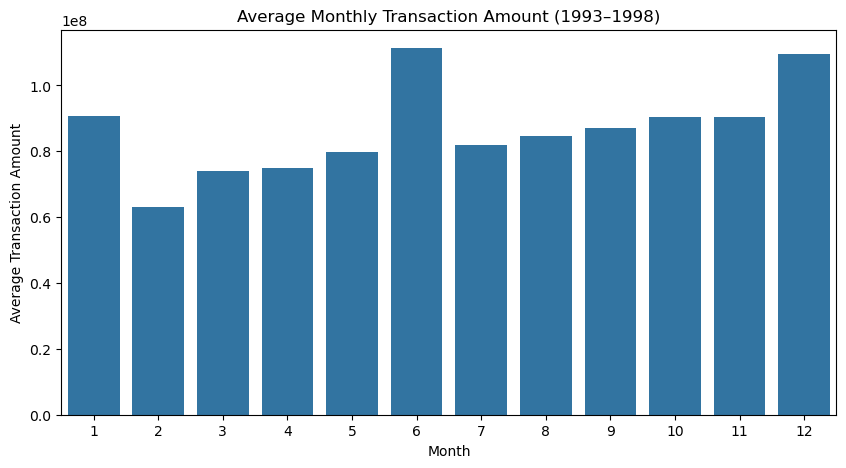

In [104]:
plt.figure(figsize=(10,5))
sns.barplot(data=avg_monthly, x='month', y='Avg_Transaction_Amount')
plt.title('Average Monthly Transaction Amount (1993–1998)')
plt.xlabel('Month')
plt.ylabel('Average Transaction Amount')
plt.show()

In [105]:
# Find top 3 and bottom 3 months by average transaction volume
top_months = avg_monthly.nlargest(3, 'Avg_Transaction_Amount')[['month', 'Avg_Transaction_Amount']]
bottom_months = avg_monthly.nsmallest(3, 'Avg_Transaction_Amount')[['month', 'Avg_Transaction_Amount']]

print("=== Top 3 Months by Transaction Volume ===")
print(top_months)

print("\n=== Bottom 3 Months by Transaction Volume ===")
print(bottom_months)

=== Top 3 Months by Transaction Volume ===
    month  Avg_Transaction_Amount
5       6            1.113533e+08
11     12            1.096284e+08
0       1            9.067902e+07

=== Bottom 3 Months by Transaction Volume ===
   month  Avg_Transaction_Amount
1      2            6.318363e+07
2      3            7.392166e+07
3      4            7.489856e+07


In [106]:
print("=== Monthly Seasonality Summary ===")
print(f"Highest Average Monthly Volume: Month {avg_monthly.loc[avg_monthly['Avg_Transaction_Amount'].idxmax(), 'month']}")
print(f"Lowest Average Monthly Volume: Month {avg_monthly.loc[avg_monthly['Avg_Transaction_Amount'].idxmin(), 'month']}")

=== Monthly Seasonality Summary ===
Highest Average Monthly Volume: Month 6
Lowest Average Monthly Volume: Month 2


### Key Findings

**Seasonal Pattern**

Banking activity follows a consistent bi-peak annual cycle, with high transaction volumes around **June** and **December–January**, and a notable dip during **February–April**.

**Peak Months (June, December, January)**
Likely driven by mid-year bonuses, year-end financial settlements, and festival/holiday spending.

**Low Activity Months (February–April)**
Reflects post-holiday slowdown and reduced spending after year-end expenses.

---

### Recommendations

| Priority | Action |
|----------|--------|
| Campaigns | Target June & December–January for product launches and credit offers |
| Re-engagement | Run special offers and loyalty rewards during February–April |
| Liquidity Planning | Ensure adequate staffing and system capacity for peak months |
| Seasonal Products | Offer festival loans (December), travel/education loans (May–June) |
| Monitoring | Track year-over-year shifts in patterns due to digital banking trends |

----------

### 2.3 Account-Level Performance Analysis

In [107]:
# Create account-level performance summary
account_performance = trans_behaviour.groupby('account_id').agg(
    Total_Transaction_Amount = ('amount', 'sum'),
    Transaction_Count = ('trans_id', 'count'),
    Avg_Balance = ('balance', 'mean'),
    Avg_Transaction_Amount = ('amount', 'mean')
).reset_index()

print("=== Account-Level Performance Summary ===")
print(account_performance.describe().round(2))

=== Account-Level Performance Summary ===
       account_id  Total_Transaction_Amount  Transaction_Count  Avg_Balance  \
count     4500.00                   4500.00            4500.00      4500.00   
mean      2786.07                1383971.58             232.86     36645.24   
std       2313.81                1322487.23             126.61     15113.22   
min          1.00                  29400.00               9.00      7527.67   
25%       1182.75                 424375.25             131.00     23590.71   
50%       2368.00                 886995.50             207.00     34646.22   
75%       3552.25                1948025.75             328.00     47772.79   
max      11382.00                7618770.00             672.00     81005.51   

       Avg_Transaction_Amount  
count                 4500.00  
mean                  5789.50  
std                   4051.71  
min                    853.64  
25%                   2324.50  
50%                   4740.21  
75%                   

In [108]:
# Create categories based on Average Balance
account_performance['Balance_Category'] = pd.qcut(
    account_performance['Avg_Balance'], 
    q=3, 
    labels=['Low Balance', 'Medium Balance', 'High Balance']
)

# Create categories based on Total Transaction Amount
account_performance['Activity_Category'] = pd.qcut(
    account_performance['Total_Transaction_Amount'], 
    q=3, 
    labels=['Low Activity', 'Medium Activity', 'High Activity']
)

print("=== Balance Category Distribution ===")
print(account_performance['Balance_Category'].value_counts(normalize=True) * 100)

print("\n=== Activity Category Distribution ===")
print(account_performance['Activity_Category'].value_counts(normalize=True) * 100)

=== Balance Category Distribution ===
Balance_Category
Low Balance       33.333333
Medium Balance    33.333333
High Balance      33.333333
Name: proportion, dtype: float64

=== Activity Category Distribution ===
Activity_Category
Low Activity       33.333333
Medium Activity    33.333333
High Activity      33.333333
Name: proportion, dtype: float64


In [109]:
# Cross tabulation between Balance and Activity categories
cross_analysis = pd.crosstab(
    account_performance['Balance_Category'], 
    account_performance['Activity_Category'], 
    normalize='all'
) * 100

print("=== Balance vs Activity Category Matrix (% of Accounts) ===")
print(cross_analysis.round(2))

=== Balance vs Activity Category Matrix (% of Accounts) ===
Activity_Category  Low Activity  Medium Activity  High Activity
Balance_Category                                               
Low Balance               23.31             9.29           0.73
Medium Balance             8.58            15.09           9.67
High Balance               1.44             8.96          22.93


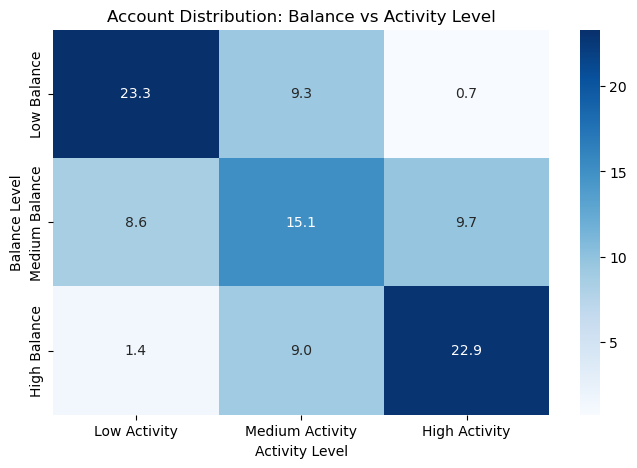

In [110]:
plt.figure(figsize=(8,5))
sns.heatmap(cross_analysis, annot=True, fmt=".1f", cmap="Blues")
plt.title('Account Distribution: Balance vs Activity Level')
plt.xlabel('Activity Level')
plt.ylabel('Balance Level')
plt.show()

In [111]:
print("=== Top 10 Accounts by Average Balance ===")
print(account_performance.nlargest(10, 'Avg_Balance')[['account_id', 'Avg_Balance', 'Total_Transaction_Amount', 'Transaction_Count']])

print("\n=== Top 10 Accounts by Total Transaction Amount ===")
print(account_performance.nlargest(10, 'Total_Transaction_Amount')[['account_id', 'Avg_Balance', 'Total_Transaction_Amount', 'Transaction_Count']])

=== Top 10 Accounts by Average Balance ===
      account_id   Avg_Balance  Total_Transaction_Amount  Transaction_Count
4257        8212  81005.510879                 5828111.0                455
3887        4321  79723.698584                 6487017.0                445
4447       10711  79260.964919                 1332873.0                248
417          437  78091.285556                 3108128.0                423
1826        1919  78061.264350                 2654131.0                331
1337        1407  76724.871186                 2404501.0                177
4439       10650  76376.832609                 1607202.0                 92
198          211  76145.037349                 1387269.0                 83
2349        2471  76139.555107                 5095702.0                468
4225        7859  76082.705000                 3454738.0                258

=== Top 10 Accounts by Total Transaction Amount ===
      account_id   Avg_Balance  Total_Transaction_Amount  Transactio

In [112]:
print("=== Account-Level Performance Summary ===")
print(f"Total Accounts Analyzed: {len(account_performance)}")
print(f"Average Balance per Account: {account_performance['Avg_Balance'].mean():,.2f}")
print(f"Average Transaction Amount per Account: {account_performance['Total_Transaction_Amount'].mean():,.2f}")
print(f"Average Transactions per Account: {account_performance['Transaction_Count'].mean():.1f}")

print("\n=== High-Value Accounts (Top 33% by Balance) ===")
high_balance = account_performance[account_performance['Balance_Category'] == 'High Balance']
print(f"Number of High Balance Accounts: {len(high_balance)}")
print(f"Average Balance of High Balance Accounts: {high_balance['Avg_Balance'].mean():,.2f}")

=== Account-Level Performance Summary ===
Total Accounts Analyzed: 4500
Average Balance per Account: 36,645.24
Average Transaction Amount per Account: 1,383,971.58
Average Transactions per Account: 232.9

=== High-Value Accounts (Top 33% by Balance) ===
Number of High Balance Accounts: 1500
Average Balance of High Balance Accounts: 54,575.93


### Account-Level Performance Analysis

### Key Findings

**Segmentation Overview**

4,500 accounts were segmented into Low, Medium, and High tiers by average balance and transaction activity, revealing a **polarized customer base**.

**High-Value Segment (22.9%)**

High Balance + High Activity accounts hold an average balance of ₹54,576 vs. the overall average of ₹36,645, and contribute a disproportionately high share of total transaction volume.

**Low-Value Segment (23.3%)**

Low Balance + Low Activity accounts represent a large underutilized portion of the customer base with significant reactivation potential.

**Transaction Behavior**

The average account generates ₹13.84 lakhs in total transactions across ~233 transactions. Top accounts exceed ₹70 lakhs, indicating high variation in account value.

**Notable Observations**

- Only 0.7% of accounts have High Balance + Low Activity — high-balance customers are generally active.
- 9.3% show Low Balance + Medium Activity — a growth opportunity if balances can be raised.

---

### Recommendations

| Segment | % of Accounts | Recommended Strategy |
|---|---|---|
| High Balance + High Activity | 22.9% | Premium services, relationship management, exclusive products |
| Medium Balance + Medium Activity | 15.1% | Cross-selling, balance-building campaigns |
| Low Balance + Low Activity | 23.3% | Re-engagement, fee waivers, cashback incentives |
| High Balance + Low Activity | 0.7% | Investigate inactivity, targeted outreach |

**Additional Actions**
- Monitor top-performing accounts (>₹70 lakhs) for churn signals; assign dedicated relationship managers.
- Focus growth campaigns on the Medium segment (15.1%) to migrate them into the High-Value tier.

---------

### Conclusion – Financial Performance Analysis

The analysis covered transaction activity, lending growth, and account-level performance across **1993–1998**.

---

### Summary of Key Findings

| Area | Finding |
|---|---|
| Transaction Growth | Strong in 1994, steady through 1997, slowed sharply in 1998 |
| Loan Growth | Volatile — peaks in 1994 & 1997, contraction in 1995 & 1998 |
| Seasonality | Peaks in June & December; lowest activity in February |
| Account Segmentation | Polarized base — ~23% high-value, ~23% low-value accounts |
| Revenue Growth Proxy | Strong mid-1990s growth followed by a broad 1998 slowdown |

---

### Overall Takeaway

The bank demonstrated healthy operational growth in the early-to-mid 1990s but faced sustained momentum challenges by 1998. Key strategic opportunities include:

- Leveraging **seasonal patterns** for marketing and liquidity planning
- **Stabilizing the lending business** to reduce volatility
- **Re-engaging the low-value account segment** (~23%) through targeted interventions
- Using **account segmentation** to tailor product and retention strategies

The findings provide a data-driven foundation for strategic planning across marketing, operations, and credit management.

## 3.Product Performance Analysis

### 3.1 Account Type Performance Analysis

In [113]:
# Merge account with trans_behaviour
account_perf = account.merge(
    trans_behaviour.groupby('account_id').agg(
        Total_Transaction_Amount = ('amount', 'sum'),
        Transaction_Count = ('trans_id', 'count'),
        Avg_Balance = ('balance', 'mean')
    ).reset_index(),
    on='account_id',
    how='left'
)

print("=== Account Type Distribution ===")
print(account_perf['Account_type'].value_counts())

=== Account Type Distribution ===
Account_type
Savings account    1533
NRI account        1522
Salary account     1445
Name: count, dtype: int64


In [114]:
account_type_perf = account_perf.groupby('Account_type').agg(
    Number_of_Accounts = ('account_id', 'count'),
    Total_Transaction_Amount = ('Total_Transaction_Amount', 'sum'),
    Avg_Transaction_Amount = ('Total_Transaction_Amount', 'mean'),
    Avg_Transaction_Count = ('Transaction_Count', 'mean'),
    Avg_Balance = ('Avg_Balance', 'mean')
).reset_index()

print("=== Performance by Account Type ===")
print(account_type_perf.round(2))

=== Performance by Account Type ===
      Account_type  Number_of_Accounts  Total_Transaction_Amount  \
0      NRI account                1522              2.134366e+09   
1   Salary account                1445              1.976977e+09   
2  Savings account                1533              2.116529e+09   

   Avg_Transaction_Amount  Avg_Transaction_Count  Avg_Balance  
0              1402342.80                 229.22     37236.00  
1              1368150.20                 237.14     36410.48  
2              1380645.37                 232.44     36279.99  


In [115]:
# Merge with loan data
account_loan = account_perf.merge(
    analytical_loan.groupby('account_id').agg(
        Total_Loan_Amount = ('loan_amount', 'sum'),
        Number_of_Loans = ('loan_id', 'count')
    ).reset_index(),
    on='account_id',
    how='left'
)

# Fill missing loan values with 0
account_loan['Total_Loan_Amount'] = account_loan['Total_Loan_Amount'].fillna(0)
account_loan['Number_of_Loans'] = account_loan['Number_of_Loans'].fillna(0)

# Loan adoption rate
loan_adoption = account_loan.groupby('Account_type').agg(
    Total_Accounts = ('account_id', 'count'),
    Accounts_with_Loan = ('Number_of_Loans', lambda x: (x > 0).sum()),
    Total_Loan_Amount = ('Total_Loan_Amount', 'sum'),
    Avg_Loan_Amount = ('Total_Loan_Amount', 'mean')
).reset_index()

loan_adoption['Loan_Adoption_Rate_%'] = (loan_adoption['Accounts_with_Loan'] / loan_adoption['Total_Accounts'] * 100).round(2)

print("=== Loan Adoption by Account Type ===")
print(loan_adoption.round(2))

=== Loan Adoption by Account Type ===
      Account_type  Total_Accounts  Accounts_with_Loan  Total_Loan_Amount  \
0      NRI account            1522                 217         34527708.0   
1   Salary account            1445                 229         35017140.0   
2  Savings account            1533                 236         33716892.0   

   Avg_Loan_Amount  Loan_Adoption_Rate_%  
0         22685.75                 14.26  
1         24233.31                 15.85  
2         21994.06                 15.39  


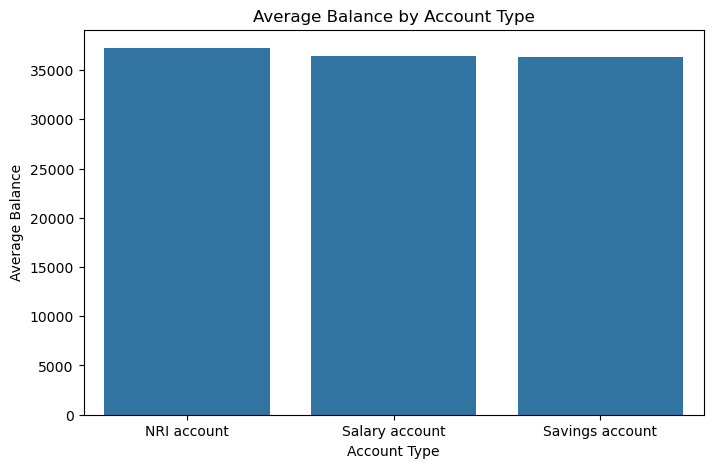

In [116]:
plt.figure(figsize=(8,5))
sns.barplot(data=account_type_perf, x='Account_type', y='Avg_Balance')
plt.title('Average Balance by Account Type')
plt.xlabel('Account Type')
plt.ylabel('Average Balance')
plt.show()

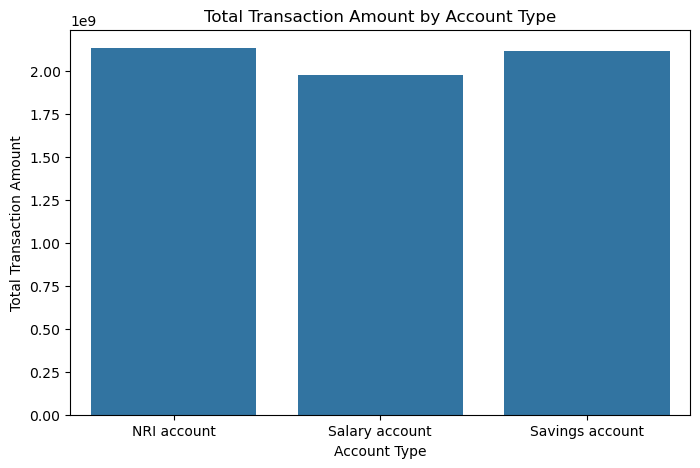

In [117]:
plt.figure(figsize=(8,5))
sns.barplot(data=account_type_perf, x='Account_type', y='Total_Transaction_Amount')
plt.title('Total Transaction Amount by Account Type')
plt.xlabel('Account Type')
plt.ylabel('Total Transaction Amount')
plt.show()

In [118]:
print("=== Account Type Performance Summary ===")
print(f"Total Accounts: {len(account_perf)}")
print(f"\nAccount Type Distribution:\n{account_perf['Account_type'].value_counts(normalize=True) * 100}")

=== Account Type Performance Summary ===
Total Accounts: 4500

Account Type Distribution:
Account_type
Savings account    34.066667
NRI account        33.822222
Salary account     32.111111
Name: proportion, dtype: float64


### Account Type Performance Analysis

### Key Findings

**Account Distribution**
Fairly balanced across all three types — NRI (33.8%), Savings (34.1%), and Salary (32.1%).

**Balance & Activity**
NRI accounts hold the highest average balance (₹37,236), while Salary accounts show marginally higher transaction frequency. Transaction volume and average amounts are broadly similar across all types.

**Loan Adoption**
Highest in Salary accounts (15.85%) and lowest in NRI accounts (14.26%), though the overall difference is minor.

**Overall**
The three account types show comparable performance with only marginal variation — differentiation lies in balance levels and loan behavior rather than transaction activity.

---

### Recommendations

| Segment | Opportunity | Action |
|---|---|---|
| Salary Accounts | Highest loan adoption | Pre-approved personal loans, salary-linked credit products |
| NRI Accounts | Highest average balance | Investment and wealth management product offerings |
| All Segments | Similar overall performance | Cross-selling and product bundling to increase penetration |

> Since performance is broadly similar across account types, focus should shift toward **product differentiation and targeted offerings** rather than segment-level fixes.

### 3.2 Card Type Performance Analysis

In [119]:
#Merge Card Data with Client & Account
# Merge card with disp to get client_id and account_id
card_analysis = card.merge(disp[['disp_id', 'client_id', 'account_id', 'type']], on='disp_id', how='left')

# Rename columns for clarity
card_analysis = card_analysis.rename(columns={'type_x': 'card_type', 'type_y': 'account_owner_type'})

# Merge with account to get Account_type
card_analysis = card_analysis.merge(account[['account_id', 'Account_type']], on='account_id', how='left')

print("=== Card Type Distribution ===")
print(card_analysis['card_type'].value_counts())

=== Card Type Distribution ===
card_type
classic    659
junior     145
gold        88
Name: count, dtype: int64


In [120]:
#Card Performance by Type (Balance & Transactions)
# Merge with transaction behavior
card_perf = card_analysis.merge(
    trans_behaviour.groupby('account_id').agg(
        Total_Transaction_Amount = ('amount', 'sum'),
        Transaction_Count = ('trans_id', 'count'),
        Avg_Balance = ('balance', 'mean')
    ).reset_index(),
    on='account_id',
    how='left'
)

# Performance by Card Type
card_type_perf = card_perf.groupby('card_type').agg(
    Number_of_Cards = ('card_id', 'count'),
    Avg_Balance = ('Avg_Balance', 'mean'),
    Avg_Transaction_Amount = ('Total_Transaction_Amount', 'mean'),
    Avg_Transaction_Count = ('Transaction_Count', 'mean')
).reset_index()

print("=== Performance by Card Type ===")
print(card_type_perf.round(2))

=== Performance by Card Type ===
  card_type  Number_of_Cards  Avg_Balance  Avg_Transaction_Amount  \
0   classic              659     51145.79              2083218.31   
1      gold               88     61301.59              2652949.85   
2    junior              145     47603.52              1904600.06   

   Avg_Transaction_Count  
0                 240.61  
1                 290.52  
2                 248.53  


In [121]:
#Loan Behavior by Card Type
# Merge with loan data
card_loan = card_perf.merge(
    analytical_loan.groupby('account_id').agg(
        Total_Loan_Amount = ('loan_amount', 'sum'),
        Has_Loan = ('loan_id', 'count')
    ).reset_index(),
    on='account_id',
    how='left'
)

card_loan['Has_Loan'] = card_loan['Has_Loan'].fillna(0)
card_loan['Total_Loan_Amount'] = card_loan['Total_Loan_Amount'].fillna(0)

# Loan metrics by Card Type
loan_by_card = card_loan.groupby('card_type').agg(
    Total_Cards = ('card_id', 'count'),
    Cards_with_Loan = ('Has_Loan', lambda x: (x > 0).sum()),
    Total_Loan_Amount = ('Total_Loan_Amount', 'sum'),
    Avg_Loan_Amount = ('Total_Loan_Amount', 'mean')
).reset_index()

loan_by_card['Loan_Adoption_Rate_%'] = (loan_by_card['Cards_with_Loan'] / loan_by_card['Total_Cards'] * 100).round(2)

print("=== Loan Behavior by Card Type ===")
print(loan_by_card.round(2))

=== Loan Behavior by Card Type ===
  card_type  Total_Cards  Cards_with_Loan  Total_Loan_Amount  Avg_Loan_Amount  \
0   classic          659              133         19791540.0         30032.69   
1      gold           88               16          2590092.0         29432.86   
2    junior          145               21          4661376.0         32147.42   

   Loan_Adoption_Rate_%  
0                 20.18  
1                 18.18  
2                 14.48  


In [122]:
loan_by_card

,card_type,Total_Cards,Cards_with_Loan,Total_Loan_Amount,Avg_Loan_Amount,Loan_Adoption_Rate_%
0,classic,659,133,19791540.0,30032.685888,20.18
1,gold,88,16,2590092.0,29432.863636,18.18
2,junior,145,21,4661376.0,32147.420690,14.48


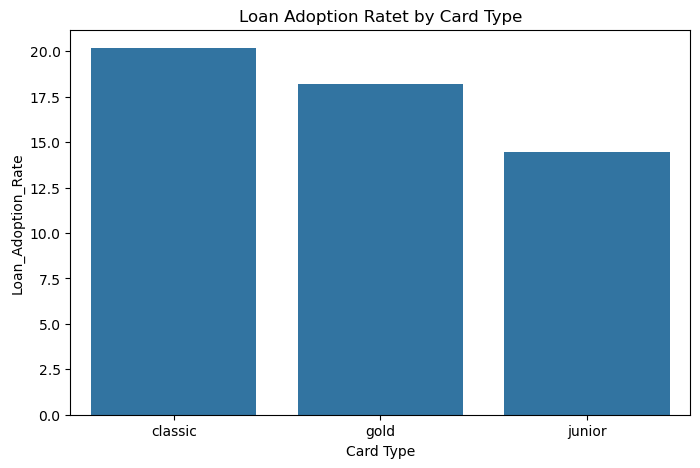

In [123]:
plt.figure(figsize=(8,5))
sns.barplot(data=loan_by_card, x='card_type', y='Loan_Adoption_Rate_%')
plt.title('Loan Adoption Ratet by Card Type')
plt.xlabel('Card Type')
plt.ylabel('Loan_Adoption_Rate')
plt.show()

In [124]:
#Card Type Distribution by Account Type
card_by_account = pd.crosstab(card_analysis['Account_type'], card_analysis['card_type'], normalize='index') * 100

print("=== Card Type Distribution by Account Type (%) ===")
card_by_account

=== Card Type Distribution by Account Type (%) ===


card_type,classic,gold,junior
Account_type,,,
NRI account,74.763407,9.463722,15.772871
Salary account,73.626374,10.989011,15.384615
Savings account,73.178808,9.271523,17.549669


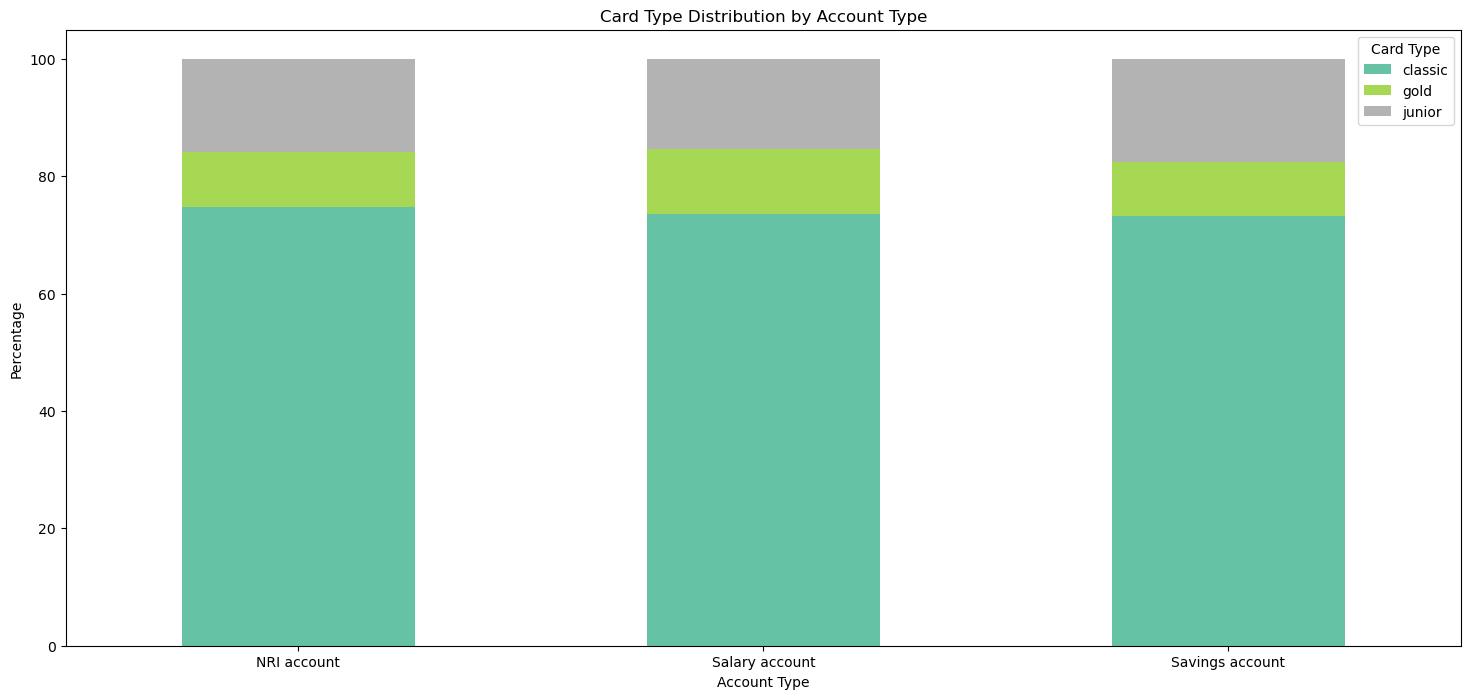

In [125]:
card_by_account.plot(kind='bar', stacked=True, figsize=(18,8), colormap='Set2')
plt.title('Card Type Distribution by Account Type')
plt.xlabel('Account Type')
plt.ylabel('Percentage')
plt.legend(title='Card Type')
plt.xticks(rotation=0)
plt.show()

In [126]:
print("=== Card Type Performance Summary ===")
print(f"Total Cards Issued: {len(card_analysis)}")
print(f"\nCard Type Distribution:\n{card_analysis['card_type'].value_counts(normalize=True) * 100}")

=== Card Type Performance Summary ===
Total Cards Issued: 892

Card Type Distribution:
card_type
classic    73.878924
junior     16.255605
gold        9.865471
Name: proportion, dtype: float64


### Card Type Performance Analysis

### Key Findings

**Card Distribution**
Classic cards dominate at 73.9%, followed by Junior (16.3%) and Gold (9.9%).

**Gold Card Performance**
Gold holders are the highest-value segment — highest average balance (₹61,302), highest transaction volume, and highest transaction frequency.

**Junior Cards**
Lowest balance and transaction activity, consistent with the segment's profile.

**Loan Adoption**
Highest among Classic card holders (20.2%) and lowest among Junior holders (14.5%).

**Cross-Segment Distribution**
Card type distribution is consistent across NRI, Salary, and Savings accounts — no significant variation by account type.

---

### Recommendations

| Segment | Opportunity | Action |
|---|---|---|
| Classic Cardholders | Largest base, high loan adoption | Upgrade campaigns to Gold; pre-approved loans and credit limit enhancements |
| Gold Cardholders | Highest value segment | Retention focus; premium and loyalty offerings |
| Junior Cardholders | Low activity, growth potential | Review for upgrades as customers mature financially |
| All Account Types | Uniform card distribution | Card upgrade campaigns applicable across all segments |

> Classic-to-Gold upgrade campaigns represent the highest-impact opportunity, given the significant performance gap between the two tiers.

-----------------

### 3.3 Overall Product Adoption & Combination Analysis

In [127]:
# Create Product Holding Flags

product_adoption = client[['client_id']].copy()

# Has Card?
card_clients = disp[disp['disp_id'].isin(card['disp_id'])]['client_id'].unique()
product_adoption['has_card'] = product_adoption['client_id'].isin(card_clients).astype(int)

# Has Loan?
loan_clients = analytical_loan['client_id'].unique()
product_adoption['has_loan'] = product_adoption['client_id'].isin(loan_clients).astype(int)

# Total Products (Account is always 1)
product_adoption['total_products'] = 1 + product_adoption['has_card'] + product_adoption['has_loan']

print("=== Number of Products Distribution ===")
print(product_adoption['total_products'].value_counts().sort_index())

=== Number of Products Distribution ===
total_products
1    3913
2    1234
3     170
Name: count, dtype: int64


In [128]:
#Product Combination Analysis
def get_product_combo(row):
    products = ['Account']
    if row['has_card'] == 1:
        products.append('Card')
    if row['has_loan'] == 1:
        products.append('Loan')
    return ' + '.join(products)

product_adoption['product_combo'] = product_adoption.apply(get_product_combo, axis=1)

print("=== Product Combination Distribution ===")
print(product_adoption['product_combo'].value_counts(normalize=True) * 100)

=== Product Combination Distribution ===
product_combo
Account                  73.594132
Account + Card           13.579086
Account + Loan            9.629490
Account + Card + Loan     3.197292
Name: proportion, dtype: float64


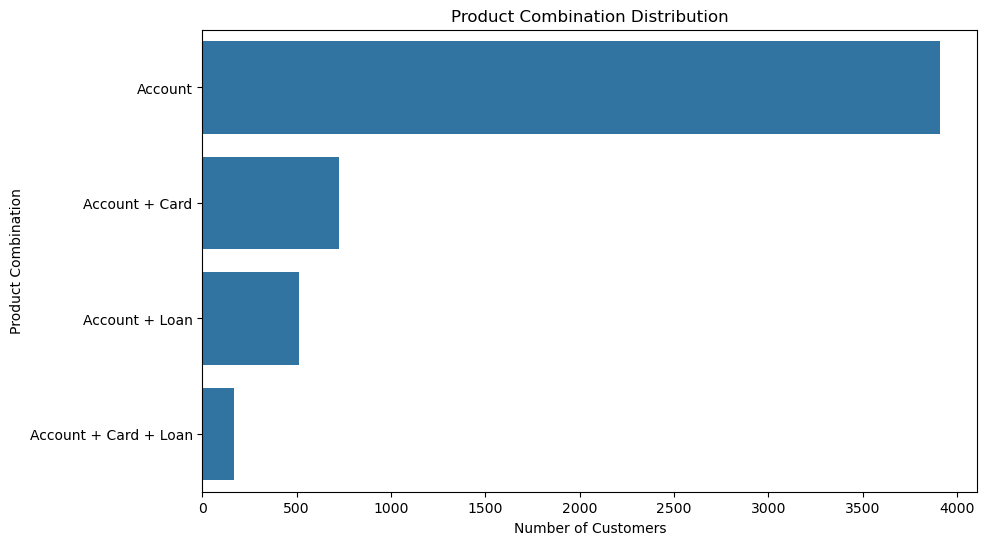

In [129]:
plt.figure(figsize=(10,6))
sns.countplot(data=product_adoption, y='product_combo', 
              order=product_adoption['product_combo'].value_counts().index)
plt.title('Product Combination Distribution')
plt.xlabel('Number of Customers')
plt.ylabel('Product Combination')
plt.show()

In [130]:
#Product Holding in High-Value Segment
high_value_product = product_adoption.merge(
    high_value_analysis[['client_id', 'is_high_value']], 
    on='client_id', 
    how='left'
)

print("=== Product Holding: High-Value vs Normal Customers ===")
print(pd.crosstab(
    high_value_product['is_high_value'], 
    high_value_product['total_products'], 
    normalize='index'
) * 100)

=== Product Holding: High-Value vs Normal Customers ===
total_products          1          2          3
is_high_value                                  
0               79.449583  19.061584   1.488834
1               44.230769  44.004525  11.764706


In [131]:
print("=== Product Adoption Summary ===")
print(f"Total Customers: {len(product_adoption)}")
print(f"\nProduct Distribution:\n{product_adoption['total_products'].value_counts(normalize=True).sort_index() * 100}")

=== Product Adoption Summary ===
Total Customers: 5317

Product Distribution:
total_products
1    73.594132
2    23.208576
3     3.197292
Name: proportion, dtype: float64


### Product Adoption & Combination Analysis

### Key Findings

**Low Product Penetration**
73.6% of customers hold only 1 product (Account only), and just 3.2% hold all 3 products — indicating a significant cross-selling gap.

**Common Multi-Product Combinations**
Account + Card is the most common multi-product holding (13.6%), followed by Account + Loan (9.6%).

**High-Value vs. Normal Customers**
High-Value customers show markedly better product adoption — 44% hold 2 products and 11.8% hold all 3, compared to only 19% and 1.5% respectively among normal customers.

---

### Recommendations

| Priority | Segment | Action |
|---|---|---|
| High | High-Value Customers | Lead cross-selling efforts — higher willingness and capacity to adopt |
| High | Single-Product Customers | Design upgrade paths to move from 1 → 2 products |
| Medium | Normal Segment | Promote bundled offerings (Account + Card, Account + Loan) |
| Medium | All Segments | Incentivise 3-product adoption with loyalty or fee benefits |

> The biggest opportunity lies in converting the **73.6% single-product base** — even a modest shift to 2-product holding would significantly improve revenue and customer stickiness.

### 3.4 Cross-Sell Conversion Rate Analysis

In [132]:
#Overall Cross-Sell Conversion Rates
total_customers = len(product_adoption)

# Account → Card Conversion
account_to_card = (product_adoption['has_card'].sum() / total_customers) * 100

# Account → Loan Conversion
account_to_loan = (product_adoption['has_loan'].sum() / total_customers) * 100

# Card → Loan Conversion (among customers who have a card)
card_holders = product_adoption[product_adoption['has_card'] == 1]
card_to_loan = (card_holders['has_loan'].sum() / len(card_holders)) * 100

print("=== Overall Cross-Sell Conversion Rates ===")
print(f"Account → Card Conversion Rate     : {account_to_card:.2f}%")
print(f"Account → Loan Conversion Rate     : {account_to_loan:.2f}%")
print(f"Card → Loan Conversion Rate        : {card_to_loan:.2f}%")

=== Overall Cross-Sell Conversion Rates ===
Account → Card Conversion Rate     : 16.78%
Account → Loan Conversion Rate     : 12.83%
Card → Loan Conversion Rate        : 19.06%


In [133]:
#Cross-Sell Conversion: High-Value vs Normal Customers
hv_conversion = high_value_product.groupby('is_high_value').agg(
    Total_Customers = ('client_id', 'count'),
    Has_Card = ('has_card', 'sum'),
    Has_Loan = ('has_loan', 'sum')
).reset_index()

hv_conversion['Account_to_Card_%'] = (hv_conversion['Has_Card'] / hv_conversion['Total_Customers'] * 100).round(2)
hv_conversion['Account_to_Loan_%'] = (hv_conversion['Has_Loan'] / hv_conversion['Total_Customers'] * 100).round(2)

print("=== Cross-Sell Conversion: High-Value vs Normal ===")
print(hv_conversion[['is_high_value', 'Total_Customers', 'Account_to_Card_%', 'Account_to_Loan_%']])

=== Cross-Sell Conversion: High-Value vs Normal ===
   is_high_value  Total_Customers  Account_to_Card_%  Account_to_Loan_%
0              0             4433              12.45               9.59
1              1              884              38.46              29.07


### Cross-Sell Conversion Rates

### Key Findings

**Overall Conversion (Low)**

| Cross-Sell Path | Conversion Rate |
|---|---|
| Account → Card | 16.8% |
| Account → Loan | 12.8% |
| Card → Loan | 19.1% |

**High-Value vs. Normal Customers**

| Metric | High-Value | Normal |
|---|---|---|
| Card Holding | 38.5% | 12.5% |
| Loan Holding | 29.1% | 9.6% |

High-Value customers convert at **3x the rate** of normal customers across both cards and loans.

---

### Recommendations

| Priority | Action |
|---|---|
| High | Target normal segment with Account → Card and Account → Loan campaigns |
| High | Offer pre-approved cards and loans to existing account holders |
| Medium | Use High-Value customer behaviour as a benchmark to design offers for the normal segment |
| Medium | Focus on Card → Loan conversion (19.1%) as the highest existing conversion path to build on |

> Cross-sell conversion among normal customers is critically low — structured, targeted campaigns here represent the **highest-volume growth opportunity** in the product portfolio.

---------------

### Product Enhancement Opportunities

### Key Gaps

| Area | Current Situation | Opportunity |
|---|---|---|
| Product Penetration | 73.6% hold only 1 product | Low multi-product adoption |
| Card Adoption | 16.8% Account → Card conversion | Significant room to grow |
| Loan Adoption | 12.8% Account → Loan conversion | Low across all segments |
| Gold Card Adoption | Only 9.9% of cards are Gold | Low premium card penetration |
| Normal Segment | Very low cross-sell conversion | Large untapped potential |
| Junior Cards | Lower engagement and loan adoption | Upgrade path opportunity |

---

### Recommendations

**A. Increase Product Penetration**
Launch cross-sell campaigns targeting the 1 → 2 product transition, focusing on Account → Card and Account → Loan. Introduce product bundles (e.g., Salary Account + Card + Personal Loan) with tangible benefits.

**B. Improve Card Performance**
Run Classic → Gold upgrade campaigns with incentives (higher limits, rewards, fee waivers). Build a clear upgrade journey for Junior cardholders as they mature financially.

**C. Strengthen Loan Cross-Selling**
Offer pre-approved loans to existing account holders — especially Salary segment customers. Prioritise the Card → Loan path as the highest existing conversion rate (19.1%).

**D. Segment-Specific Strategy**
- **High-Value:** Premium products — Gold cards, investment products, higher loan limits
- **Normal:** Simplified cross-sell — Account + Card / Account + Loan with easy onboarding
- **Low Engagement:** Reactivation campaigns with fee waivers or welcome offers

**E. Upgrade Paths**
```
Junior Card → Classic Card → Gold Card
Account Only → Account + Card → Account + Card + Loan
```

---

### Summary
The bank's biggest opportunity lies in improving cross-sell conversion and Gold card adoption. High-Value customers already exhibit strong multi-product behaviour — replicating this in the larger normal segment through targeted, simplified offers is the highest-impact strategic lever.

## 4.Loan Portfolio Analysis

### 4.1 Loan Portfolio Overview

In [134]:
print("=== Loan Portfolio Overview ===")
print(f"Total Number of Loans       : {len(analytical_loan)}")
print(f"Total Loan Amount Disbursed : {analytical_loan['loan_amount'].sum():,.2f}")
print(f"Average Loan Amount         : {analytical_loan['loan_amount'].mean():,.2f}")
print(f"Average Loan Duration       : {analytical_loan['loan_duration'].mean():.1f} months")
print(f"Average Monthly Payment     : {analytical_loan['monthly_payments'].mean():,.2f}")

=== Loan Portfolio Overview ===
Total Number of Loans       : 682
Total Loan Amount Disbursed : 103,261,740.00
Average Loan Amount         : 151,410.18
Average Loan Duration       : 36.5 months
Average Monthly Payment     : 4,190.66


In [135]:
print("\n=== Loan Status Distribution ===")
status_dist = analytical_loan['loan_status'].value_counts().reset_index()
status_dist.columns = ['Loan_Status', 'Count']
status_dist['Percentage'] = (status_dist['Count'] / status_dist['Count'].sum() * 100).round(2)

print(status_dist)

# Problematic Loans (B + D)
problematic = analytical_loan[analytical_loan['loan_status'].isin(['B', 'D'])]
print(f"\nProblematic Loans (B + D)   : {len(problematic)} ({len(problematic)/len(analytical_loan)*100:.2f}%)")


=== Loan Status Distribution ===
  Loan_Status  Count  Percentage
0           C    403       59.09
1           A    203       29.77
2           D     45        6.60
3           B     31        4.55

Problematic Loans (B + D)   : 76 (11.14%)


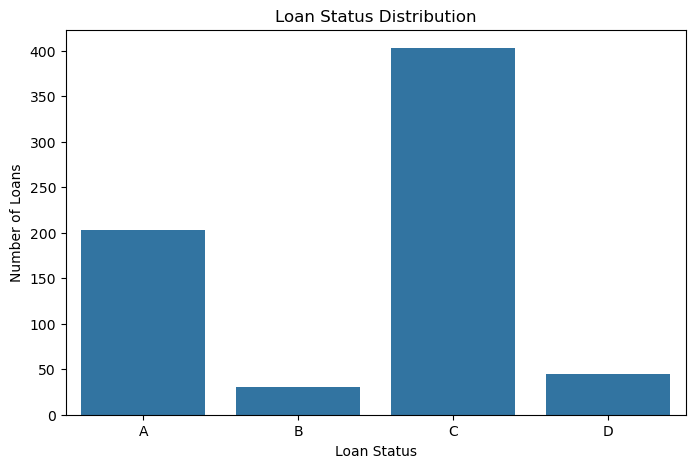

In [136]:
plt.figure(figsize=(8,5))
sns.countplot(data=analytical_loan, x='loan_status', order=['A', 'B', 'C', 'D'])
plt.title('Loan Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Number of Loans')
plt.show()

In [137]:
print("\n=== Loan Amount Summary ===")
print(analytical_loan['loan_amount'].describe().round(2))

# Create loan amount buckets
analytical_loan['loan_amount_bucket'] = pd.cut(
    analytical_loan['loan_amount'], 
    bins=[0, 50000, 150000, 300000, 1000000], 
    labels=['Very Small (<50k)', 'Small (50k-150k)', 'Medium (150k-300k)', 'Large (>300k)']
)

print("\n=== Loan Amount Bucket Distribution ===")
print(analytical_loan['loan_amount_bucket'].value_counts(normalize=True).sort_index() * 100)


=== Loan Amount Summary ===
count       682.00
mean     151410.18
std      113372.41
min        4980.00
25%       66732.00
50%      116928.00
75%      210654.00
max      590820.00
Name: loan_amount, dtype: float64

=== Loan Amount Bucket Distribution ===
loan_amount_bucket
Very Small (<50k)     18.475073
Small (50k-150k)      39.442815
Medium (150k-300k)    30.058651
Large (>300k)         12.023460
Name: proportion, dtype: float64


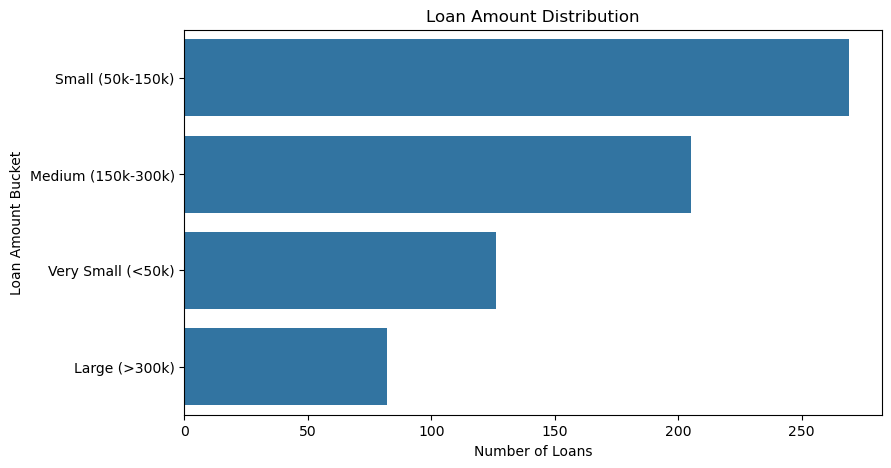

In [138]:
plt.figure(figsize=(9,5))
sns.countplot(data=analytical_loan, y='loan_amount_bucket', 
              order=analytical_loan['loan_amount_bucket'].value_counts().index)
plt.title('Loan Amount Distribution')
plt.xlabel('Number of Loans')
plt.ylabel('Loan Amount Bucket')
plt.show()

In [139]:
print("\n=== Loan Duration Summary ===")
print(analytical_loan['loan_duration'].value_counts().sort_index())

analytical_loan['duration_category'] = pd.cut(
    analytical_loan['loan_duration'], 
    bins=[0, 24, 48, 100], 
    labels=['Short (≤24 months)', 'Medium (25-48 months)', 'Long (>48 months)']
)

print("\n=== Loan Duration Category ===")
print(analytical_loan['duration_category'].value_counts(normalize=True) * 100)


=== Loan Duration Summary ===
loan_duration
12    131
24    138
36    130
48    138
60    145
Name: count, dtype: int64

=== Loan Duration Category ===
duration_category
Short (≤24 months)       39.442815
Medium (25-48 months)    39.296188
Long (>48 months)        21.260997
Name: proportion, dtype: float64


In [140]:
print("\n=== Loan Portfolio Summary ===")
print(f"Total Loans                     : {len(analytical_loan)}")
print(f"Total Amount Disbursed          : {analytical_loan['loan_amount'].sum():,.0f}")
print(f"Average Loan Amount             : {analytical_loan['loan_amount'].mean():,.0f}")
print(f"Problematic Loan Rate (B+D)     : {(analytical_loan['loan_status'].isin(['B','D']).mean()*100):.2f}%")
print(f"Average Loan Duration           : {analytical_loan['loan_duration'].mean():.1f} months")


=== Loan Portfolio Summary ===
Total Loans                     : 682
Total Amount Disbursed          : 103,261,740
Average Loan Amount             : 151,410
Problematic Loan Rate (B+D)     : 11.14%
Average Loan Duration           : 36.5 months


### Loan Portfolio Overview

### Key Findings

**Portfolio Size**
682 loans totalling ₹103.26 million disbursed, with an average loan amount of ₹151,410 and average duration of 36.5 months.

**Risk Level**
11.14% of loans are problematic (Status B + D) — a moderate risk level requiring active monitoring.

**Loan Size Distribution**
Small and Medium loans dominate at 69.5% combined. Long-term loans (>48 months) account for 21.3% of the portfolio.

---

### Recommendations

| Focus Area | Action |
|---|---|
| Risk Monitoring | Track problematic loan rate (11.14%) closely, especially for medium and large amounts |
| Long-Term Loans | Strengthen risk assessment for loans >48 months — higher default exposure |
| Credit Evaluation | Tighten underwriting criteria for loans above ₹150,000 |
| Duration Mix | Maintain balanced tenure distribution; reduce very long-term exposure if risk rises |

> With 1 in 9 loans classified as problematic, proactive monitoring and tighter credit evaluation — particularly for large, long-duration loans — should be an immediate priority.

### 4.2 High-Risk Loan Analysis (Status B & D)

In [141]:
# Create Risk Flag
analytical_loan['is_risky'] = analytical_loan['loan_status'].isin(['B', 'D']).astype(int)

print("=== Risky vs Good Loans ===")
print(analytical_loan['is_risky'].value_counts())
print(f"\nRisky Loan Percentage: {analytical_loan['is_risky'].mean()*100:.2f}%")

=== Risky vs Good Loans ===
is_risky
0    606
1     76
Name: count, dtype: int64

Risky Loan Percentage: 11.14%


In [142]:
risk_comparison = analytical_loan.groupby('is_risky').agg(
    Number_of_Loans = ('loan_id', 'count'),
    Avg_Loan_Amount = ('loan_amount', 'mean'),
    Median_Loan_Amount = ('loan_amount', 'median'),
    Avg_Duration = ('loan_duration', 'mean'),
    Avg_Monthly_Payment = ('monthly_payments', 'mean')
).reset_index()

risk_comparison['is_risky'] = risk_comparison['is_risky'].map({0: 'Good Loans (A+C)', 1: 'Risky Loans (B+D)'})

print("=== Risky vs Good Loans Comparison ===")
print(risk_comparison.round(2))

=== Risky vs Good Loans Comparison ===
            is_risky  Number_of_Loans  Avg_Loan_Amount  Median_Loan_Amount  \
0   Good Loans (A+C)              606        144689.09            110436.0   
1  Risky Loans (B+D)               76        205002.00            188460.0   

   Avg_Duration  Avg_Monthly_Payment  
0         36.34              4047.61  
1         37.74              5331.36  


In [143]:
risk_comparison

,is_risky,Number_of_Loans,Avg_Loan_Amount,Median_Loan_Amount,Avg_Duration,Avg_Monthly_Payment
0,Good Loans (A+C),606,144689.089109,110436.0,36.336634,4047.607261
1,Risky Loans (B+D),76,205002.000000,188460.0,37.736842,5331.355263


In [144]:
#Risk by Loan Duration
risk_by_duration = analytical_loan.groupby('duration_category',observed=False).agg(
    Total_Loans = ('loan_id', 'count'),
    Risky_Loans = ('is_risky', 'sum')
).reset_index()

risk_by_duration['Risk_Rate_%'] = (risk_by_duration['Risky_Loans'] / risk_by_duration['Total_Loans'] * 100).round(2)

print("=== Risk Rate by Loan Duration ===")
risk_by_duration

=== Risk Rate by Loan Duration ===


,duration_category,Total_Loans,Risky_Loans,Risk_Rate_%
0,Short (≤24 months),269,28,10.41
1,Medium (25-48 months),268,31,11.57
2,Long (>48 months),145,17,11.72


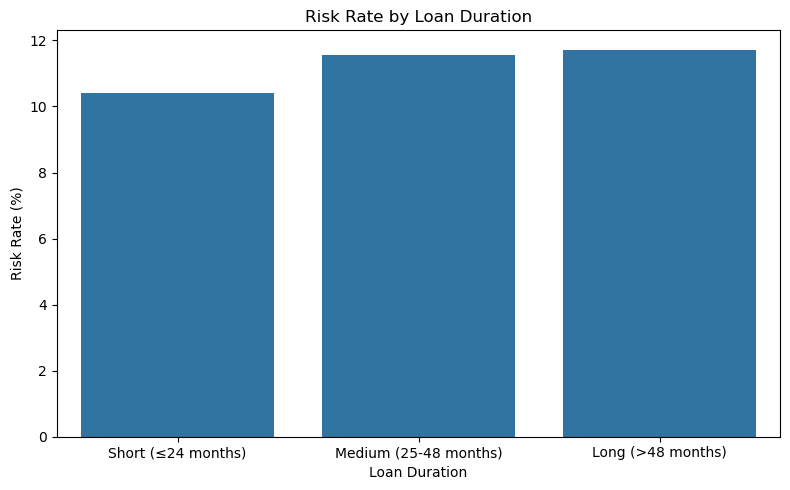

In [145]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=risk_by_duration,
    x='duration_category',
    y='Risk_Rate_%'
)

plt.title('Risk Rate by Loan Duration')
plt.xlabel('Loan Duration')
plt.ylabel('Risk Rate (%)')


plt.tight_layout()
plt.show()

In [146]:
#Risk by Loan Amount Bucket

risk_by_amount = analytical_loan.groupby('loan_amount_bucket',observed=False).agg(
    Total_Loans = ('loan_id', 'count'),
    Risky_Loans = ('is_risky', 'sum')
).reset_index()

risk_by_amount['Risk_Rate_%'] = (risk_by_amount['Risky_Loans'] / risk_by_amount['Total_Loans'] * 100).round(2)

print("=== Risk Rate by Loan Amount ===")
risk_by_amount.sort_values('Risk_Rate_%', ascending=False)

=== Risk Rate by Loan Amount ===


,loan_amount_bucket,Total_Loans,Risky_Loans,Risk_Rate_%
3,Large (>300k),82,17,20.73
2,Medium (150k-300k),205,28,13.66
1,Small (50k-150k),269,26,9.67
0,Very Small (<50k),126,5,3.97


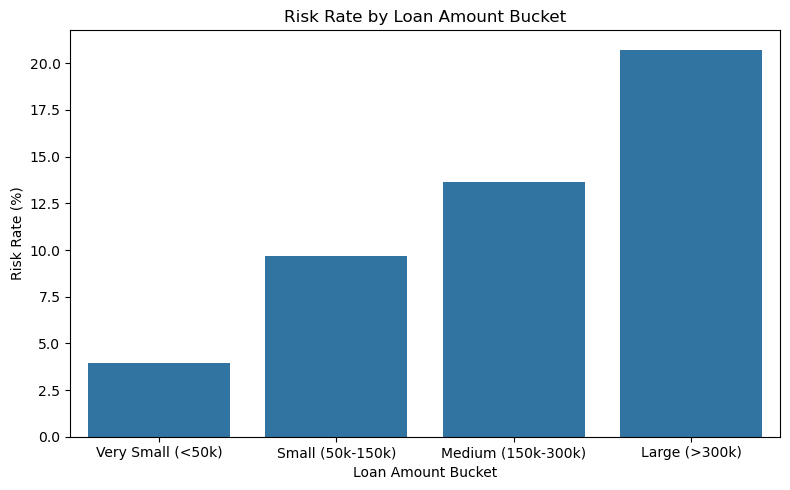

In [147]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=risk_by_amount.sort_values('Risk_Rate_%', ascending=False),
    x='loan_amount_bucket',
    y='Risk_Rate_%'
)

plt.title('Risk Rate by Loan Amount Bucket')
plt.xlabel('Loan Amount Bucket')
plt.ylabel('Risk Rate (%)')


plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [148]:
# Step 1: Get client_id for risky loans using disp
risky_account_client = analytical_loan[analytical_loan['is_risky'] == 1][['account_id']].merge(
    disp[['account_id', 'client_id']].drop_duplicates(), 
    on='account_id', 
    how='left'
)

# Step 2: Merge with client to get gender
risky_loans = risky_account_client.merge(
    client[['client_id', 'gender']], 
    on='client_id', 
    how='left'
)

# Step 3: Merge back with account type
risky_loans = risky_loans.merge(
    account[['account_id', 'Account_type']], 
    on='account_id', 
    how='left'
)

print("=== Risky Loans by Account Type ===")
print(risky_loans['Account_type'].value_counts(normalize=True) * 100)

print("\n=== Risky Loans by Gender ===")
print(risky_loans['gender'].value_counts(normalize=True) * 100)

=== Risky Loans by Account Type ===
Account_type
Salary account     48.684211
NRI account        28.947368
Savings account    22.368421
Name: proportion, dtype: float64

=== Risky Loans by Gender ===
gender
Female    53.947368
Male      46.052632
Name: proportion, dtype: float64


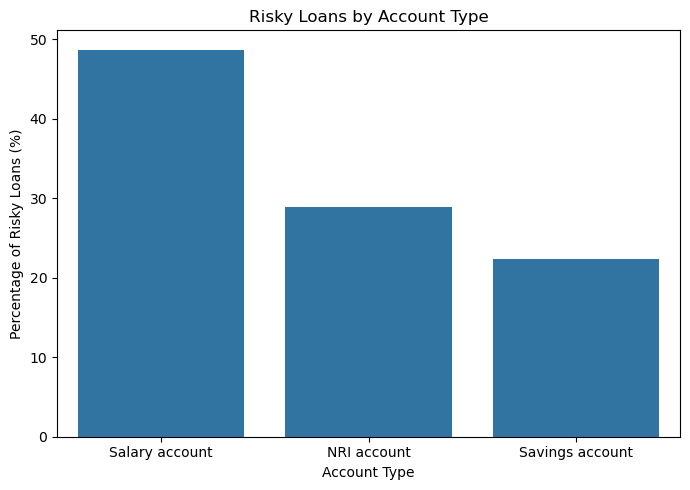

In [149]:
account_type_pct = (
    risky_loans['Account_type']
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)

account_type_pct.columns = ['Account Type', 'Percentage']

plt.figure(figsize=(7,5))

sns.barplot(
    data=account_type_pct,
    x='Account Type',
    y='Percentage'
)

plt.title('Risky Loans by Account Type')
plt.xlabel('Account Type')
plt.ylabel('Percentage of Risky Loans (%)')



plt.tight_layout()
plt.show()

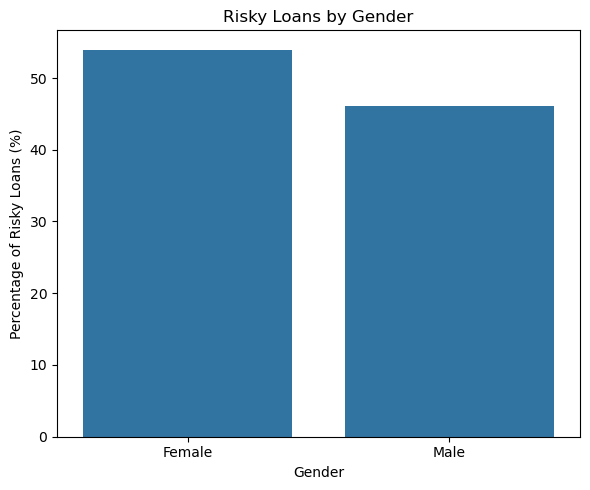

In [150]:
gender_pct = (
    risky_loans['gender']
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)

gender_pct.columns = ['Gender', 'Percentage']

plt.figure(figsize=(6,5))

sns.barplot(
    data=gender_pct,
    x='Gender',
    y='Percentage'
)

plt.title('Risky Loans by Gender')
plt.xlabel('Gender')
plt.ylabel('Percentage of Risky Loans (%)')



plt.tight_layout()
plt.show()

In [151]:
print("=== Key Risk Indicators ===")
print(f"Average Balance of Risky Loan Customers : {risky_loans.merge(trans_behaviour.groupby('account_id')['balance'].mean().reset_index(), on='account_id', how='left')['balance'].mean():.2f}")
print(f"Average Balance of Good Loan Customers  : {analytical_loan[analytical_loan['is_risky']==0].merge(trans_behaviour.groupby('account_id')['balance'].mean().reset_index(), on='account_id', how='left')['balance'].mean():.2f}")

=== Key Risk Indicators ===
Average Balance of Risky Loan Customers : 35767.99
Average Balance of Good Loan Customers  : 46087.56


### High-Risk Loan Analysis

### Key Findings

**Loan Amount & Risk**
Risky loans (Status B + D) carry a significantly higher average amount (₹205,002) vs. good loans (₹144,689). Large loans (>₹300K) show the highest problematic rate at 20.73%.

**Balance Profile**
Risky loan customers maintain lower average balances (₹35,768) compared to good loan customers (₹46,088) — indicating weaker financial cushion at time of default.

**Account Type**
Salary account holders account for the highest share of risky loans at 48.7%.

**Loan Duration**
Long-duration loans (>48 months) show a moderately higher risk rate compared to shorter tenures.

---

### Recommendations

| Risk Factor | Action |
|---|---|
| Large Loans (>₹300K) | Implement stricter credit evaluation — 20.73% problematic rate is high |
| Low-Balance Borrowers | Apply closer monitoring when approving medium to large loans |
| Salary Account Holders | Review lending practices — disproportionately high share of risky loans (48.7%) |
| Long-Duration Loans (>48 months) | Reduce exposure or apply higher scrutiny at approval stage |

> The combination of **high loan amount + low account balance** is the strongest signal of default risk — this should be a primary filter in the credit assessment process.

### 4.3 Loan Performance by Customer Segments

In [152]:
#1. Loan Performance by Account Type
loan_by_account = analytical_loan.merge(
    account[['account_id', 'Account_type']], 
    on='account_id', 
    how='left'
).groupby('Account_type').agg(
    Total_Loans = ('loan_id', 'count'),
    Avg_Loan_Amount = ('loan_amount', 'mean'),
    Risky_Loans = ('is_risky', 'sum'),
    Avg_Duration = ('loan_duration', 'mean')
).reset_index()

loan_by_account['Risk_Rate_%'] = (loan_by_account['Risky_Loans'] / loan_by_account['Total_Loans'] * 100).round(2)

print("=== Loan Performance by Account Type ===")
print(loan_by_account)

=== Loan Performance by Account Type ===
      Account_type  Total_Loans  Avg_Loan_Amount  Risky_Loans  Avg_Duration  \
0      NRI account          217    159113.861751           22     37.658986   
1   Salary account          229    152913.275109           37     36.262009   
2  Savings account          236    142868.186441           17     35.644068   

   Risk_Rate_%  
0        10.14  
1        16.16  
2         7.20  


In [153]:
#Loan Performance by Card Type
loan_by_card = analytical_loan.merge(
    card_analysis[['account_id', 'card_type']], 
    on='account_id', 
    how='left'
).groupby('card_type').agg(
    Total_Loans = ('loan_id', 'count'),
    Avg_Loan_Amount = ('loan_amount', 'mean'),
    Risky_Loans = ('is_risky', 'sum')
).reset_index()

loan_by_card['Risk_Rate_%'] = (loan_by_card['Risky_Loans'] / loan_by_card['Total_Loans'] * 100).round(2)

print("=== Loan Performance by Card Type ===")
print(loan_by_card)

=== Loan Performance by Card Type ===
  card_type  Total_Loans  Avg_Loan_Amount  Risky_Loans  Risk_Rate_%
0   classic          133    148808.571429            3         2.26
1      gold           16    161880.750000            1         6.25
2    junior           21    221970.285714            1         4.76


In [154]:
#3. Loan Performance: High-Value vs Normal Customers
loan_by_hv = analytical_loan.merge(
    high_value_analysis[['client_id', 'is_high_value']], 
    on='client_id', 
    how='left'
).groupby('is_high_value').agg(
    Total_Loans = ('loan_id', 'count'),
    Avg_Loan_Amount = ('loan_amount', 'mean'),
    Risky_Loans = ('is_risky', 'sum')
).reset_index()

loan_by_hv['is_high_value'] = loan_by_hv['is_high_value'].map({0: 'Normal', 1: 'High-Value'})
loan_by_hv['Risk_Rate_%'] = (loan_by_hv['Risky_Loans'] / loan_by_hv['Total_Loans'] * 100).round(2)

print("=== Loan Performance: High-Value vs Normal ===")
print(loan_by_hv)

=== Loan Performance: High-Value vs Normal ===
  is_high_value  Total_Loans  Avg_Loan_Amount  Risky_Loans  Risk_Rate_%
0        Normal          425    130804.545882           76        17.88
1    High-Value          257    185485.634241            0         0.00


In [155]:
# 4 Loan Risk by Gender
# Step 1: Get client_id from disp
loan_gender = analytical_loan[['loan_id', 'account_id', 'is_risky']].merge(
    disp[['account_id', 'client_id']].drop_duplicates(), 
    on='account_id', 
    how='left'
)

# Step 2: Merge with client to get gender
loan_gender = loan_gender.merge(
    client[['client_id', 'gender']], 
    on='client_id', 
    how='left'
)

# Step 3: Calculate risk by gender
loan_by_gender = loan_gender.groupby('gender').agg(
    Total_Loans = ('loan_id', 'count'),
    Risky_Loans = ('is_risky', 'sum')
).reset_index()

loan_by_gender['Risk_Rate_%'] = (loan_by_gender['Risky_Loans'] / loan_by_gender['Total_Loans'] * 100).round(2)

print("=== Loan Risk by Gender ===")
print(loan_by_gender)


=== Loan Risk by Gender ===
   gender  Total_Loans  Risky_Loans  Risk_Rate_%
0  Female          415           41         9.88
1    Male          407           35         8.60


### Loan Performance by Customer Segments

### Key Findings

**By Account Type**
Salary accounts carry the highest loan risk rate (16.16%), while Savings accounts show the lowest (7.20%).

**By Customer Value**
High-Value customers show 0% risky loans, compared to 17.88% among normal customers — a stark performance gap.

**By Gender**
Female customers show a marginally higher risk rate (9.88%) vs. Male (8.60%), though the difference is not statistically significant.

**Card-Linked Loans**
Insufficient data to draw clear conclusions on loan performance by card type.

---

### Recommendations

| Segment | Risk Rate | Action |
|---|---|---|
| Salary Accounts | 16.16% | Stricter credit assessment; review lending criteria |
| Normal Customers | 17.88% | Primary focus for risk monitoring and tighter controls |
| High-Value Customers | 0% | Offer preferential loan rates and higher limits |
| Savings Accounts | 7.20% | Maintain current approach — lowest risk segment |

> All problematic loans originate from the **normal customer segment** — targeted risk controls here will have the greatest impact on overall portfolio health.

### 4.4 Loan Growth + Risk Trend Analysis (Year-wise)

In [156]:
#1. Yearly Loan Disbursement & Risk Trend
# Extract year from loan date
analytical_loan['loan_year'] = pd.to_datetime(analytical_loan['loan_date']).dt.year

# Yearly loan summary with risk
loan_growth_risk = analytical_loan.groupby('loan_year').agg(
    Total_Loans = ('loan_id', 'count'),
    Total_Loan_Amount = ('loan_amount', 'sum'),
    Risky_Loans = ('is_risky', 'sum')
).reset_index()

loan_growth_risk['Risk_Rate_%'] = (loan_growth_risk['Risky_Loans'] / loan_growth_risk['Total_Loans'] * 100).round(2)
loan_growth_risk['YoY_Loan_Growth_%'] = loan_growth_risk['Total_Loan_Amount'].pct_change() * 100

print("=== Yearly Loan Growth & Risk Trend ===")
print(loan_growth_risk.round(2))

=== Yearly Loan Growth & Risk Trend ===
   loan_year  Total_Loans  Total_Loan_Amount  Risky_Loans  Risk_Rate_%  \
0       1993           20            2619276            4        20.00   
1       1994          101           13379904           14        13.86   
2       1995           90           13344372           12        13.33   
3       1996          117           18317676           16        13.68   
4       1997          196           30731364           26        13.27   
5       1998          158           24869148            4         2.53   

   YoY_Loan_Growth_%  
0                NaN  
1             410.82  
2              -0.27  
3              37.27  
4              67.77  
5             -19.08  


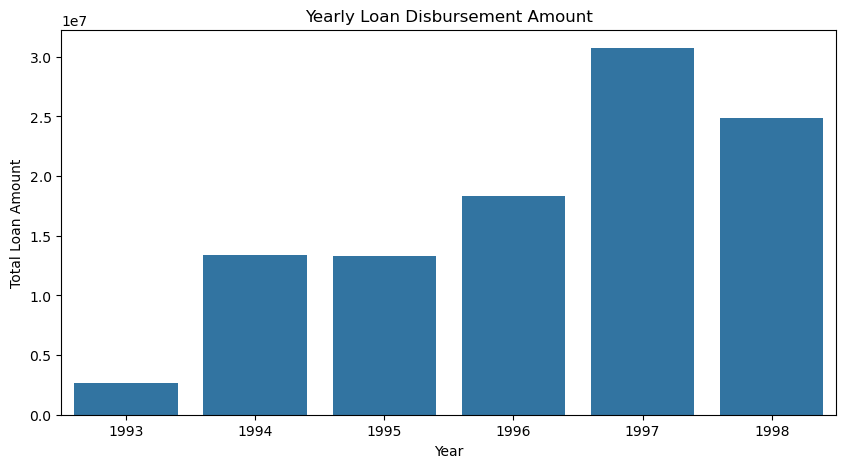

In [157]:
plt.figure(figsize=(10,5))
sns.barplot(data=loan_growth_risk, x='loan_year', y='Total_Loan_Amount')
plt.title('Yearly Loan Disbursement Amount')
plt.xlabel('Year')
plt.ylabel('Total Loan Amount')
plt.show()

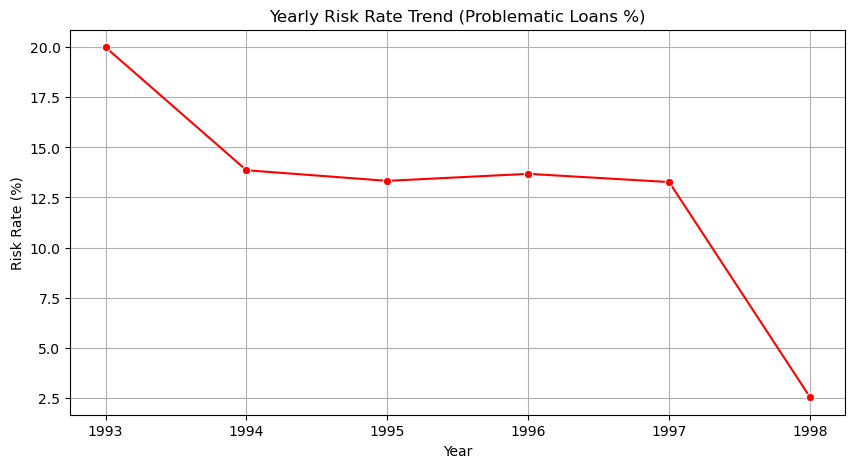

In [158]:
plt.figure(figsize=(10,5))
sns.lineplot(data=loan_growth_risk, x='loan_year', y='Risk_Rate_%', marker='o', color='red')
plt.title('Yearly Risk Rate Trend (Problematic Loans %)')
plt.xlabel('Year')
plt.ylabel('Risk Rate (%)')
plt.grid(True)
plt.show()

In [159]:
print("=== Loan Growth vs Risk Summary ===")
print(f"Highest Loan Disbursement Year : {loan_growth_risk.loc[loan_growth_risk['Total_Loan_Amount'].idxmax(), 'loan_year']}")
print(f"Highest Risk Year              : {loan_growth_risk.loc[loan_growth_risk['Risk_Rate_%'].idxmax(), 'loan_year']}")
print(f"Average Risk Rate (All Years)  : {loan_growth_risk['Risk_Rate_%'].mean():.2f}%")

=== Loan Growth vs Risk Summary ===
Highest Loan Disbursement Year : 1997
Highest Risk Year              : 1993
Average Risk Rate (All Years)  : 12.78%


### Loan Growth & Risk Trend

### Key Findings

**Growth Trajectory**
Loan disbursement grew steadily from 1993 to 1997, with 1997 being the peak year in both volume and total amount disbursed.

**Risk Rate Over Time**

| Period | Risk Rate | Note |
|---|---|---|
| 1993 | 20.0% | Small loan base — limited reliability |
| 1994–1997 | 13.3%–13.9% | Stable but elevated risk during growth phase |
| 1998 | 2.53% | Sharp improvement despite slower loan growth |
| Overall Average | 12.78% | Moderate risk across the full period |

**Key Observation**

The 1998 drop in risk rate is notable — despite a decline in loan growth, portfolio quality improved significantly, suggesting possible improvements in credit assessment or a shift in borrower profile.

---

### Recommendations

| Focus Area | Action |
|---|---|
| Investigate 1998 Improvement | Identify what drove the sharp risk reduction — replicate those practices |
| High-Growth Period Controls | Apply stricter credit evaluation during rapid disbursement phases (as in 1994 & 1997) |
| Sustained Monitoring | Continue tracking risk rate year-over-year to maintain the positive 1998 trend |
| Early Warning Indicators | Flag loans disbursed during high-growth years for closer monitoring — historically higher risk |

> The 1998 risk rate improvement is the most actionable insight — understanding and institutionalising what drove it could be the single biggest lever for long-term portfolio health.

### 4.5 Risk Drivers by Customer Balance

In [160]:
# Merge loan data with average balance
loan_balance = analytical_loan.merge(
    trans_behaviour.groupby('account_id',observed=False)['balance'].mean().reset_index(), 
    on='account_id', 
    how='left'
)

# Create balance buckets
loan_balance['balance_bucket'] = pd.qcut(
    loan_balance['balance'], 
    q=4, 
    labels=['Very Low Balance', 'Low Balance', 'Medium Balance', 'High Balance']
)

print("=== Risk Rate by Customer Balance Level ===")
balance_risk = loan_balance.groupby('balance_bucket',observed=False).agg(
    Total_Loans = ('loan_id', 'count'),
    Risky_Loans = ('is_risky', 'sum')
).reset_index()

balance_risk['Risk_Rate_%'] = (balance_risk['Risky_Loans'] / balance_risk['Total_Loans'] * 100).round(2)
print(balance_risk.sort_values('Risk_Rate_%', ascending=False))

=== Risk Rate by Customer Balance Level ===
     balance_bucket  Total_Loans  Risky_Loans  Risk_Rate_%
0  Very Low Balance          171           35        20.47
1       Low Balance          170           21        12.35
2    Medium Balance          170           17        10.00
3      High Balance          171            3         1.75


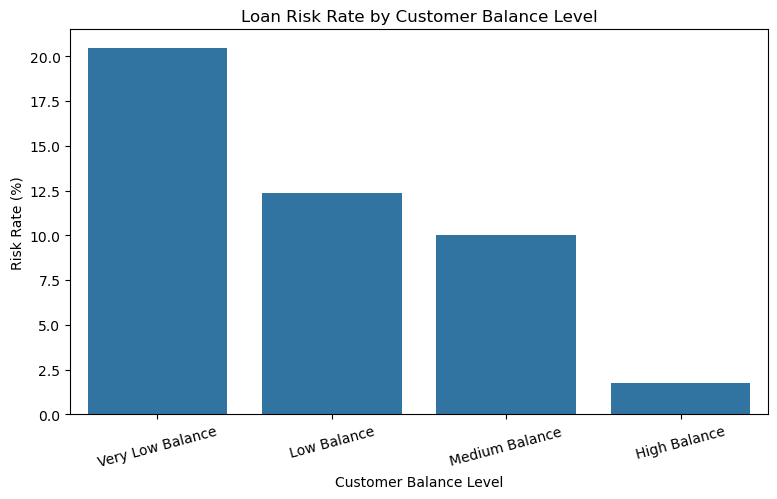

In [161]:
plt.figure(figsize=(9,5))
sns.barplot(data=balance_risk, x='balance_bucket', y='Risk_Rate_%')
plt.title('Loan Risk Rate by Customer Balance Level')
plt.xlabel('Customer Balance Level')
plt.ylabel('Risk Rate (%)')
plt.xticks(rotation=15)
plt.show()

### Credit Strategy Recommendations

### High-Risk Segments — Tighten Controls

| Segment | Risk Rate | Action |
|---|---|---|
| Large Loans (>₹300K) | 20.73% | Stricter evaluation, higher collateral, lower LTV ratios |
| Salary Account Holders | 16.16% | Enhanced income verification and debt-to-income checks |
| Long-Duration Loans (>48 months) | Elevated | Cap tenure or apply stricter affordability assessments |

### Low-Risk Segments — Expand Lending

| Segment | Risk Rate | Action |
|---|---|---|
| High-Value Customers | 0% | Preferential rates, higher limits, faster approvals |
| Savings Account Holders | 7.20% | Targeted loan campaigns with simplified documentation |

---

### Key Strategic Actions

**Use Account Balance as a Risk Indicator**
Include average balance (last 6–12 months) in the credit scoring model. Set minimum balance thresholds and apply higher scrutiny below a defined level.

**Monitor Risk During High-Growth Phases**
Rapid growth years (1994, 1997) correlated with elevated risk. Implement enhanced monitoring and periodic portfolio quality reviews during fast-expansion periods.

**Build an Early Warning System**
Develop a Loan Risk Dashboard tracking risk rate by loan amount, duration, and account type — with alerts for early delinquency signals such as declining borrower balances post-disbursement.

---

### Priority Action Matrix

| Recommendation | Impact | Priority |
|---|---|---|
| Stricter evaluation for large loans | Reduce high-value defaults | High |
| Preferential offers to High-Value customers | Increase quality lending | High |
| Include balance history in credit scoring | Better risk prediction | High |
| Cap or review long-duration loans | Lower long-term risk | Medium |
| Enhanced monitoring during growth phases | Early risk detection | Medium |

---

### Portfolio Health Summary

- Current problematic loan rate: **11.14%** (Moderate)
- 1998 risk rate: **2.53%** (Significant improvement)
- Biggest risk drivers: Large loans, Salary accounts, low-balance borrowers

> **Final Recommendation:** Adopt a risk-based, segment-specific lending strategy — tighten standards for high-risk segments while offering better terms to low-risk segments. This balanced approach supports responsible growth without compromising portfolio quality.

##   6.Regional Market Analysis

### 6.1 District-Level Banking Activity Overview

In [162]:
# Merge account with district
district_activity = account.merge(
    district[['district_id', 'district_name', 'region', 'population', 'avg_salary', 
              'unemployment_rate_1995', 'crimes_1995']], 
    on='district_id', 
    how='left'
)

print("=== District-Level Overview Sample ===")
print(district_activity.head())

=== District-Level Overview Sample ===
   account_id  district_id         frequency     Account_type date_joined  \
0        1573           63  POPLATEK MESICNE  Savings account  1997-12-29   
1        3276            1  POPLATEK MESICNE   Salary account  1997-12-29   
2         124           55  POPLATEK MESICNE   Salary account  1997-12-28   
3        3958           59  POPLATEK MESICNE      NRI account  1997-12-28   
4         777           30  POPLATEK MESICNE  Savings account  1997-12-28   

  Account_Owner_Type  district_name         region  population  avg_salary  \
0       Single Owner         Vyskov  south Moravia     86513.0      8288.0   
1      Joint Account    Hl.m. Praha         Prague   1204953.0     12541.0   
2       Single Owner  Brno - venkov  south Moravia    157042.0      8743.0   
3      Joint Account       Kromeriz  south Moravia    108871.0      8444.0   
4       Single Owner        Sokolov   west Bohemia     94812.0      9650.0   

   unemployment_rate_1995  cr

In [163]:
# Add transaction behavior
district_activity = district_activity.merge(
    trans_behaviour.groupby('account_id').agg(
        Total_Transaction_Amount = ('amount', 'sum'),
        Avg_Balance = ('balance', 'mean'),
        Transaction_Count = ('trans_id', 'count')
    ).reset_index(),
    on='account_id',
    how='left'
)

In [164]:
# Add loan metrics
district_loan = analytical_loan.groupby('account_id').agg(
    Total_Loan_Amount = ('loan_amount', 'sum'),
    Number_of_Loans = ('loan_id', 'count'),
    Risky_Loans = ('is_risky', 'sum')
).reset_index()

district_activity = district_activity.merge(district_loan, on='account_id', how='left')

# Fill missing values
district_activity['Total_Loan_Amount'] = district_activity['Total_Loan_Amount'].fillna(0)
district_activity['Number_of_Loans'] = district_activity['Number_of_Loans'].fillna(0)
district_activity['Risky_Loans'] = district_activity['Risky_Loans'].fillna(0)

In [165]:
# Step 1: Get client_id using disp
account_with_client = account.merge(
    disp[['account_id', 'client_id']].drop_duplicates(), 
    on='account_id', 
    how='left'
)

# Step 2: Merge with district
district_activity = account_with_client.merge(
    district[['district_id', 'district_name', 'region', 'population', 'avg_salary']], 
    on='district_id', 
    how='left'
)

# Step 3: Add transaction metrics
district_activity = district_activity.merge(
    trans_behaviour.groupby('account_id').agg(
        Total_Transaction_Amount = ('amount', 'sum'),
        Avg_Balance = ('balance', 'mean'),
        Transaction_Count = ('trans_id', 'count')
    ).reset_index(),
    on='account_id',
    how='left'
)

# Step 4: Add loan metrics
district_loan = analytical_loan.groupby('account_id').agg(
    Total_Loan_Amount = ('loan_amount', 'sum'),
    Number_of_Loans = ('loan_id', 'count'),
    Risky_Loans = ('is_risky', 'sum')
).reset_index()

district_activity = district_activity.merge(district_loan, on='account_id', how='left')

# Fill missing values
district_activity[['Total_Transaction_Amount', 'Avg_Balance', 'Total_Loan_Amount', 
                   'Number_of_Loans', 'Risky_Loans']] = district_activity[[
    'Total_Transaction_Amount', 'Avg_Balance', 'Total_Loan_Amount', 
    'Number_of_Loans', 'Risky_Loans']].fillna(0)

In [166]:
# Aggregate at District Level
district_summary = district_activity.groupby(['district_id', 'district_name', 'region']).agg(
    Total_Customers = ('client_id', 'count'),
    Total_Transaction_Amount = ('Total_Transaction_Amount', 'sum'),
    Avg_Balance = ('Avg_Balance', 'mean'),
    Total_Loan_Amount = ('Total_Loan_Amount', 'sum'),
    Number_of_Loans = ('Number_of_Loans', 'sum'),
    Risky_Loans = ('Risky_Loans', 'sum')
).reset_index()

# Calculate Risk Rate
district_summary['Loan_Risk_Rate_%'] = (district_summary['Risky_Loans'] / district_summary['Number_of_Loans'] * 100).round(2)

print("=== District-Level Summary (Top 10 by Transaction Volume) ===")
print(district_summary.sort_values('Total_Transaction_Amount', ascending=False).head(10))

=== District-Level Summary (Top 10 by Transaction Volume) ===
    district_id    district_name           region  Total_Customers  \
0             1      Hl.m. Praha           Prague              671   
72           74  Ostrava - mesto    north Moravia              164   
68           70          Karvina    north Moravia              177   
63           64             Zlin    south Moravia              111   
53           54     Brno - mesto    south Moravia              152   
67           68  Frydek - Mistek    north Moravia               97   
70           72          Olomouc    north Moravia              108   
51           52  Usti nad Orlici     east Bohemia               68   
4             5            Kolin  central Bohemia               76   
37           38            Louny    north Bohemia               66   

    Total_Transaction_Amount   Avg_Balance  Total_Loan_Amount  \
0                954691853.0  37220.148230         16806852.0   
72               249990459.0  37052.5

In [167]:
print("=== District-Level Summary (Top 10 byLoan Risk rate) ===")
district_summary.sort_values('Loan_Risk_Rate_%', ascending=False).head(10)

=== District-Level Summary (Top 10 byLoan Risk rate) ===


,district_id,district_name,region,Total_Customers,Total_Transaction_Amount,Avg_Balance,Total_Loan_Amount,Number_of_Loans,Risky_Loans,Loan_Risk_Rate_%
66,67,Bruntal,north Moravia,49,65642370.0,37662.851691,1277796.0,6.0,3.0,50.00
29,30,Sokolov,west Bohemia,44,44047161.0,33640.146049,148524.0,2.0,1.0,50.00
21,22,Domazlice,west Bohemia,48,57129200.0,33527.329803,397008.0,2.0,1.0,50.00
19,20,Strakonice,south Bohemia,43,61677576.0,35886.154512,1224492.0,6.0,3.0,50.00
71,73,Opava,north Moravia,65,81907574.0,34887.735722,1867836.0,9.0,3.0,33.33
5,6,Kutna Hora,central Bohemia,55,82115053.0,37515.114824,2160204.0,10.0,3.0,30.00
2,3,Beroun,central Bohemia,57,63072500.0,33599.868588,1480044.0,7.0,2.0,28.57
24,25,Klatovy,west Bohemia,49,51067811.0,33720.858590,289596.0,4.0,1.0,25.00
20,21,Tabor,south Bohemia,57,75430801.0,33763.861620,1081776.0,8.0,2.0,25.00
43,44,Chrudim,east Bohemia,54,74996786.0,33660.960905,1431684.0,8.0,2.0,25.00


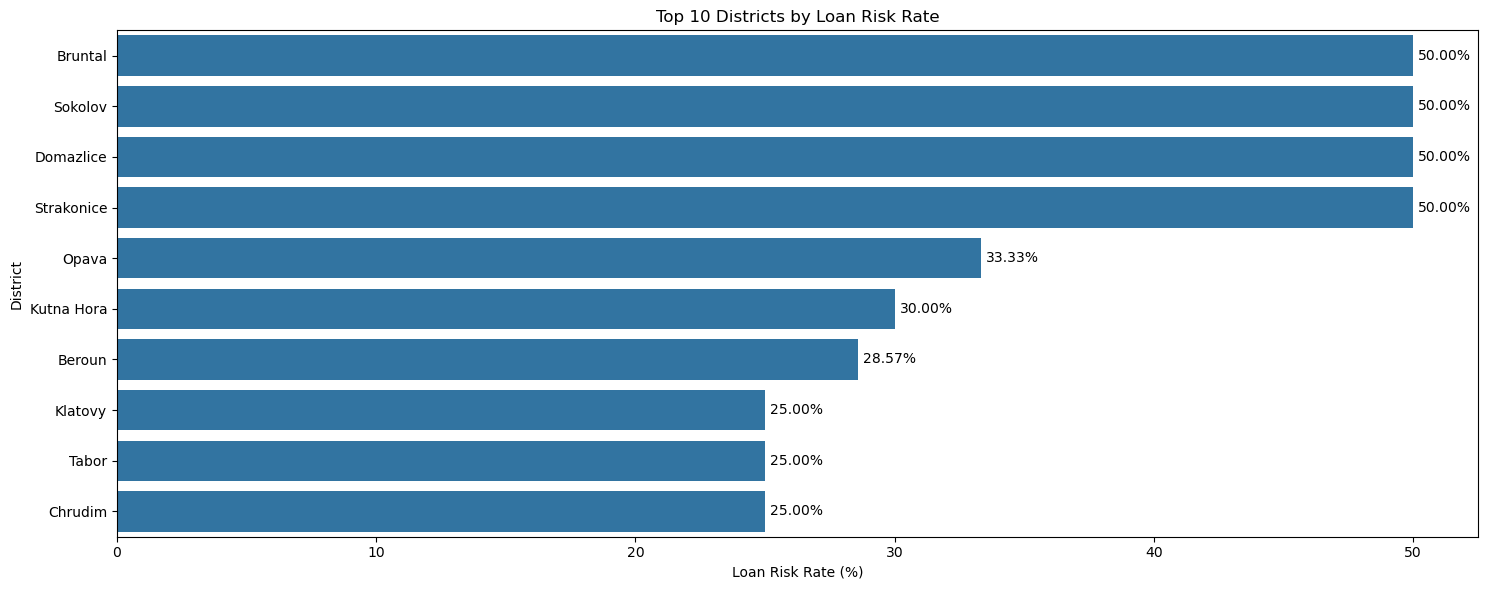

In [168]:
# Top 10 districts by Loan Risk Rate
top10_risk = district_summary.sort_values(
    'Loan_Risk_Rate_%',
    ascending=False
).head(10)

plt.figure(figsize=(15,6))

sns.barplot(
    data=top10_risk,
    y='district_name',
    x='Loan_Risk_Rate_%'
)

plt.title('Top 10 Districts by Loan Risk Rate')
plt.xlabel('Loan Risk Rate (%)')
plt.ylabel('District')

# Add percentage labels
for i, v in enumerate(top10_risk['Loan_Risk_Rate_%']):
    plt.text(v + 0.2, i, f'{v:.2f}%', va='center')

plt.tight_layout()
plt.show()

In [169]:
top10_risk = district_summary.sort_values(
    'Loan_Risk_Rate_%',
    ascending=True
).head(5)
top10_risk[['district_name','Number_of_Loans','Risky_Loans','Loan_Risk_Rate_%']]


,district_name,Number_of_Loans,Risky_Loans,Loan_Risk_Rate_%
1,Benesov,7.0,0.0,0.0
4,Kolin,11.0,0.0,0.0
6,Melnik,7.0,0.0,0.0
8,Nymburk,12.0,0.0,0.0
9,Praha - vychod,6.0,0.0,0.0


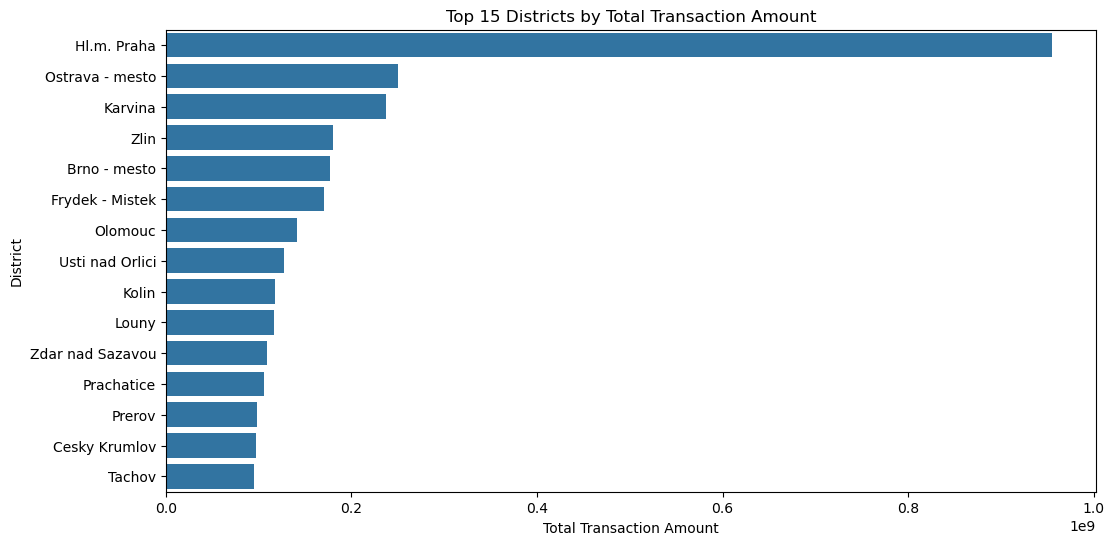

In [170]:
plt.figure(figsize=(12,6))
top_districts = district_summary.nlargest(15, 'Total_Transaction_Amount')
sns.barplot(data=top_districts, x='Total_Transaction_Amount', y='district_name')
plt.title('Top 15 Districts by Total Transaction Amount')
plt.xlabel('Total Transaction Amount')
plt.ylabel('District')
plt.show()

In [171]:
print("=== District Performance Summary ===")
print(f"Total Districts Analyzed : {len(district_summary)}")
print(f"Average Customers per District : {district_summary['Total_Customers'].mean():.0f}")
print(f"Average Loan Risk Rate : {district_summary['Loan_Risk_Rate_%'].mean():.2f}%")

=== District Performance Summary ===
Total Districts Analyzed : 76
Average Customers per District : 70
Average Loan Risk Rate : 10.25%


### District-Level Overview

### Key Findings

**Geographic Concentration**
Prague (Hl.m. Praha) dominates with 671 customers and significantly higher transaction volume than any other district. Activity is otherwise concentrated in North and South Moravia — Ostrava, Karvina, Brno, and Zlín.

**Risk Distribution**
Average loan risk rate across districts is 10.41%, but performance varies widely — from 0% risk in districts like Kolín and Louny to 17.24% in Brno-město.

**Uneven Performance**
A small number of districts drive the majority of banking activity, with most districts contributing marginally to overall volume.

---

### Recommendations

| Focus Area | District(s) | Action |
|---|---|---|
| Growth Expansion | Moravia region | Target high-potential districts outside Prague with marketing and product campaigns |
| Risk Investigation | Brno-město (17.24%) | Identify default drivers; tighten local credit assessment |
| Best Practice Replication | Kolín, Louny (0% risk) | Study and replicate successful credit and engagement practices |
| Regional Product Strategy | All districts | Tailor offerings to local customer needs and risk profiles |

> District performance is highly polarised — a **Prague-first, Moravia-next** growth strategy, combined with targeted risk controls in high-default districts, offers the clearest path to balanced regional expansion.

### 6.2 Identify High-Growth vs Low-Performance Districts

In [172]:
# Rank districts
district_ranking = district_summary.copy()

district_ranking['Rank_by_Transaction'] = district_ranking['Total_Transaction_Amount'].rank(ascending=False)
district_ranking['Rank_by_Balance'] = district_ranking['Avg_Balance'].rank(ascending=False)
district_ranking['Rank_by_Loan'] = district_ranking['Total_Loan_Amount'].rank(ascending=False)

print("=== Top 10 Districts by Transaction Volume ===")
print(district_ranking.nsmallest(10, 'Rank_by_Transaction')[['district_name', 'region', 'Total_Transaction_Amount', 'Avg_Balance', 'Loan_Risk_Rate_%']])

=== Top 10 Districts by Transaction Volume ===
      district_name           region  Total_Transaction_Amount   Avg_Balance  \
0       Hl.m. Praha           Prague               954691853.0  37220.148230   
72  Ostrava - mesto    north Moravia               249990459.0  37052.567266   
68          Karvina    north Moravia               237719858.0  36313.874916   
63             Zlin    south Moravia               180282559.0  36576.031829   
53     Brno - mesto    south Moravia               176619329.0  35504.218999   
67  Frydek - Mistek    north Moravia               170640284.0  38709.005778   
70          Olomouc    north Moravia               141461765.0  34688.387667   
51  Usti nad Orlici     east Bohemia               127202616.0  43592.871857   
4             Kolin  central Bohemia               117920168.0  38738.163497   
37            Louny    north Bohemia               116670827.0  40706.679638   

    Loan_Risk_Rate_%  
0               6.73  
72             12.00  
68 

In [173]:
# Create performance categories using quantiles
district_ranking['Performance_Category'] = pd.qcut(
    district_ranking['Total_Transaction_Amount'], 
    q=3, 
    labels=['Low Performance', 'Medium Performance', 'High Performance']
)

print("\n=== District Performance Categories ===")
print(district_ranking['Performance_Category'].value_counts())


=== District Performance Categories ===
Performance_Category
Low Performance       26
Medium Performance    25
High Performance      25
Name: count, dtype: int64


In [174]:
high_perf_low_risk = district_ranking[
    (district_ranking['Performance_Category'] == 'High Performance') & 
    (district_ranking['Loan_Risk_Rate_%'] < 10)
]

print("\n=== High Performance + Low Risk Districts ===")
high_perf_low_risk[['district_name', 'region', 'Total_Transaction_Amount', 'Loan_Risk_Rate_%']].head(5)


=== High Performance + Low Risk Districts ===


,district_name,region,Total_Transaction_Amount,Loan_Risk_Rate_%
0,Hl.m. Praha,Prague,954691853.0,6.73
4,Kolin,central Bohemia,117920168.0,0.00
8,Nymburk,central Bohemia,83635209.0,0.00
9,Praha - vychod,central Bohemia,89328162.0,0.00
10,Praha - zapad,central Bohemia,90290687.0,7.69


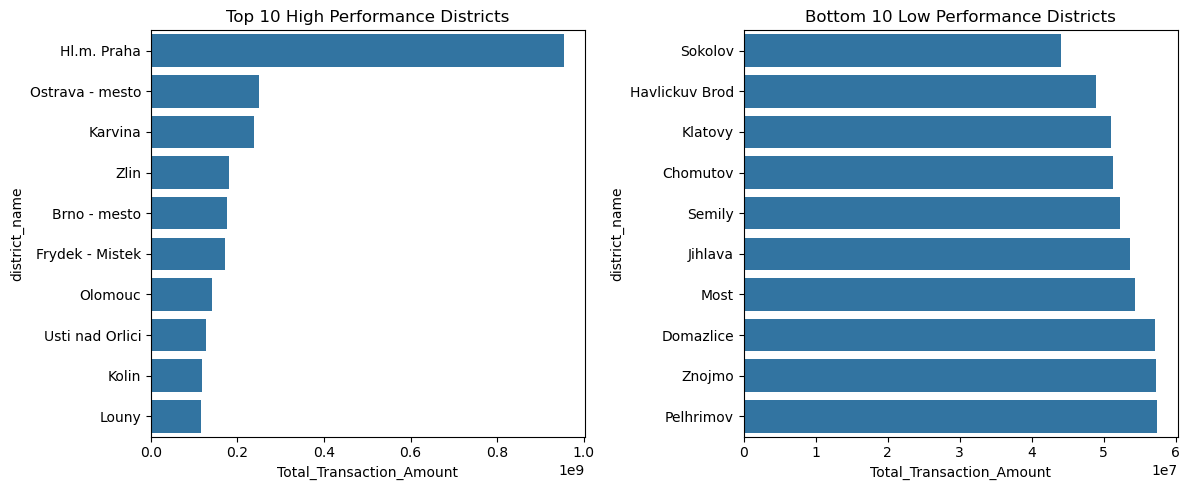

In [175]:
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
top10 = district_ranking.nsmallest(10, 'Rank_by_Transaction')
sns.barplot(data=top10, x='Total_Transaction_Amount', y='district_name')
plt.title('Top 10 High Performance Districts')

plt.subplot(1, 2, 2)
bottom10 = district_ranking.nlargest(10, 'Rank_by_Transaction')
sns.barplot(data=bottom10, x='Total_Transaction_Amount', y='district_name')
plt.title('Bottom 10 Low Performance Districts')

plt.tight_layout()
plt.show()

### 6.3 Correlation with Economic Indicators

In [176]:
# Merge with full district data for economic indicators
district_economic = district_summary.merge(
    district[['district_id', 'population', 'avg_salary', 'unemployment_rate_1995', 
              'crimes_1995']], 
    on='district_id', 
    how='left'
)

print("=== District Economic + Banking Data Sample ===")
print(district_economic[['district_name', 'Total_Transaction_Amount', 'avg_salary', 
                         'unemployment_rate_1995', 'Loan_Risk_Rate_%']].head())

=== District Economic + Banking Data Sample ===
  district_name  Total_Transaction_Amount  avg_salary  unemployment_rate_1995  \
0   Hl.m. Praha               954691853.0       12541                    0.29   
1       Benesov                68018601.0        8507                    1.67   
2        Beroun                63072500.0        8980                    1.95   
3        Kladno                70490383.0        9753                    4.64   
4         Kolin               117920168.0        9307                    3.85   

   Loan_Risk_Rate_%  
0              6.73  
1              0.00  
2             28.57  
3             14.29  
4              0.00  


In [177]:
# Select relevant columns for correlation
corr_columns = ['Total_Transaction_Amount', 'Avg_Balance', 'Total_Loan_Amount', 
                'Loan_Risk_Rate_%', 'Total_Customers', 'population', 
                'avg_salary', 'unemployment_rate_1995', 'crimes_1995']

correlation_matrix = district_economic[corr_columns].corr()

print("=== Correlation Matrix ===")
print(correlation_matrix.round(2))

=== Correlation Matrix ===
                          Total_Transaction_Amount  Avg_Balance  \
Total_Transaction_Amount                      1.00         0.15   
Avg_Balance                                   0.15         1.00   
Total_Loan_Amount                             0.95         0.18   
Loan_Risk_Rate_%                             -0.07        -0.25   
Total_Customers                               0.99         0.07   
population                                    0.95         0.03   
avg_salary                                    0.59        -0.05   
unemployment_rate_1995                       -0.13         0.11   
crimes_1995                                   0.96         0.03   

                          Total_Loan_Amount  Loan_Risk_Rate_%  \
Total_Transaction_Amount               0.95             -0.07   
Avg_Balance                            0.18             -0.25   
Total_Loan_Amount                      1.00             -0.05   
Loan_Risk_Rate_%                      -0.0

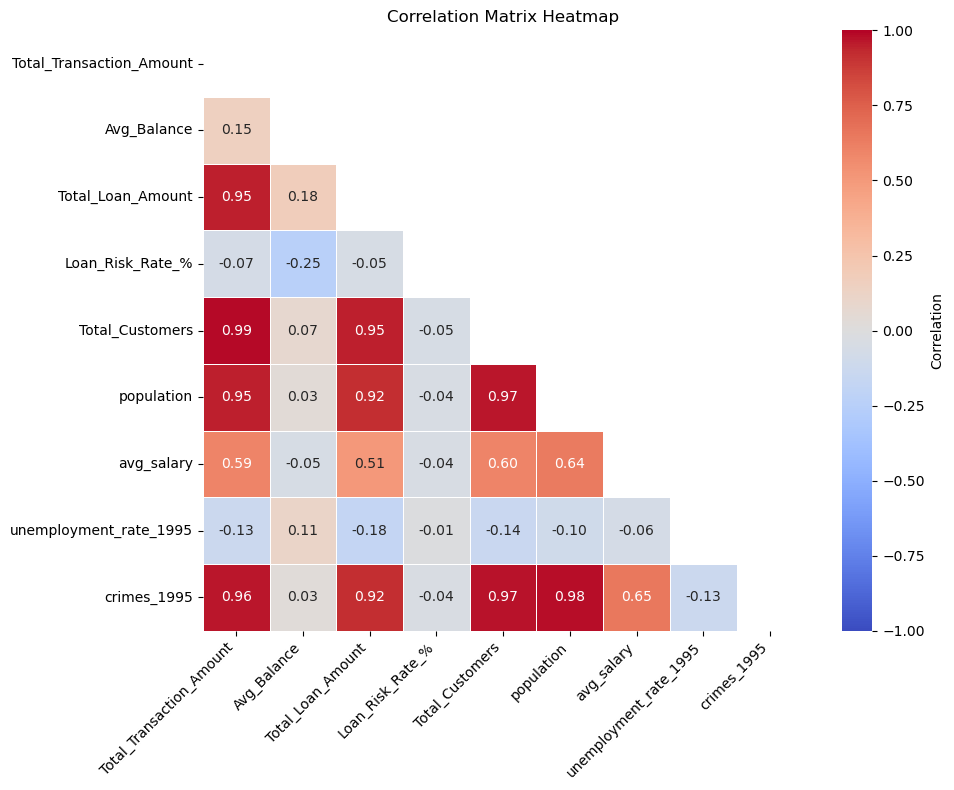

In [178]:
import numpy as np
plt.figure(figsize=(10,8))

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(
    correlation_matrix,
    mask=mask,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Correlation"}
)

plt.title("Correlation Matrix Heatmap")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [180]:
print("\n=== Key Correlations with Banking Metrics ===")
print("Avg Salary vs Transaction Amount :", 
      round(district_economic['avg_salary'].corr(district_economic['Total_Transaction_Amount']), 3))
print("Avg Salary vs Avg Balance        :", 
      round(district_economic['avg_salary'].corr(district_economic['Avg_Balance']), 3))
print("Unemployment vs Loan Risk Rate   :", 
      round(district_economic['unemployment_rate_1995'].corr(district_economic['Loan_Risk_Rate_%']), 3))
print("Population vs Total Customers    :", 
      round(district_economic['population'].corr(district_economic['Total_Customers']), 3))


=== Key Correlations with Banking Metrics ===
Avg Salary vs Transaction Amount : 0.594
Avg Salary vs Avg Balance        : -0.053
Unemployment vs Loan Risk Rate   : -0.011
Population vs Total Customers    : 0.965


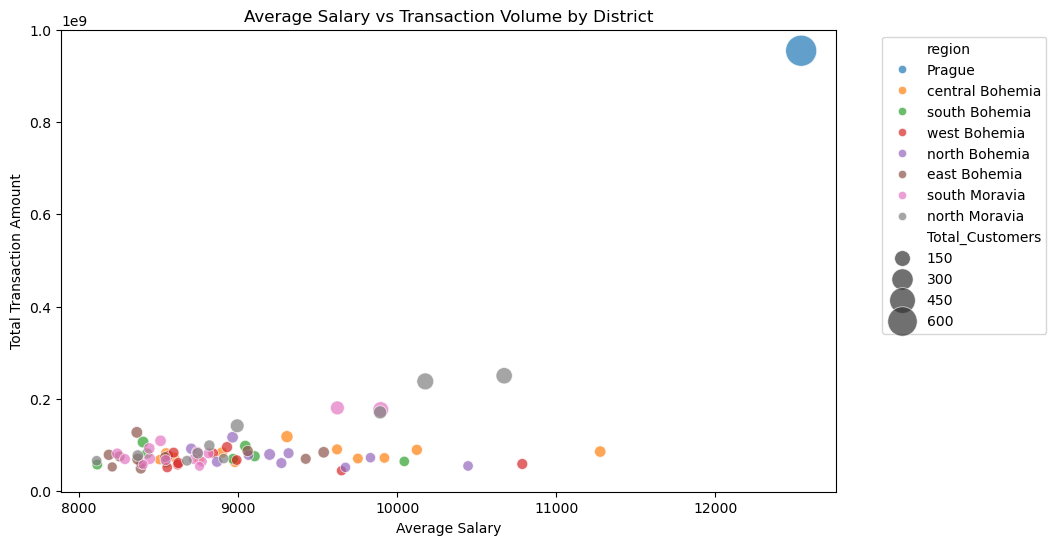

In [181]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=district_economic, x='avg_salary', y='Total_Transaction_Amount', 
                hue='region', size='Total_Customers', sizes=(50, 500), alpha=0.7)
plt.title('Average Salary vs Transaction Volume by District')
plt.xlabel('Average Salary')
plt.ylabel('Total Transaction Amount')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

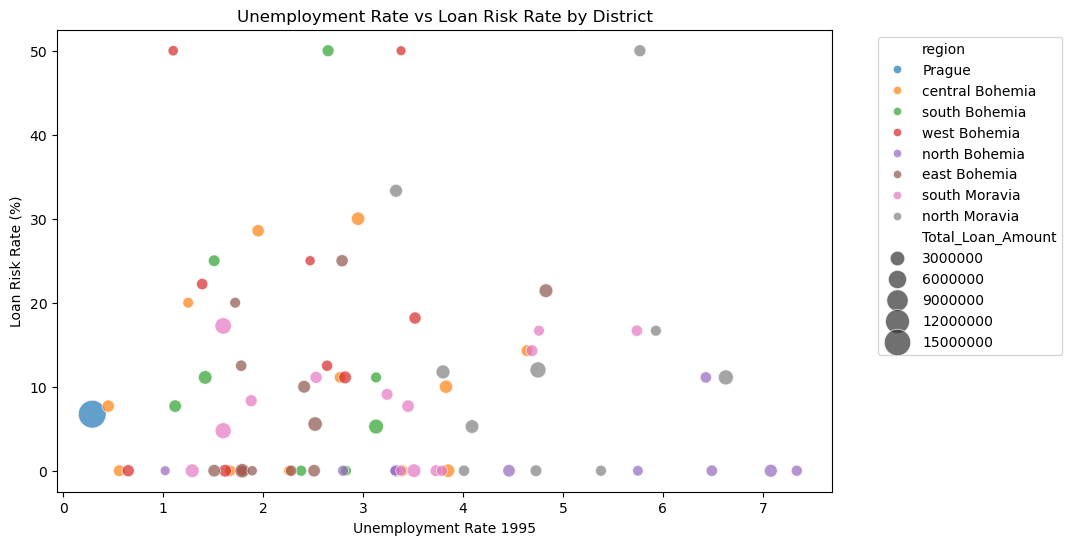

In [182]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=district_economic, x='unemployment_rate_1995', y='Loan_Risk_Rate_%', 
                hue='region', size='Total_Loan_Amount', sizes=(50, 400), alpha=0.7)
plt.title('Unemployment Rate vs Loan Risk Rate by District')
plt.xlabel('Unemployment Rate 1995')
plt.ylabel('Loan Risk Rate (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Correlation with Economic Indicators

### Key Findings

**Population — Strongest Driver**
Population shows the highest correlation with both customer count (0.96) and total transaction volume (0.95) — larger districts naturally generate more banking activity.

**Average Salary — Moderate Positive Impact**
Higher-income districts show moderate correlation with transaction volume (0.59) and loan amount (0.50), making salary a useful indicator for premium product targeting.

**Unemployment Rate — Weak Predictor**
Unemployment shows near-zero correlation with loan risk rate (-0.01), suggesting it is not a reliable standalone predictor of default in this portfolio.

**Crime Rate — Indirect Relationship**
High correlation with transaction volume and customer count, but likely a proxy for city size rather than an independent driver — larger cities have both higher crime and higher economic activity.

**Prague — Clear Outlier**
Prague's significantly higher average salary and banking activity sets it apart from all other districts and skews region-wide analysis.

---

### Recommendations

| Focus Area | Action |
|---|---|
| Growth Targeting | Prioritise high-population districts outside Prague with untapped growth potential |
| Premium Products | Target high-salary districts for premium offerings and higher-value lending |
| Credit Assessment | Do not rely on unemployment rate alone — it shows negligible correlation with actual loan risk |
| Regional Strategy | Maintain a separate strategy for Prague vs. other regions given its unique economic profile |
| Risk Drivers | Investigate better predictors identified in earlier analyses — customer balance, loan duration, and account type |

> Population is the single strongest predictor of banking activity — **population-led district prioritisation** should anchor the regional expansion strategy, with salary data layered in for product and credit decisions.

### Regional Insights & Recommendations

### Regional Snapshot

| Region | Performance | Risk Level | Strategic Focus |
|---|---|---|---|
| Prague | Highest volume & customer base | Moderate (6.73%) | Maintain & optimise |
| Central Bohemia | Strong activity, low risk | Very Low – 0% in several districts | Priority growth target |
| North & South Moravia | Good activity | Mixed – Brno-město at 17.24% | Selective expansion |
| West & East Bohemia | Low performance | High – up to 50% in some districts | Risk containment |

---

### High-Potential Districts (Strong Activity + Low Risk)
Kolín, Louny, Nymburk, Praha-východ, Praha-západ, Pardubice, Děčín

### Risk Hotspots (Immediate Attention Required)

| District | Risk Rate |
|---|---|
| Sokolov | 50% |
| Domažlice | 50% |
| Beroun | 28.57% |
| Brno-město | 17.24% |
| Znojmo | 16.67% |

---

### Strategic Recommendations

| Priority | Recommendation | Expected Benefit |
|---|---|---|
| High | Focus growth in Central Bohemia high-potential districts | Sustainable growth with strong credit quality |
| High | Tighten credit controls in Sokolov, Domažlice, Beroun | Reduce future defaults |
| Medium | Separate strategies for Prague vs. other regions | Better targeting and resource allocation |
| Medium | Use Population + Average Salary as primary targeting criteria | Higher conversion and engagement |
| Medium | Exclude unemployment rate as a standalone credit indicator | More accurate risk assessment |
| Low | Monitor North & South Moravia loan performance closely | Early risk detection |

---

### Overall Strategy

**Aggressive but Smart Growth** in Central Bohemia's high-potential, low-risk districts — paired with **Risk Containment** in West Bohemia's high-default districts.

> Population and average salary are the strongest growth predictors — district expansion should be led by these metrics, not unemployment data, which shows negligible correlation with actual loan risk.

## 7.Customer Experience Enhancement

### 7.1 Transaction & Service Usage Patterns

In [183]:
print("=== Overall Transaction Behavior ===")
print(f"Total Transactions Analyzed : {len(trans_behaviour)}")
print(f"Average Transactions per Customer : {trans_behaviour.groupby('account_id')['trans_id'].count().mean():.1f}")
print(f"Average Transaction Amount      : {trans_behaviour['amount'].mean():.2f}")
print(f"Average Account Balance         : {trans_behaviour['balance'].mean():.2f}")

=== Overall Transaction Behavior ===
Total Transactions Analyzed : 1047869
Average Transactions per Customer : 232.9
Average Transaction Amount      : 5943.37
Average Account Balance         : 38504.78


In [184]:
print("\n=== Transaction Type Distribution ===")
print(trans_behaviour['type'].value_counts(normalize=True) * 100)


=== Transaction Type Distribution ===
type
Withdrawal    61.819655
Credit        38.180345
Name: proportion, dtype: float64


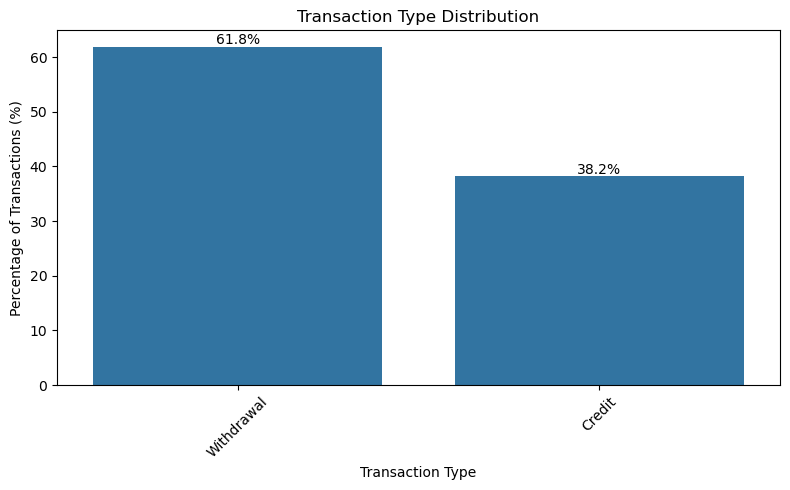

In [185]:
# Calculate percentage distribution
transaction_type_pct = (
    trans_behaviour['type']
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)

transaction_type_pct.columns = ['Transaction Type', 'Percentage']

plt.figure(figsize=(8,5))

sns.barplot(
    data=transaction_type_pct,
    x='Transaction Type',
    y='Percentage'
)

plt.title('Transaction Type Distribution')
plt.xlabel('Transaction Type')
plt.ylabel('Percentage of Transactions (%)')

# Add percentage labels
for i, v in enumerate(transaction_type_pct['Percentage']):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [186]:
# Step 1: Create fresh transaction metrics
txn_metrics = trans_behaviour.groupby('account_id').agg(
    Transaction_Count=('trans_id', 'count'),
    Avg_Transaction_Amount=('amount', 'mean'),
    Avg_Balance=('balance', 'mean')
).reset_index()

# Step 2: Merge with high_value_analysis
usage_by_value = high_value_analysis.merge(
    txn_metrics,
    on='account_id',
    how='left'
)

# Step 3: Drop old duplicate columns (keep the new ones from txn_metrics)
usage_by_value = usage_by_value.drop(columns=['Transaction_Count_x', 'Avg_Balance_x'], errors='ignore')

# Step 4: Rename the new columns properly (remove _y suffix)
usage_by_value = usage_by_value.rename(columns={
    'Transaction_Count_y': 'Transaction_Count',
    'Avg_Balance_y': 'Avg_Balance'
})

# Step 5: Group by High-Value status
usage_summary = usage_by_value.groupby('is_high_value').agg(
    Avg_Transaction_Count=('Transaction_Count', 'mean'),
    Avg_Transaction_Amount=('Avg_Transaction_Amount', 'mean'),
    Avg_Balance=('Avg_Balance', 'mean')
).reset_index()

# Rename segment for clarity
usage_summary['Segment'] = usage_summary['is_high_value'].map({0: 'Normal', 1: 'High-Value'})
usage_summary = usage_summary.drop(columns='is_high_value')

print("\n=== Usage Patterns: High-Value vs Normal ===")
usage_summary.round(2)


=== Usage Patterns: High-Value vs Normal ===


,Avg_Transaction_Count,Avg_Transaction_Amount,Avg_Balance,Segment
0,214.17,4629.45,32130.51,Normal
1,329.93,11231.35,58226.17,High-Value


In [187]:
usage_by_account = account.merge(
    trans_behaviour.groupby('account_id').agg(
        Transaction_Count = ('trans_id', 'count'),
        Avg_Transaction_Amount = ('amount', 'mean'),
        Avg_Balance = ('balance', 'mean')
    ).reset_index(),
    on='account_id',
    how='left'
).groupby('Account_type').agg({
    'Transaction_Count': 'mean',
    'Avg_Transaction_Amount': 'mean',
    'Avg_Balance': 'mean'
}).reset_index()

print("\n=== Usage Patterns by Account Type ===")
print(usage_by_account.round(2))


=== Usage Patterns by Account Type ===
      Account_type  Transaction_Count  Avg_Transaction_Amount  Avg_Balance
0      NRI account             229.22                 5960.80     37236.00
1   Salary account             237.14                 5673.68     36410.48
2  Savings account             232.44                 5728.59     36279.99


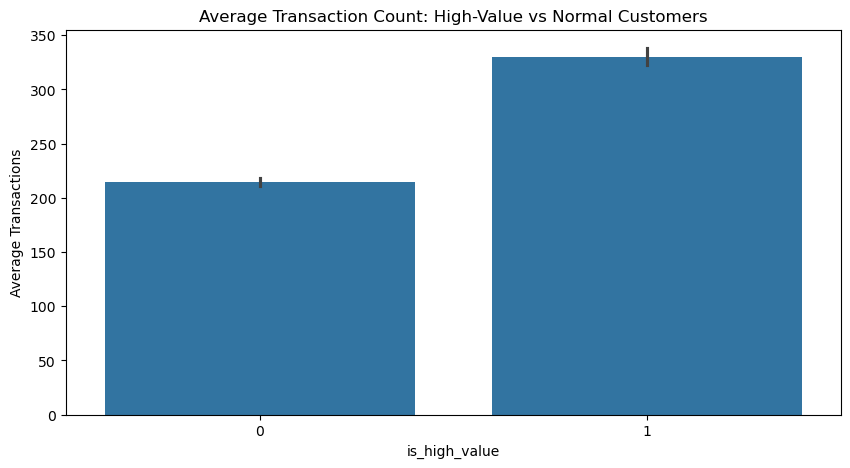

In [188]:
plt.figure(figsize=(10,5))
sns.barplot(data=usage_by_value, x='is_high_value', y='Transaction_Count')
plt.title('Average Transaction Count: High-Value vs Normal Customers')
plt.ylabel('Average Transactions')
plt.show()

### Transaction & Service Usage Patterns

### Key Findings

**Overall Behaviour**

Average customer makes 233 transactions at ₹5,943 per transaction, maintaining an average balance of ₹38,505. Withdrawals dominate at 61.8% vs. credits at 38.2%.

**High-Value vs. Normal Customers**

High-Value customers show significantly higher engagement — 330 transactions vs. 214 for normal customers, along with higher average transaction amounts and balances.

**Account Type**

Transaction behaviour is broadly consistent across NRI, Salary, and Savings accounts — minor differences in frequency and amount only.

---

### Recommendations

| Segment | Action |
|---|---|
| Normal Customers | Targeted engagement campaigns to increase transaction activity and balance levels |
| High-Value Customers | Focus on retention and upselling — premium products, loyalty rewards |
| All Customers | Introduce credit transaction incentives (cashback, rewards) to rebalance the withdrawal-heavy mix (61.8%) |
| Product Strategy | Segment by customer value, not account type — usage patterns do not vary meaningfully across account types |

> The withdrawal-to-credit imbalance (61.8% vs. 38.2%) and the engagement gap between High-Value and normal customers are the two most actionable insights

### 7.2 Identify Churn Indicators

In [189]:
# Define low activity as bottom 25% of transaction count
low_activity_threshold = trans_behaviour.groupby('account_id')['trans_id'].count().quantile(0.25)

activity_flag = trans_behaviour.groupby('account_id').agg(
    Transaction_Count = ('trans_id', 'count')
).reset_index()

activity_flag['Low_Activity_Flag'] = (activity_flag['Transaction_Count'] <= low_activity_threshold).astype(int)

print("=== Low Activity Flag Distribution ===")
print(activity_flag['Low_Activity_Flag'].value_counts(normalize=True) * 100)

=== Low Activity Flag Distribution ===
Low_Activity_Flag
0    74.866667
1    25.133333
Name: proportion, dtype: float64


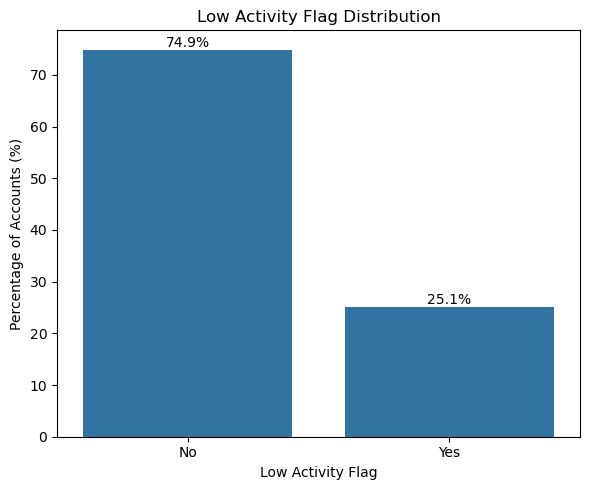

In [190]:
# Calculate percentage distribution
activity_pct = (
    activity_flag['Low_Activity_Flag']
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)

activity_pct.columns = ['Low Activity Flag', 'Percentage']

plt.figure(figsize=(6,5))

sns.barplot(
    data=activity_pct,
    x='Low Activity Flag',
    y='Percentage'
)

plt.title('Low Activity Flag Distribution')
plt.xlabel('Low Activity Flag')
plt.ylabel('Percentage of Accounts (%)')

# Add percentage labels
for i, v in enumerate(activity_pct['Percentage']):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center')

plt.xticks([0, 1], ['No', 'Yes'])   # Optional: replace 0/1 with labels
plt.tight_layout()
plt.show()

In [191]:
#Create Low Balance Flag
balance_flag = trans_behaviour.groupby('account_id').agg(
    Avg_Balance = ('balance', 'mean')
).reset_index()

# Define low balance as bottom 25%
low_balance_threshold = balance_flag['Avg_Balance'].quantile(0.25)
balance_flag['Low_Balance_Flag'] = (balance_flag['Avg_Balance'] <= low_balance_threshold).astype(int)

print("\n=== Low Balance Flag Distribution ===")
print(balance_flag['Low_Balance_Flag'].value_counts(normalize=True) * 100)


=== Low Balance Flag Distribution ===
Low_Balance_Flag
0    75.0
1    25.0
Name: proportion, dtype: float64


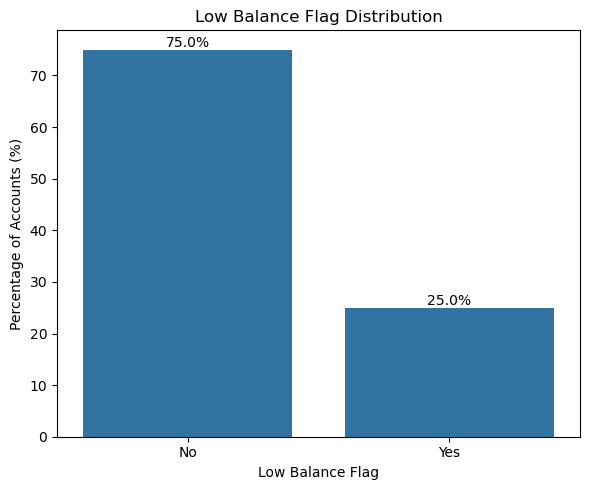

In [192]:
# Calculate percentage distribution
balance_pct = (
    balance_flag['Low_Balance_Flag']
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)

balance_pct.columns = ['Low Balance Flag', 'Percentage']

plt.figure(figsize=(6,5))

sns.barplot(
    data=balance_pct,
    x='Low Balance Flag',
    y='Percentage'
)

plt.title('Low Balance Flag Distribution')
plt.xlabel('Low Balance Flag')
plt.ylabel('Percentage of Accounts (%)')

# Add percentage labels
for i, v in enumerate(balance_pct['Percentage']):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center')

plt.xticks([0, 1], ['No', 'Yes'])   # Optional: replace 0/1 with labels
plt.tight_layout()
plt.show()

In [193]:
#Create High-Value at Risk Flag
# High-Value customers who show low activity or low balance
hv_risk = high_value_analysis.merge(
    activity_flag[['account_id', 'Low_Activity_Flag']], 
    on='account_id', 
    how='left'
).merge(
    balance_flag[['account_id', 'Low_Balance_Flag']], 
    on='account_id', 
    how='left'
)

hv_risk['HighValue_at_Risk'] = (
    (hv_risk['is_high_value'] == 1) & 
    ((hv_risk['Low_Activity_Flag'] == 1) | (hv_risk['Low_Balance_Flag'] == 1))
).astype(int)

print("\n=== High-Value at Risk Flag ===")
print(hv_risk['HighValue_at_Risk'].value_counts())


=== High-Value at Risk Flag ===
HighValue_at_Risk
0    5349
1      20
Name: count, dtype: int64


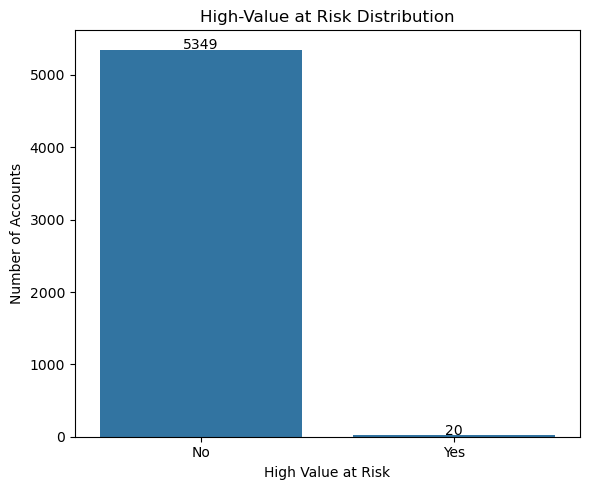

In [194]:
# Count distribution
hv_risk_count = (
    hv_risk['HighValue_at_Risk']
    .value_counts()
    .reset_index()
)

hv_risk_count.columns = ['High Value at Risk', 'Count']

plt.figure(figsize=(6,5))

sns.barplot(
    data=hv_risk_count,
    x='High Value at Risk',
    y='Count'
)

plt.title('High-Value at Risk Distribution')
plt.xlabel('High Value at Risk')
plt.ylabel('Number of Accounts')

# Add count labels
for i, v in enumerate(hv_risk_count['Count']):
    plt.text(i, v + 5, f'{int(v)}', ha='center')

plt.xticks([0, 1], ['No', 'Yes'])   # Optional if values are 0 and 1
plt.tight_layout()
plt.show()

In [195]:
# Create Single Product + Low Engagement Flag
# Step 1: Add account_id to product_adoption using disp
product_adoption_with_account = product_adoption.merge(
    disp[['client_id', 'account_id']].drop_duplicates(), 
    on='client_id', 
    how='left'
)

# Step 2: Merge with activity flag
engagement_flag = product_adoption_with_account.merge(
    activity_flag[['account_id', 'Low_Activity_Flag']], 
    on='account_id', 
    how='left'
)

# Step 3: Create Single Product + Low Engagement flag
engagement_flag['SingleProduct_LowEngagement'] = (
    (engagement_flag['total_products'] == 1) & 
    (engagement_flag['Low_Activity_Flag'] == 1)
).astype(int)

print("\n=== Single Product + Low Engagement Flag ===")
print(engagement_flag['SingleProduct_LowEngagement'].value_counts())


=== Single Product + Low Engagement Flag ===
SingleProduct_LowEngagement
0    4228
1    1089
Name: count, dtype: int64


In [196]:
#Combine All Churn Risk Flags
churn_flags = activity_flag[['account_id', 'Low_Activity_Flag']].merge(
    balance_flag[['account_id', 'Low_Balance_Flag']], 
    on='account_id', 
    how='left'
).merge(
    hv_risk[['account_id', 'HighValue_at_Risk']], 
    on='account_id', 
    how='left'
).merge(
    engagement_flag[['account_id', 'SingleProduct_LowEngagement']], 
    on='account_id', 
    how='left'
)

# Total Risk Score (sum of all flags)
churn_flags['Churn_Risk_Score'] = churn_flags[['Low_Activity_Flag', 'Low_Balance_Flag', 
                                                'HighValue_at_Risk', 'SingleProduct_LowEngagement']].sum(axis=1)

print("\n=== Churn Risk Score Distribution ===")
print(churn_flags['Churn_Risk_Score'].value_counts().sort_index())


=== Churn Risk Score Distribution ===
Churn_Risk_Score
0.0    4030
1.0    1525
2.0     843
3.0     679
Name: count, dtype: int64


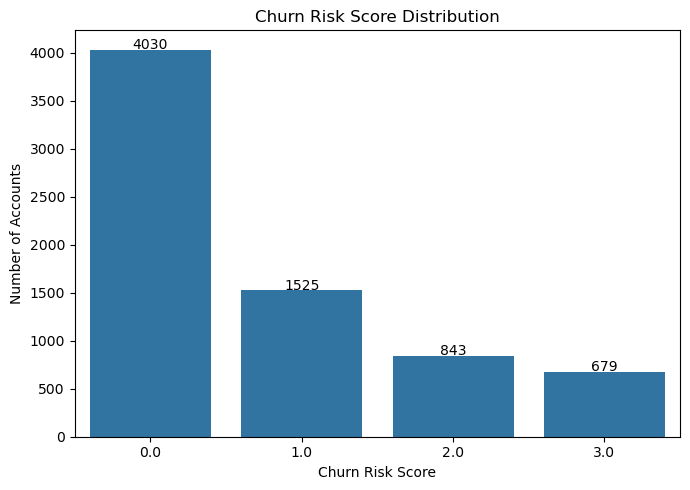

In [197]:
# Count distribution of Churn Risk Score
churn_score_count = (
    churn_flags['Churn_Risk_Score']
    .value_counts()
    .sort_index()
    .reset_index()
)

churn_score_count.columns = ['Churn Risk Score', 'Count']

plt.figure(figsize=(7,5))

sns.barplot(
    data=churn_score_count,
    x='Churn Risk Score',
    y='Count'
)

plt.title('Churn Risk Score Distribution')
plt.xlabel('Churn Risk Score')
plt.ylabel('Number of Accounts')

# Add count labels
for i, v in enumerate(churn_score_count['Count']):
    plt.text(i, v + 5, f'{int(v)}', ha='center')

plt.tight_layout()
plt.show()

### Churn Indicators

### Key Findings

**Disengagement Signals**
- 25.1% of customers show low transaction activity — a primary disengagement indicator
- 25.0% maintain low average balances — an early sign of reduced banking relationship

**High-Risk Churn Segments**
- 679 customers carry multiple churn risk flags (Score 2 or 3) — highest priority for intervention
- 1,089 customers have only 1 product + low engagement — low stickiness, high churn vulnerability
- 20 High-Value customers show disengagement signs — small but critical group to retain

---

### Recommendations

| Priority | Segment | Action |
|---|---|---|
| High | 679 multi-flag customers (Score 2–3) | Immediate re-engagement campaigns — highest churn risk |
| High | 20 at-risk High-Value customers | Proactive retention — personalised offers, relationship manager outreach |
| Medium | 1,089 single-product + low-engagement | Simple cross-sell offers (card or loan) to increase product stickiness |
| Medium | Low balance + low activity customers | Close monitoring for financial distress or relationship exit signals |
| Low | All segments | Introduce early warning alerts when activity or balance drops significantly vs. historical average |

> A customer holding only **1 product with low engagement** is the clearest churn risk profile — converting even a fraction of the 1,089 at-risk customers to 2-product holders would meaningfully improve retention rates.

### Customer Engagement Strategies

### Segment-Based Approach

| Segment | Strategy |
|---|---|
| High-Value Customers | Personalised relationship management, priority support, exclusive offers, loyalty rewards |
| Normal Active Customers | Regular communication, cross-sell relevant products, simple rewards |
| Single Product + Low Engagement | Easy cross-sell offers (Card/Loan), fee waivers, welcome incentives |
| High Churn Risk (Score ≥ 2) | Win-back campaigns, cashback, fee waivers, pre-approved loan/overdraft offers |
| High-Value at Risk | Immediate personal outreach — call or email from relationship manager |

---

### Re-engagement Campaign Offers
Target customers with Churn Risk Score ≥ 2 via multi-channel outreach (SMS + Email + App):
- Cashback on next 3 transactions
- Account maintenance fee waiver
- Pre-approved small personal loan or overdraft facility

### Cross-Sell Focus (1,089 Single-Product Customers)
- "Get your free debit/credit card in 5 minutes"
- "Pre-approved personal loan — instant approval"
- Bundled offers: Account + Card + Insurance with discounted fees

### Loyalty Program Structure
Introduce a tiered program (Silver → Gold → Platinum) based on transaction volume and balance, with increasing benefits at each tier. Recognise High-Value customers with birthday offers, annual fee waivers, and exclusive investment products.

---

### Communication Strategy

| Segment | Channel | Frequency | Tone |
|---|---|---|---|
| High-Value Customers | Personalised email + Call | Monthly | Premium & Exclusive |
| Normal Customers | App notification + SMS | Bi-monthly | Helpful & Relevant |
| At-Risk / Low Engagement | SMS + Simple offers | Frequent | Urgent but Friendly |

---

### Priority Action Summary

| Priority | Action | Target | Expected Impact |
|---|---|---|---|
| High | Proactive outreach to High-Value at Risk | 20 customers | Prevent high-value churn |
| High | Cross-sell campaigns for single-product customers | 1,089 customers | Increase product stickiness |
| Medium | Launch tiered loyalty program | All customers | Improve retention & engagement |
| Medium | Re-engagement offers for Risk Score ≥ 2 | ~1,500+ customers | Reduce overall churn |
| Low | Regular value-added communication | Normal customers | Maintain relationship |

### Conclusion – Customer Experience Enhancement

The analysis covered transaction behaviour, churn risk indicators, and engagement strategies across customer segments for the period under review.

---

### Summary of Key Findings

| Area | Finding |
|---|---|
| Transaction Behaviour | Withdrawals dominate (61.8%); High-Value customers show significantly higher engagement than normal customers |
| Churn Risk | ~25% of customers show low activity or low balance; 1,089 single-product + low-engagement customers are most vulnerable |
| High-Value Segment | Only 20 high-value customers show disengagement signs — small but requires immediate proactive attention |
| Engagement Opportunity | Significant cross-sell and re-engagement potential among normal and low-engagement customer segments |

---

### Strategic Implications

**Segmented Engagement**
Differentiated strategies across High-Value, Normal, and At-Risk segments — one-size-fits-all approaches will underperform given the clear behavioural differences between groups.

**Cross-Sell & Re-engagement**
Targeting the 1,089 single-product + low-engagement customers with simple, relevant offers is the highest-volume retention opportunity available.

**Digital & Product Enhancement**
Strengthening digital channels, introducing product bundles, and enabling proactive personalised outreach will address the most critical gaps in current customer experience.

---

### Overall Takeaway

Improving customer experience through **timely intervention for at-risk customers**, **relevant cross-sell offers**, and **differentiated engagement strategies** is the primary lever for reducing churn and driving long-term profitability.

## RFM

In [198]:
# Convert date to datetime
trans_with_client['date'] = pd.to_datetime(trans_with_client['date'])

# RFM Analysis
rfm = customer_metrics.copy()

# Recency
last_date = trans_with_client['date'].max()
last_txn = trans_with_client.groupby('client_id')['date'].max().reset_index()
last_txn['Recency'] = (last_date - last_txn['date']).dt.days

rfm = rfm.merge(last_txn[['client_id', 'Recency']], on='client_id', how='left')

# Frequency & Monetary
rfm = rfm.rename(columns={
    'Transaction_Count': 'Frequency',
    'Total_Transaction_Amount': 'Monetary'
})

# RFM Scores
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'], 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print("Top RFM Segments:")
rfm['RFM_Score'].value_counts().head(10)

NameError: name 'trans_with_client' is not defined

In [ ]:
# RFM Segment Distribution
plt.figure(figsize=(12, 6))
rfm['RFM_Score'].value_counts().head(15).plot(kind='bar', color='skyblue')
plt.title('Top RFM Segments Distribution', fontsize=14)
plt.xlabel('RFM Score')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()


### RFM Segment Distribution Interpretation

#### Key Insights from the Chart

- **555 (Highest)**: 185 customers → **Best Customers** (High Recency, Frequency, Monetary)
- **111 (Lowest)**: 174 customers → **Lost / Low Value Customers**
- **355, 311, 511**: Strong segments with good potential

#### Business Interpretation

| RFM Score | Segment Name       | Count | Interpretation              | Recommended Action          |
|-----------|--------------------|-------|-----------------------------|-----------------------------|
| **555**   | Champions          | 185   | Best customers              | Reward & Retain             |
| **111**   | Lost Customers     | 174   | Lowest engagement           | Re-activation campaign      |
| **355, 511** | Loyal / High Value | ~250 | Good potential              | Upsell & Cross-sell         |
| **211, 545** | Promising          | ~200 | New or recovering customers | Nurture with offers         |

#### Overall Insights

- Top 3 segments (555, 111, 355) represent a large portion of customers.
- Clear **bimodal distribution** — strong group of high-value customers and a large group of low-engagement customers.
- **Key Opportunity**: Move customers from lower RFM scores (like 111, 211) to higher ones through targeted campaigns.

#### Strategic Recommendations

1. **Retain Champions (555)**: Loyalty program, VIP treatment, personalized offers
2. **Reactivate Lost Customers (111)**: Win-back campaigns, special discounts, personalized emails
3. **Nurture Promising Customers**: Product recommendations, early engagement offers

In [ ]:
print("Top 10 AccountIDs with High RFM")
rfm[['account_id','RFM_Score']].sort_values(by='RFM_Score',ascending=False).head(10)

## 8. Strategic Growth Opportunities

### 8.1 Identify Untapped Customer Segments

In [ ]:
# Customers with only 1 product but decent balance or activity
single_product_potential = product_adoption_with_account.merge(
    trans_behaviour.groupby('account_id').agg(
        Avg_Balance = ('balance', 'mean'),
        Transaction_Count = ('trans_id', 'count')
    ).reset_index(),
    on='account_id',
    how='left'
)

single_product_potential = single_product_potential[
    (single_product_potential['total_products'] == 1) &
    (single_product_potential['Avg_Balance'] > single_product_potential['Avg_Balance'].median())
]

print("=== Single Product Customers with Good Potential ===")
print(f"Number of such customers: {len(single_product_potential)}")
print(f"Average Balance of this segment: {single_product_potential['Avg_Balance'].mean():.2f}")

In [ ]:
#Low Activity but Decent Balance
low_activity_good_balance = trans_behaviour.groupby('account_id').agg(
    Avg_Balance = ('balance', 'mean'),
    Transaction_Count = ('trans_id', 'count')
).reset_index()

# Low activity (bottom 30%) but above-median balance
low_activity_threshold = low_activity_good_balance['Transaction_Count'].quantile(0.3)
balance_threshold = low_activity_good_balance['Avg_Balance'].median()

re_engage_segment = low_activity_good_balance[
    (low_activity_good_balance['Transaction_Count'] <= low_activity_threshold) &
    (low_activity_good_balance['Avg_Balance'] >= balance_threshold)
]

print("\n=== Low Activity but Decent Balance Segment ===")
print(f"Number of customers in this segment: {len(re_engage_segment)}")
print(f"Average Balance: {re_engage_segment['Avg_Balance'].mean():.2f}")

In [ ]:
# Normal customers with high balance or high transaction count (potential to become High-Value)
future_hv = high_value_analysis[
    (high_value_analysis['is_high_value'] == 0) &
    ((high_value_analysis['Avg_Balance'] > high_value_analysis['Avg_Balance'].quantile(0.75)) |
     (high_value_analysis['Total_Transaction_Amount'] > high_value_analysis['Total_Transaction_Amount'].quantile(0.75)))
]

print("\n=== Normal Customers with High Potential to become High-Value ===")
print(f"Number of such customers: {len(future_hv)}")

In [ ]:
# Districts with decent average salary but low banking activity
district_potential = district_economic[
    (district_economic['avg_salary'] > district_economic['avg_salary'].median()) &
    (district_economic['Total_Transaction_Amount'] < district_economic['Total_Transaction_Amount'].quantile(0.4))
]

print("\n=== Districts with Good Income but Low Banking Activity ===")
district_potential[['district_name', 'region', 'avg_salary', 'Total_Transaction_Amount']].head(5)

### Untapped Customer Segments

### Key Findings

**Single-Product Customers with Good Balances**
1,463 customers hold only 1 product but maintain a healthy average balance of ₹47,322 — a strong, ready cross-sell opportunity.

**Low-Activity but Decent-Balance Customers**
525 customers show low engagement despite maintaining average balances of ₹47,948 — good candidates for targeted re-engagement.

**High-Potential Normal Customers**
941 normal customers already display strong transaction or balance behaviour, making them viable candidates for conversion to High-Value status.

**Untapped Geographic Markets**
Several districts — particularly in Central, West, and North Bohemia — show decent average salaries but low banking penetration, indicating significant regional growth potential.

---

### Recommendations

| Segment | Size | Action |
|---|---|---|
| Single-product + good balance | 1,463 customers | Cross-sell campaigns — easy card or loan offers |
| Low-activity + decent balance | 525 customers | Re-engagement offers — cashback, fee waivers |
| High-potential normal customers | 941 customers | Personalised nurturing to convert to High-Value segment |
| Underserved districts | Central, West & North Bohemia | Regional growth campaigns in Beroun, České Budějovice, Písek, Karlovy Vary, Chomutov |

> The 1,463 single-product customers with strong balances are the most immediately actionable segment — they already demonstrate financial capacity, and only need a relevant product offer to convert.

### Product & Service Recommendations

### Product Recommendations

| Product / Bundle | Target Segment | Expected Impact |
|---|---|---|
| Easy Account + Card Bundle | 1,463 single-product + good balance customers | Increase product holding & engagement |
| Pre-approved Personal Loan / Overdraft | 525 low-activity + decent balance customers | Revenue growth + re-engagement |
| Premium Banking Package | High-Value & 941 high-potential customers | Higher profitability & loyalty |
| Youth / Education-Focused Bundle | Younger customers, lower-engagement districts | Build future high-value segment |
| Regional Micro-Loan / Business Loan | Beroun, Písek, Chomutov (good income, low activity) | Regional growth & penetration |

---

### Service Enhancements

**Proactive Engagement**
- Use behavioural triggers for product recommendations (e.g., high balance + no loan → show pre-approved loan offer)
- Assign dedicated relationship managers to mid-to-high value customers above a defined balance or transaction threshold

**Loyalty Program**
Introduce Silver → Gold → Platinum tiers with progressive benefits — fee waivers, higher transaction limits, and partner discounts

**Win-Back Offers**
Deploy special packages (fee waiver + cashback + priority support) for customers with multiple churn risk flags

---

### Digital & Self-Service Improvements

**Mobile App Enhancements**
- One-click loan application
- Instant card controls (block/unblock, limit changes)
- Personalised product recommendations based on usage behaviour

**Self-Service & Accessibility**
- AI-powered chatbot for 24/7 query resolution
- Self-service options for common requests to reduce branch dependency

> Instant product onboarding — allowing existing customers to apply for cards or loans via mobile with minimal documentation — is the single highest-impact digital improvement, directly enabling the cross-sell strategy across all target segments.

### Acquisition & Retention Strategies

### Customer Acquisition

| Strategy | Target Group | Approach | Expected Impact |
|---|---|---|---|
| Geographic Expansion | Beroun, Písek, Chomutov, Karlovy Vary | New branches/ATMs or localised digital campaigns | Increased presence in untapped markets |
| Salary Account Acquisition | Companies in high-potential districts | Corporate tie-ups with pre-approved loans and cards | Steady inflow of new customers |
| Youth & New-to-Bank | Younger population, first-time bankers | Simplified digital onboarding + education-focused products | Long-term customer base building |
| Referral Program | Existing satisfied customers | Reward customers for successful referrals | Low-cost, high-trust acquisition |

---

### Customer Retention

| Strategy | Target Segment | Approach | Expected Impact |
|---|---|---|---|
| Proactive Re-engagement | Churn Risk Score ≥ 2 | Personalised cashback, fee waivers, pre-approved offers | Reduce churn |
| High-Value Retention Program | High-Value & high-potential customers | Dedicated relationship manager, exclusive benefits, priority service | Protect and grow high-value segment |
| Loyalty & Rewards Program | All active customers | Tiered rewards based on activity and balance | Increase engagement and stickiness |
| Cross-Sell for Stickiness | Single product + good balance customers | Bundled offers — Account + Card + Insurance | Improve retention through multi-product holding |
| Personalised Communication | All segments | Relevant offers via preferred channel (App, SMS, Email) | Higher response and satisfaction rates |

---

### Priority Retention Focus

| Priority | Segment | Size | Action |
|---|---|---|---|
| High | Single Product + Low Engagement | 1,089 customers | Cross-sell to increase product holding and reduce churn risk |
| High | High-Value at Risk | 20 customers | Immediate personal outreach — prevent loss of valuable customers |
| Medium | Low Activity + Decent Balance | 525 customers | Re-engagement via simple incentives and relevant offers |
| Medium | Multiple churn risk flags | 679+ customers | Targeted win-back campaigns with time-bound offers |

> Protecting the **20 high-value at-risk customers** and converting the **1,089 single-product low-engagement customers** are the two highest-ROI retention actions available — and should be launched simultaneously.

### Profitability Improvement

### Revenue Enhancement

| Strategy | Description | Expected Impact |
|---|---|---|
| Increase Product Penetration | Cross-sell to single-product customer base | Higher fee and interest income |
| Grow High-Value Segment | Nurture and retain high-value & future high-value customers | Higher average revenue per customer |
| Optimise Lending Mix | Focus on lower-risk segments (High-Value, Savings accounts) | Better risk-adjusted returns |
| Promote Digital Transactions | Incentivise credit transactions and digital usage | Lower cost per transaction + higher fee income |
| Regional Focus | Prioritise high-potential, low-risk districts (Central Bohemia) | Efficient capital allocation |

---

### Cost Optimisation

| Strategy | Description | Expected Impact |
|---|---|---|
| Digital Channel Shift | Move customers to self-service digital channels | Lower operational cost |
| Targeted Marketing | Focus spend on high-potential segments over mass campaigns | Better marketing ROI |
| Risk-Based Credit Pricing | Charge rates aligned to customer risk profile | Improved lending margins |
| Early Churn Prevention | Proactively engage at-risk customers before exit | Reduce replacement acquisition cost |

---

### Risk Management

- Monitor large loans and Salary account lending closely — both carry elevated default risk
- Include customer balance history as a key input in credit scoring models
- Prioritise growth in low-risk districts (Kolín, Louny, Nymburk) to maintain portfolio quality
- Implement early warning systems for customers showing declining activity or balance trends

---

### Priority Action Summary

| Priority | Action | Impact Area | Expected Benefit |
|---|---|---|---|
| High | Cross-sell to single-product customers | Revenue | Higher fee & interest income |
| High | Retain & grow High-Value segment | Revenue + Risk | Improved profitability per customer |
| High | Focus growth in low-risk, high-potential districts | Risk + Efficiency | Sustainable growth |
| Medium | Shift customers to digital channels | Cost | Lower operational cost |
| Medium | Risk-based pricing & credit assessment | Risk + Revenue | Better margins & lower defaults |
| Medium | Early churn prevention | Retention Cost | Lower customer acquisition cost |

---

### Overall Strategic Recommendation

> **Three Pillars for Profitability**
>
> **Grow Smartly** — Target high-potential, low-risk segments and districts
>
> **Sell More to Existing Customers** — Especially the large base of single-product customers
>
> **Protect What You Have** — Retain high-value customers and prevent churn through proactive engagement

This balanced approach improves revenue while keeping risk and operational cost under control.

## Final Project Summary & Conclusion



### Project Overview
A comprehensive banking analytics project for Czechoslovakia Bank, transforming raw transactional and customer data into actionable insights across 8 business objectives — using SQL for data preparation and Python for analysis and visualisation.

---

### Key Findings by Objective

| Objective | Key Highlights |
|---|---|
| Customer Analytics | High-Value customers (≈16.5%) show higher engagement and lower risk; 73.6% hold only 1 product |
| Financial Performance | Strong growth 1993–1997; slowdown in 1998; loan growth volatile; risk rate improved in 1998 |
| Product Performance | Salary accounts carry highest loan risk; Gold card holders show better engagement; low multi-product adoption |
| Loan Portfolio | 11.14% problematic rate; large loans and Salary accounts highest risk; High-Value customers at 0% risk |
| Regional Analysis | Prague dominates; Central Bohemia offers high performance + low risk; population and salary are key growth drivers |
| Customer Experience | 25% low-activity customers; 1,089 single-product + low-engagement customers at churn risk |
| Strategic Opportunities | Untapped potential in single-product customers, low-activity decent-balance customers, and underserved districts |

---

### Strategic Recommendations

| Priority Area | Key Recommendations |
|---|---|
| Growth | Cross-sell to single-product customers; expand in Central Bohemia |
| Risk Management | Tighten credit for large loans and Salary accounts; use balance as a risk indicator |
| Customer Experience | Re-engagement campaigns for at-risk customers; introduce tiered loyalty program |
| Profitability | Retain High-Value customers; improve product penetration among normal customers |
| Regional Strategy | Differentiated approach for Prague vs. other regions; prioritise high-potential, low-risk districts |

---

### Key Business Insights

- **High-Value customers** are the bank's most valuable segment — protect and nurture them
- **Low product penetration** is the biggest opportunity — moving customers from 1 to 2+ products improves both retention and revenue
- **Risk is concentrated** in large loans, Salary accounts, and low-balance customers — targeted controls can materially improve portfolio quality
- **Regional imbalance** exists — Central Bohemia offers strong growth potential with lower risk than Prague
- **25% of customers show low activity** — better communication and relevant offers are needed to improve engagement

---

### Conclusion

The bank has a solid foundation with a healthy customer base and improving risk trends. The clearest opportunities lie in **improving product penetration**, **deepening customer engagement**, and **balancing regional growth**.

> By focusing on smart growth in high-potential segments and districts, protecting high-value relationships, and improving customer experience through proactive and relevant engagement, the bank can achieve sustainable growth while maintaining healthy risk levels and improving overall profitability.